# Exploratory Data Analysis

## Object

This notebook performs exploratory data analysis on the cleaned Olist e-commerce datasets.

The objective is to identify patterns, trends, relationships, and business insights related to sales, customers, products, sellers, payments, reviews, delivery performance, and geographic distribution.

The analysis builds upon the data cleaning process performed in the previous notebook and focuses on understanding the business performance of the Olist marketplace.

# 1. Import Libraries

The following libraries are used for exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Cleaned Data

The cleaned datasets generated during the data cleaning process are loaded into this notebook for exploratory analysis.

In [ ]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
orders = pd.read_csv("../data/processed/orders_clean.csv")
items = pd.read_csv("../data/processed/items_clean.csv")
payments = pd.read_csv("../data/processed/payments_clean.csv")
reviews = pd.read_csv("../data/processed/reviews_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
sellers = pd.read_csv("../data/processed/sellers_clean.csv")
category = pd.read_csv("../data/processed/category_clean.csv")
geolocation = pd.read_csv("../data/processed/geolocation_clean.csv")

### 2.1 Date Conversion

Date columns are converted to datetime format to enable time-based analysis.

In [3]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [4]:
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_columns:
    reviews[col] = pd.to_datetime(reviews[col])

### 2.2 Dataset Overview

The dimensions of each cleaned dataset are checked before starting the exploratory analysis.

In [5]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Items": items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Category": category,
    "Geolocation": geolocation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Customers: (99441, 5)
Orders: (99441, 8)
Items: (112650, 7)
Payments: (103883, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Category: (71, 2)
Geolocation: (738324, 5)


## 3. Sales Performance

This section analyzes the overall sales performance of the Olist marketplace, including order volume, items sold, revenue, average order value, and sales trends over time.

### 3.1 Total Orders

The total number of orders is calculated to provide an overview of the marketplace transaction volume.

In [6]:
total_orders = orders["order_id"].nunique()

print(f"Total orders: {total_orders:,}")

Total orders: 99,441


### 3.2 Total Items Sold

The total number of items sold is calculated based on the order items dataset.

In [7]:
total_items = items["order_item_id"].count()

print(f"Total items sold: {total_items:,}")

Total items sold: 112,650


### 3.3 Total Revenue

Total revenue is calculated by summing the product prices recorded in the order items dataset.

In [8]:
total_revenue = items["price"].sum()

print(f"Total revenue: R$ {total_revenue:,.2f}")

Total revenue: R$ 13,591,643.70


### 3.4 Average Order Value

Average Order Value (AOV) represents the average product revenue generated per order.

In [9]:
aov = total_revenue / total_orders

print(f"Average Order Value: R$ {aov:,.2f}")

Average Order Value: R$ 136.68


### 3.5 Monthly Revenue

Monthly revenue is analyzed to identify sales trends and changes in marketplace performance over time.

In [10]:
monthly_revenue = (
    items.merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left"
    )
)

monthly_revenue["month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue = (
    monthly_revenue
    .groupby("month")["price"]
    .sum()
    .reset_index()
)

monthly_revenue["month"] = monthly_revenue["month"].astype(str)

monthly_revenue.head()

,month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


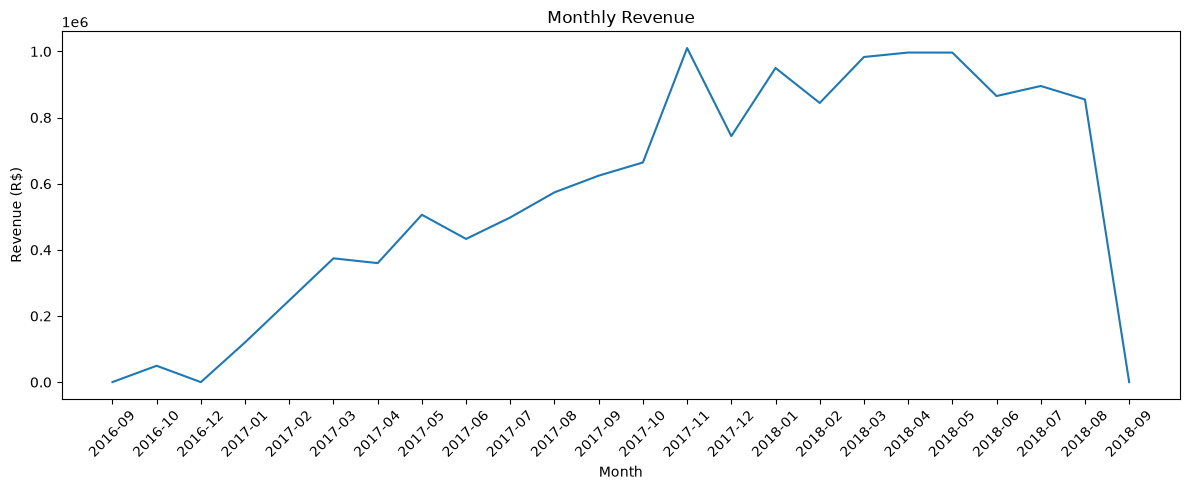

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["price"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.5.1 December Data investigation

In [12]:
monthly_orders = (
    orders
    .assign(
        month=orders["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("month")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

monthly_orders.head(10)

,month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [13]:
monthly_items = (
    items
    .merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left"
    )
    .assign(
        month=lambda x: x["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("month")["order_id"]
    .count()
    .reset_index(name="item_count")
)

monthly_items.head(10)

,month,item_count
0,2016-09,6
1,2016-10,363
2,2016-12,1
3,2017-01,955
4,2017-02,1951
5,2017-03,3000
6,2017-04,2684
7,2017-05,4136
8,2017-06,3583
9,2017-07,4519


In [14]:
december_2016 = orders[
    orders["order_purchase_timestamp"].dt.to_period("M") == "2016-12"
]

december_2016[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp"
    ]
]

,order_id,order_status,order_purchase_timestamp
39761,bd50a7fe9fd97ea4b7663031a319e150,delivered,2016-12-23 23:16:47


In [15]:
december_items = items[
    items["order_id"].isin(december_2016["order_id"])
]

december_items[
    ["order_id", "product_id", "price", "freight_value"]
]

,order_id,product_id,price,freight_value
83342,bd50a7fe9fd97ea4b7663031a319e150,f5d8f4fbc70ca2a0038b9a0010ed5cb0,10.9,8.72


> **Observation:** December 2016 shows unusually low revenue (R$ 10.90). Further investigation found that the month contains only one order. Therefore, the low revenue is explained by the very low transaction volume rather than a calculation or data quality issue. Early months should be interpreted with caution due to limited observations.

In [16]:
monthly_order_volume = (
    orders
    .assign(
        month=orders["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("month")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

monthly_order_volume["month"] = monthly_order_volume["month"].astype(str)

monthly_order_volume.head()

,month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


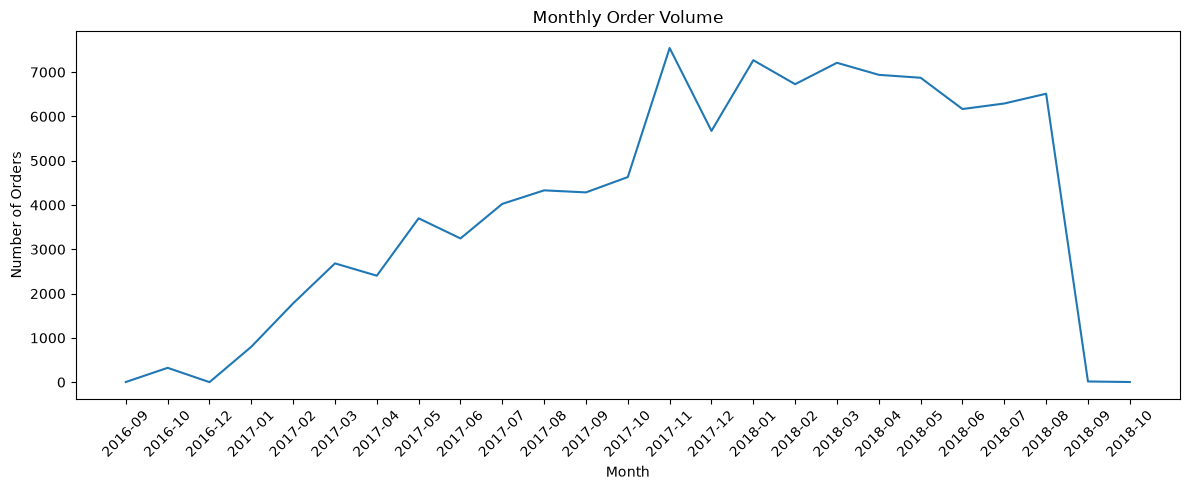

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_order_volume["month"],
    monthly_order_volume["order_count"]
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.7 Monthly Average Order Value

Monthly Average Order Value (AOV) is analyzed to determine whether changes in revenue are primarily driven by order volume or by changes in the average value of each order.

In [18]:
monthly_aov = (
    items
    .merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left"
    )
    .assign(
        month=lambda x: x["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("month")
    .agg(
        revenue=("price", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

monthly_aov["aov"] = (
    monthly_aov["revenue"] /
    monthly_aov["order_count"]
)

monthly_aov["month"] = monthly_aov["month"].astype(str)

monthly_aov.head()

,month,revenue,order_count,aov
0,2016-09,267.36,3,89.120000
1,2016-10,49507.66,308,160.739156
2,2016-12,10.90,1,10.900000
3,2017-01,120312.87,789,152.487795
4,2017-02,247303.02,1733,142.702262


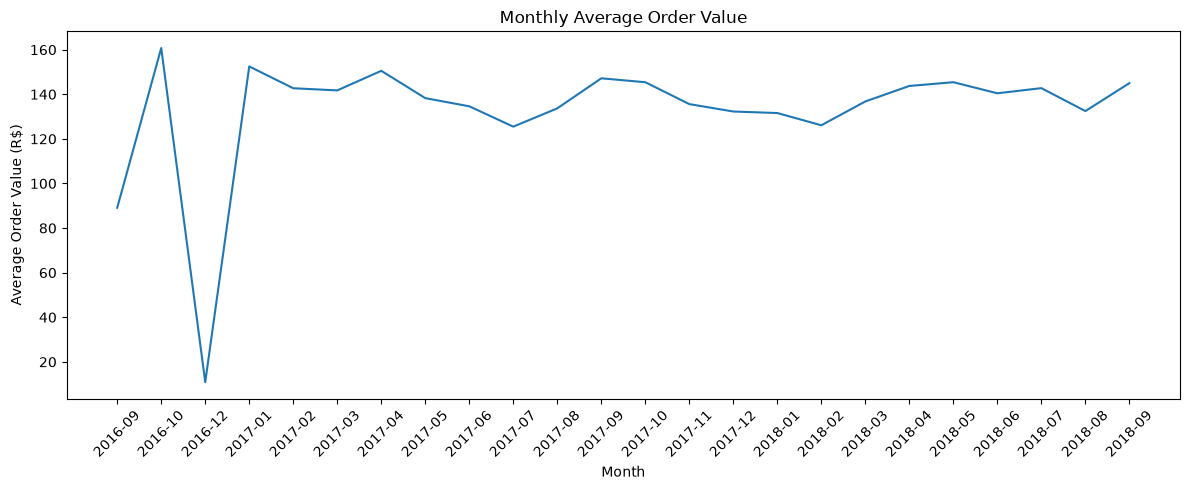

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_aov["month"],
    monthly_aov["aov"]
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.8 AOV Stability

The monthly Average Order Value (AOV) is examined to determine whether revenue growth is associated with changes in the average value of individual orders.

In [20]:
monthly_aov_2017 = monthly_aov[
    monthly_aov["month"] >= "2017-01"
].copy()

print(
    f"Average AOV from 2017 onward: "
    f"R$ {monthly_aov_2017['aov'].mean():,.2f}"
)

print(
    f"Minimum monthly AOV: "
    f"R$ {monthly_aov_2017['aov'].min():,.2f}"
)

print(
    f"Maximum monthly AOV: "
    f"R$ {monthly_aov_2017['aov'].max():,.2f}"
)

Average AOV from 2017 onward: R$ 139.25
Minimum monthly AOV: R$ 125.48
Maximum monthly AOV: R$ 152.49


> **Insight:** From 2017 onward, the monthly AOV averaged R$ 139.25 and remained within a relatively narrow range of R$ 125.48 to R$ 152.49. Despite substantial growth in order volume, the average value per order did not increase significantly. This suggests that revenue growth was primarily driven by an increase in the number of orders rather than higher spending per order.

## 4. Order Status & Delivery Performance

This section analyzes order outcomes and delivery performance to understand the operational performance of the Olist marketplace.

The analysis focuses on order status, delivery times, and differences between estimated and actual delivery dates.

### 4.1 Order Status Distribution

The distribution of order statuses is analyzed to understand the proportion of orders that were delivered, canceled, unavailable, or remained in other stages of the order process.

In [21]:
order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = ["order_status", "order_count"]

order_status

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [22]:
order_status["percentage"] = (
    order_status["order_count"] /
    order_status["order_count"].sum() * 100
)

order_status

,order_status,order_count,percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


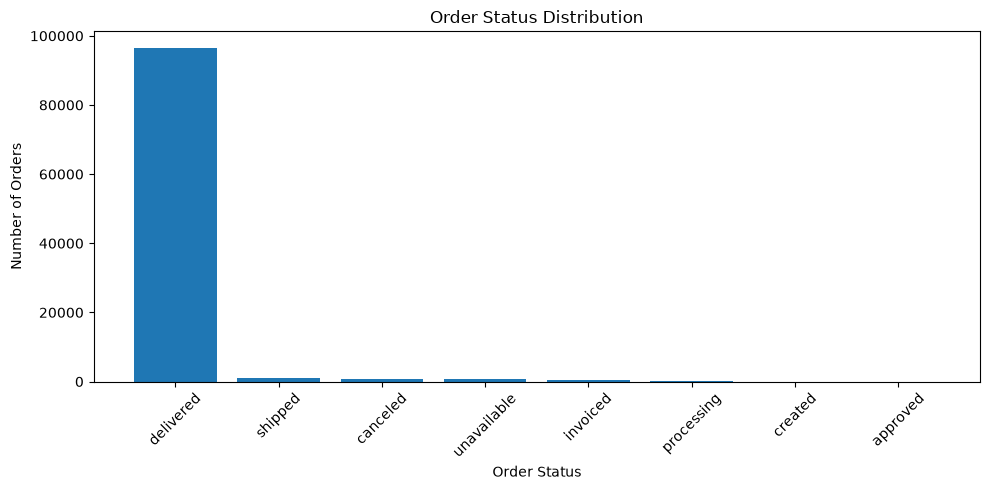

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    order_status["order_status"],
    order_status["order_count"]
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Delivery Rate

The delivery rate is calculated as the percentage of orders that were successfully delivered.

In [24]:
total_orders = orders["order_id"].nunique()

delivered_orders = (
    orders["order_status"] == "delivered"
).sum()

delivery_rate = (
    delivered_orders / total_orders * 100
)

print(f"Total orders: {total_orders:,}")
print(f"Delivered orders: {delivered_orders:,}")
print(f"Delivery rate: {delivery_rate:.2f}%")

Total orders: 99,441
Delivered orders: 96,478
Delivery rate: 97.02%


### 4.3 Delivery Time Analysis

This section analyzes the time required to deliver orders to customers.

The analysis focuses on the distribution of delivery times and key statistics such as the mean and median delivery time to understand the overall delivery performance.

In [25]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

In [26]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

In [27]:
mean_delivery = orders["delivery_days"].mean()
median_delivery = orders["delivery_days"].median()

print(f"Mean delivery time: {mean_delivery:.2f} days")
print(f"Median delivery time: {median_delivery:.2f} days")

Mean delivery time: 12.56 days
Median delivery time: 10.22 days


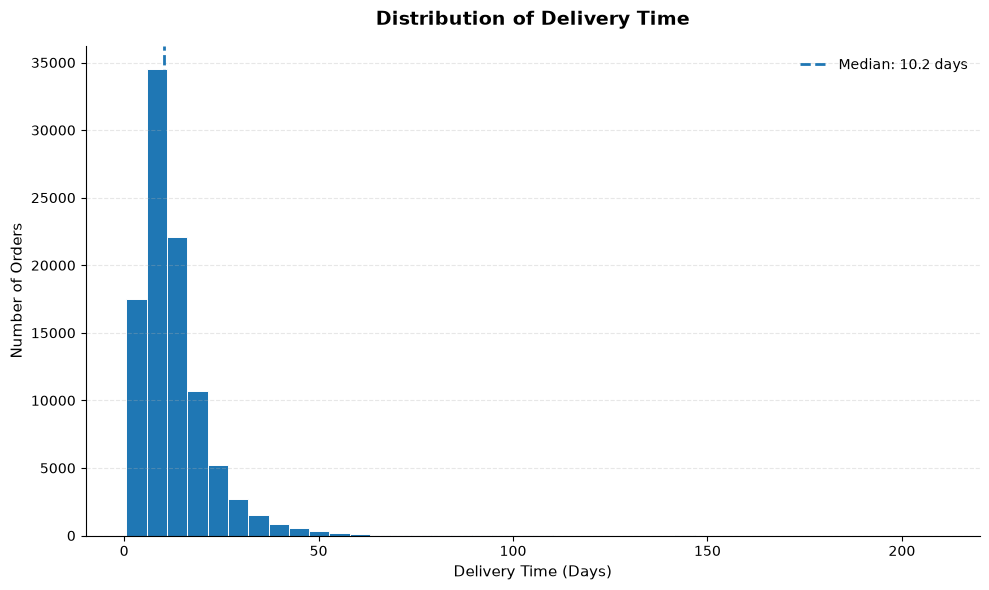

In [28]:
import matplotlib.pyplot as plt

median_delivery = orders["delivery_days"].median()

plt.figure(figsize=(10, 6))

plt.hist(
    orders["delivery_days"].dropna(),
    bins=40,
    edgecolor="white",
    linewidth=0.7
)

plt.axvline(
    median_delivery,
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_delivery:.1f} days"
)

plt.xlabel("Delivery Time (Days)", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)

plt.title(
    "Distribution of Delivery Time",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(frameon=False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 4.4 Estimated vs. Actual Delivery Performance

This section compares the estimated delivery date with the actual delivery date to evaluate whether orders were delivered earlier, on time, or later than expected.

The analysis helps identify potential delivery delays and assess the marketplace's ability to meet customer delivery expectations.

In [29]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (60 * 60 * 24)

In [30]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

#### 4.4.2 Delivery Performance Classification

Orders are classified based on the difference between the actual and estimated delivery dates.

Orders delivered on or before the estimated delivery date are classified as "On Time", while orders delivered after the estimated date are classified as "Late".

In [31]:
orders["delivery_performance"] = orders[
    "delivery_delay_days"
].apply(
    lambda x:
        "On Time" if x <= 0
        else "Late"
        if pd.notna(x)
        else None
)

In [32]:
orders["delivery_performance"].value_counts()

delivery_performance
On Time    88649
Late        7827
Name: count, dtype: int64

In [33]:
delivery_performance_pct = (
    orders["delivery_performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delivery_performance_pct

delivery_performance
On Time    91.89
Late        8.11
Name: proportion, dtype: float64

#### 4.4.3 On-Time vs. Late Delivery

This analysis compares the proportion of orders delivered on time with those delivered after the estimated delivery date.

The results provide a high-level view of the marketplace's ability to meet its estimated delivery commitments.

In [34]:
performance_counts = (
    orders["delivery_performance"]
    .value_counts()
)

performance_counts

delivery_performance
On Time    88649
Late        7827
Name: count, dtype: int64

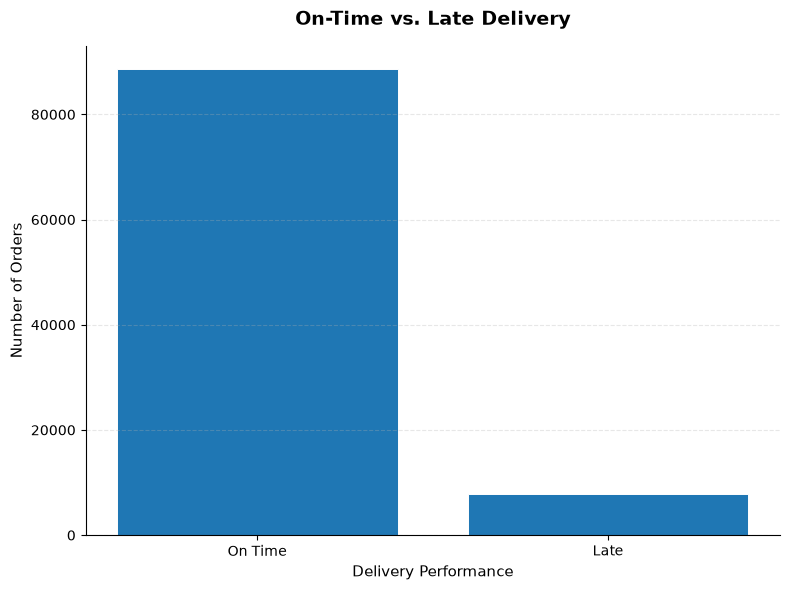

In [35]:
plt.figure(figsize=(8, 6))

plt.bar(
    performance_counts.index,
    performance_counts.values,
    edgecolor="white",
    linewidth=0.7
)

plt.xlabel("Delivery Performance", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)

plt.title(
    "On-Time vs. Late Delivery",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 4.5 Investigating Extreme Delivery Delays

The delivery delay distribution contains extreme values, including orders delivered substantially later than the estimated delivery date.

This section investigates these extreme delays to determine their frequency and potential impact on the overall delivery performance analysis.

In [36]:
delay_99th = orders["delivery_delay_days"].quantile(0.99)

print(f"99th percentile: {delay_99th:.2f} days")

99th percentile: 18.94 days


In [37]:
extreme_delays = orders[
    orders["delivery_delay_days"] > delay_99th
]

print(f"Number of extreme delays: {len(extreme_delays):,}")

print(
    f"Percentage of orders: "
    f"{len(extreme_delays) / orders['delivery_delay_days'].notna().sum() * 100:.2f}%"
)

Number of extreme delays: 965
Percentage of orders: 1.00%


#### 4.5.1 Extreme Delay Cases

The orders with the largest delivery delays are examined to identify potential data quality issues or unusual operational cases.

This step helps determine whether extreme values represent valid observations or potential anomalies in the dataset.

In [38]:
extreme_delays[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_delay_days"
    ]
].sort_values(
    "delivery_delay_days",
    ascending=False
).head(20)

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,2018-03-15,188.975081
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,181.608785
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19,175.869109
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,167.708414
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,2017-04-06,166.583380
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,165.633912
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,162.718345
40847,d24e8541128cea179a11a65176e0a96f,delivered,2017-06-12 13:14:11,2017-12-04 18:36:29,2017-06-26,161.775336
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,159.609931


#### 4.5.2 Repeated Delivery Dates

The extreme delay cases show that several orders share the same delivery dates.

This analysis examines the frequency of delivery dates to determine whether a small number of dates are disproportionately represented in the dataset.

In [39]:
extreme_date_counts = (
    extreme_delays["order_delivered_customer_date"]
    .dt.date
    .value_counts()
    .head(10)
)

extreme_date_counts

order_delivered_customer_date
2017-09-19    32
2018-04-17    25
2018-04-16    24
2018-04-19    20
2018-04-18    18
2018-01-08    18
2018-04-24    16
2018-05-03    15
2018-04-11    15
2018-04-09    14
Name: count, dtype: int64

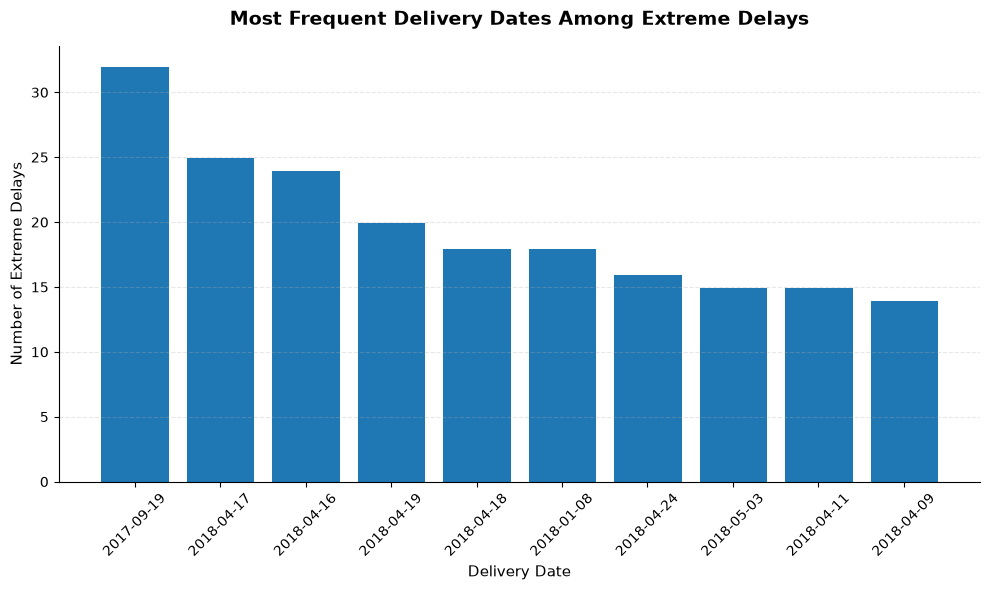

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    extreme_date_counts.index.astype(str),
    extreme_date_counts.values,
    edgecolor="white",
    linewidth=0.7
)

plt.xlabel("Delivery Date", fontsize=11)
plt.ylabel("Number of Extreme Delays", fontsize=11)

plt.title(
    "Most Frequent Delivery Dates Among Extreme Delays",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=45)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [41]:
orders["order_delivered_customer_date"].dt.date.value_counts().head(20)

order_delivered_customer_date
2018-08-27    446
2018-08-13    442
2018-05-14    434
2018-05-21    431
2018-05-18    425
2018-04-11    413
2017-12-11    412
2018-07-03    410
2018-05-03    409
2018-07-30    405
2017-06-19    405
2017-12-19    401
2018-08-23    396
2018-08-28    395
2018-08-20    393
2018-04-30    386
2018-08-17    384
2017-12-18    383
2018-03-29    381
2018-08-21    380
Name: count, dtype: int64

#### 4.5.3 Delivery Delay Distribution

This analysis visualizes the distribution of delivery delays to understand how actual delivery dates compare with estimated delivery dates.

The distribution also helps identify the presence and impact of extreme delays on overall delivery performance.

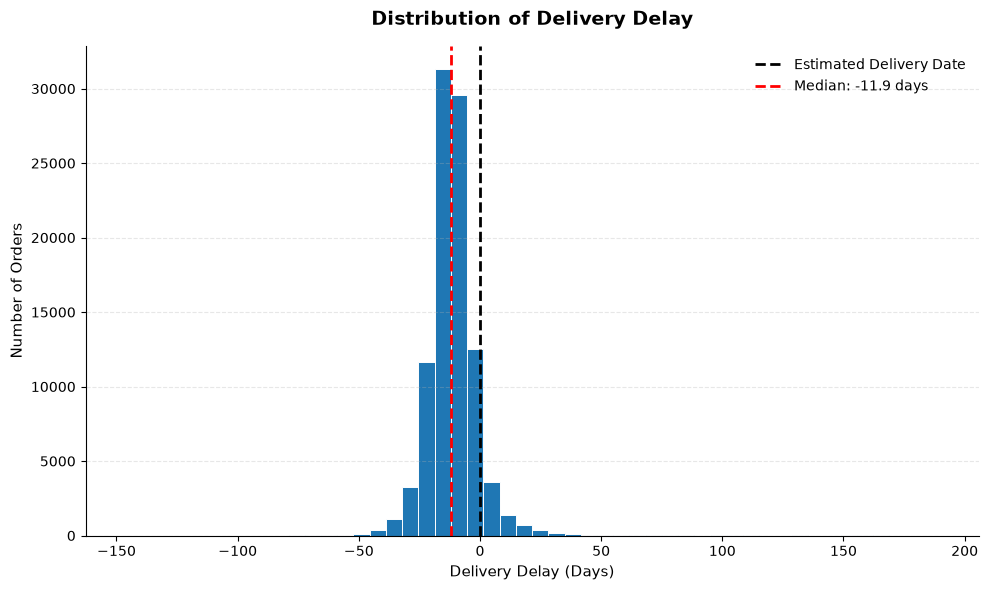

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(
    orders["delivery_delay_days"].dropna(),
    bins=50,
    edgecolor="white",
    linewidth=0.7
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Estimated Delivery Date"
)

median_delay = orders["delivery_delay_days"].median()

plt.axvline(
    median_delay,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_delay:.1f} days"
)

plt.xlabel("Delivery Delay (Days)", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)

plt.title(
    "Distribution of Delivery Delay",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(frameon=False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The median delivery delay was approximately **-12 days**, meaning that half of the delivered orders arrived at least 12 days before the estimated delivery date.

This indicates that delivery estimates were generally conservative, with customers typically receiving their orders earlier than expected.

#### 4.5.4 Extreme Delay Impact

This analysis measures the proportion of orders classified as extreme delays to assess their overall impact on the dataset.

Understanding their frequency helps determine whether these observations are likely to materially affect the overall delivery performance analysis.

In [43]:
total_deliveries = orders["delivery_delay_days"].notna().sum()
extreme_count = len(extreme_delays)

extreme_percentage = (
    extreme_count / total_deliveries * 100
)

print(f"Total deliveries analyzed: {total_deliveries:,}")
print(f"Extreme delays: {extreme_count:,}")
print(f"Percentage of extreme delays: {extreme_percentage:.2f}%")

Total deliveries analyzed: 96,476
Extreme delays: 965
Percentage of extreme delays: 1.00%


Extreme delivery delays accounted for approximately **1.00% of all analyzed deliveries**.

Although these extreme cases can have a significant impact on individual customers, their low frequency suggests that they do not represent the typical delivery experience in the dataset.

### 4.6 Delivery Performance Over Time

This section analyzes delivery performance over time to identify changes and trends in the marketplace's operational efficiency.

The analysis focuses on monthly delivery times and late delivery rates to determine whether delivery performance improved or declined during the period covered by the dataset.

#### 4.6.1 Monthly Delivery Time

To analyze delivery performance over time, the purchase date is grouped by month.

The median delivery time is then calculated for each month. The median is used instead of the mean because the previous analysis identified extreme delivery delays that could disproportionately affect the average.

Monthly order volume is also calculated to provide context for each monthly metric.

In [44]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

The monthly median delivery time is calculated using the purchase month as the grouping variable.

In [45]:
monthly_delivery = (
    orders
    .groupby("purchase_month")["delivery_days"]
    .median()
)

monthly_delivery

purchase_month
2016-09    54.813194
2016-10    17.921157
2016-12     4.693021
2017-01    10.733646
2017-02    10.971204
2017-03    10.126487
2017-04    12.748623
2017-05     9.793333
2017-06    10.804907
2017-07    10.158073
2017-08     9.769815
2017-09    10.314433
2017-10    10.263362
2017-11    12.698681
2017-12    13.142188
2018-01    11.830116
2018-02    14.265509
2018-03    13.367731
2018-04     9.314728
2018-05     9.147870
2018-06     7.957616
2018-07     7.501725
2018-08     7.013704
2018-09          NaN
2018-10          NaN
Freq: M, Name: delivery_days, dtype: float64

In [46]:
monthly_orders = (
    orders
    .groupby("purchase_month")["delivery_days"]
    .count()
)

monthly_orders

purchase_month
2016-09       1
2016-10     270
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3545
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7288
2017-12    5513
2018-01    7069
2018-02    6556
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6096
2018-07    6156
2018-08    6351
2018-09       0
2018-10       0
Freq: M, Name: delivery_days, dtype: int64

In [47]:
monthly_delivery_summary = pd.DataFrame({
    "Median Delivery Days": monthly_delivery,
    "Orders": monthly_orders
})

monthly_delivery_summary

,Median Delivery Days,Orders
purchase_month,,
2016-09,54.813194,1
2016-10,17.921157,270
2016-12,4.693021,1
2017-01,10.733646,750
2017-02,10.971204,1653
2017-03,10.126487,2546
2017-04,12.748623,2303
2017-05,9.793333,3545
2017-06,10.804907,3135


In [48]:
monthly_delivery_summary = monthly_delivery_summary[
    monthly_delivery_summary["Orders"] > 0
]

monthly_delivery_summary

,Median Delivery Days,Orders
purchase_month,,
2016-09,54.813194,1
2016-10,17.921157,270
2016-12,4.693021,1
2017-01,10.733646,750
2017-02,10.971204,1653
2017-03,10.126487,2546
2017-04,12.748623,2303
2017-05,9.793333,3545
2017-06,10.804907,3135


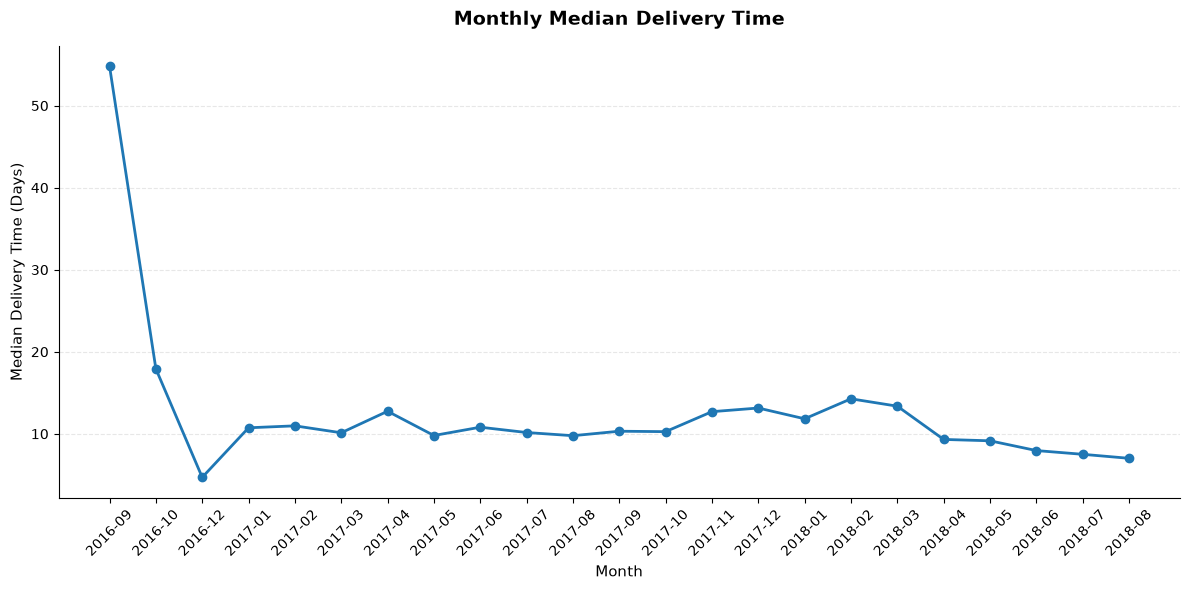

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_delivery_summary.index.astype(str),
    monthly_delivery_summary["Median Delivery Days"],
    marker="o",
    linewidth=2
)

plt.xlabel("Month", fontsize=11)
plt.ylabel("Median Delivery Time (Days)", fontsize=11)

plt.title(
    "Monthly Median Delivery Time",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=45)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

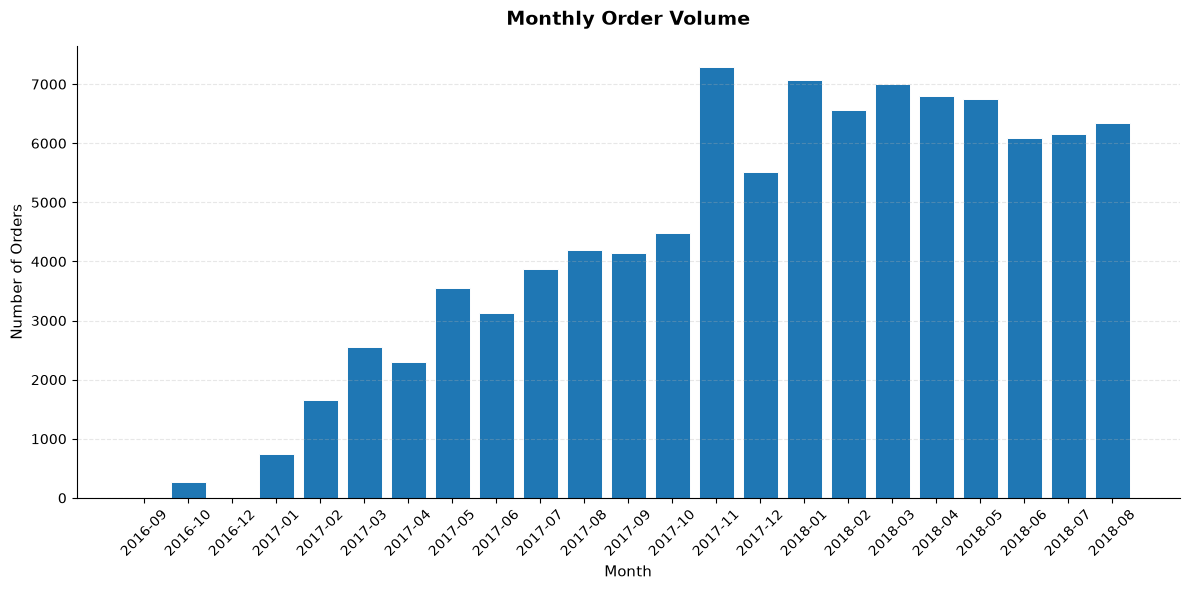

In [50]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_delivery_summary.index.astype(str),
    monthly_delivery_summary["Orders"],
    edgecolor="white",
    linewidth=0.7
)

plt.xlabel("Month", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)

plt.title(
    "Monthly Order Volume",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=45)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Median delivery time remained relatively stable throughout most of 2017, generally ranging between 9 and 13 days.

Delivery times increased slightly during the first quarter of 2018, reaching a median of approximately 14 days in February.

However, delivery performance improved considerably from April onward, with median delivery time declining from approximately 9.3 days in April to 7.0 days in August.

Months with very low order volumes, such as September and December 2016, were not considered when interpreting the overall trend.

#### 4.6.2 Late Delivery Rate Over Time

While median delivery time shows how quickly orders were delivered, it does not indicate how consistently the marketplace met its estimated delivery dates.

This analysis calculates the monthly late delivery rate to evaluate delivery reliability over time and identify periods with unusually high or low rates of late deliveries.

Months with very low order volumes are excluded from the comparison to avoid drawing conclusions from insufficient observations.

In [51]:
monthly_late_rate = (
    orders
    .groupby("purchase_month")["delivery_performance"]
    .apply(
        lambda x: (x == "Late").mean() * 100
    )
)

monthly_late_rate

purchase_month
2016-09    25.000000
2016-10     0.925926
2016-12     0.000000
2017-01     2.875000
2017-02     2.977528
2017-03     5.294556
2017-04     7.529118
2017-05     3.459459
2017-06     3.728814
2017-07     3.303527
2017-08     3.209420
2017-09     5.040840
2017-10     5.117685
2017-11    13.825557
2017-12     8.143839
2018-01     6.383271
2018-02    15.591558
2018-03    20.746082
2018-04     5.202479
2018-05     8.089626
2018-06     1.345873
2018-07     4.386523
2018-08    10.135135
2018-09     0.000000
2018-10     0.000000
Freq: M, Name: delivery_performance, dtype: float64

To provide context for the monthly late delivery rate, the number of orders analyzed in each month is also calculated.

This helps distinguish meaningful changes in delivery performance from fluctuations caused by very small sample sizes.

In [52]:
monthly_orders = (
    orders
    .groupby("purchase_month")["delivery_days"]
    .count()
)

monthly_orders

purchase_month
2016-09       1
2016-10     270
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3545
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7288
2017-12    5513
2018-01    7069
2018-02    6556
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6096
2018-07    6156
2018-08    6351
2018-09       0
2018-10       0
Freq: M, Name: delivery_days, dtype: int64

In [53]:
monthly_late_summary = pd.DataFrame({
    "Late Delivery Rate (%)": monthly_late_rate,
    "Orders": monthly_orders
})

monthly_late_summary

,Late Delivery Rate (%),Orders
purchase_month,,
2016-09,25.000000,1
2016-10,0.925926,270
2016-12,0.000000,1
2017-01,2.875000,750
2017-02,2.977528,1653
2017-03,5.294556,2546
2017-04,7.529118,2303
2017-05,3.459459,3545
2017-06,3.728814,3135


Because some early months contain very few orders, their late delivery rates can be misleading.

For example, a single late order can produce a late delivery rate of 100%. To improve the reliability of the comparison, only months with at least 500 analyzed orders are included in the monthly trend.

In [54]:
monthly_late_summary = monthly_late_summary[
    monthly_late_summary["Orders"] >= 500
]

monthly_late_summary

,Late Delivery Rate (%),Orders
purchase_month,,
2017-01,2.875000,750
2017-02,2.977528,1653
2017-03,5.294556,2546
2017-04,7.529118,2303
2017-05,3.459459,3545
2017-06,3.728814,3135
2017-07,3.303527,3872
2017-08,3.209420,4193
2017-09,5.040840,4150


The overall late delivery rate is calculated as a benchmark against which monthly performance can be compared.

In [55]:
overall_late_rate = (
    orders["delivery_performance"]
    .eq("Late")
    .mean() * 100
)

print(
    f"Overall late delivery rate: "
    f"{overall_late_rate:.2f}%"
)

Overall late delivery rate: 7.87%


The monthly late delivery rate is visualized below to identify changes in delivery reliability over time.

The overall late delivery rate is included as a reference line to make it easier to identify months performing above or below the marketplace-wide average.

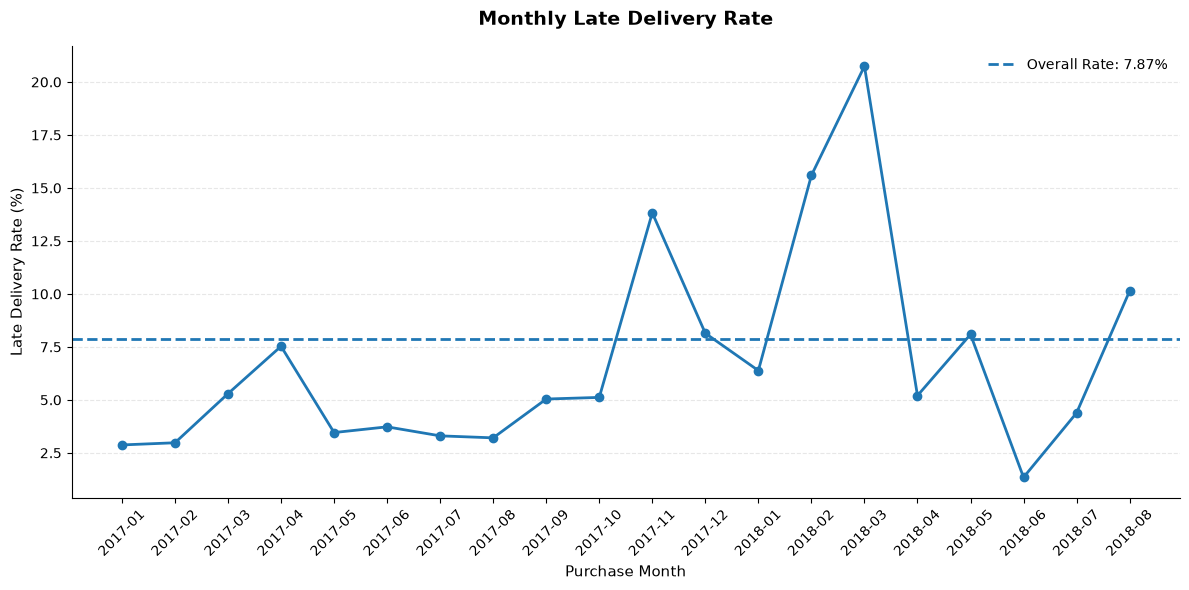

In [56]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_late_summary.index.astype(str),
    monthly_late_summary["Late Delivery Rate (%)"],
    marker="o",
    linewidth=2
)

plt.axhline(
    overall_late_rate,
    linestyle="--",
    linewidth=2,
    label=f"Overall Rate: {overall_late_rate:.2f}%"
)

plt.xlabel(
    "Purchase Month",
    fontsize=11
)

plt.ylabel(
    "Late Delivery Rate (%)",
    fontsize=11
)

plt.title(
    "Monthly Late Delivery Rate",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=45)

plt.legend(frameon=False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [57]:
late_rate_max = monthly_late_summary["Late Delivery Rate (%)"].max()
late_rate_min = monthly_late_summary["Late Delivery Rate (%)"].min()

late_rate_range = late_rate_max - late_rate_min

print(f"Minimum monthly late rate: {late_rate_min:.2f}%")
print(f"Maximum monthly late rate: {late_rate_max:.2f}%")
print(f"Range: {late_rate_range:.2f} percentage points")

Minimum monthly late rate: 1.35%
Maximum monthly late rate: 20.75%
Range: 19.40 percentage points


In [58]:
overall_late_rate = (
    orders["delivery_performance"]
    .eq("Late")
    .mean() * 100
)

print(f"Overall late delivery rate: {overall_late_rate:.2f}%")

Overall late delivery rate: 7.87%


#### Quantifying Monthly Variation

To quantify the observed fluctuations, the minimum and maximum monthly late delivery rates are compared across months with sufficient order volume.

In [59]:
late_rate_min = (
    monthly_late_summary["Late Delivery Rate (%)"]
    .min()
)

late_rate_max = (
    monthly_late_summary["Late Delivery Rate (%)"]
    .max()
)

late_rate_range = late_rate_max - late_rate_min

print(
    f"Minimum monthly late rate: "
    f"{late_rate_min:.2f}%"
)

print(
    f"Maximum monthly late rate: "
    f"{late_rate_max:.2f}%"
)

print(
    f"Range: "
    f"{late_rate_range:.2f} percentage points"
)

Minimum monthly late rate: 1.35%
Maximum monthly late rate: 20.75%
Range: 19.40 percentage points


#### Months with the Highest Late Delivery Rates

The months with the highest late delivery rates are identified to investigate periods of particularly poor delivery reliability.

In [60]:
top_late_months = (
    monthly_late_summary
    .sort_values(
        "Late Delivery Rate (%)",
        ascending=False
    )
    .head(5)
)

top_late_months

,Late Delivery Rate (%),Orders
purchase_month,,
2018-03,20.746082,7003
2018-02,15.591558,6556
2017-11,13.825557,7288
2018-08,10.135135,6351
2017-12,8.143839,5513


In [61]:
best_late_months = (
    monthly_late_summary
    .sort_values(
        "Late Delivery Rate (%)"
    )
    .head(5)
)

best_late_months

,Late Delivery Rate (%),Orders
purchase_month,,
2018-06,1.345873,6096
2017-01,2.875000,750
2017-02,2.977528,1653
2017-08,3.209420,4193
2017-07,3.303527,3872


The overall late delivery rate was **7.87%**, meaning that approximately 8 out of every 100 analyzed deliveries arrived after the estimated delivery date.

However, monthly performance varied considerably over time. Among months with at least 500 analyzed orders, the late delivery rate ranged from approximately **1.35% to 20.75%**.

The most significant deterioration occurred in early 2018, when the late delivery rate increased to **15.59% in February** and reached **20.75% in March**.

This was followed by a sharp improvement in April 2018, when the rate fell to **5.20%**. The results therefore suggest that late delivery performance was not consistently stable throughout the period, with several periods of substantially higher delivery delays.

Further analysis would be required to determine the operational factors behind these fluctuations.

#### 4.6.3 Delivery Time vs. Late Delivery Rate

The previous analysis showed that both delivery time and late delivery rates varied across months.

This section examines whether months with longer delivery times also experienced higher rates of late deliveries.

Comparing these two metrics can help determine whether slower delivery periods were associated with lower delivery reliability.

In [62]:
monthly_delivery_time = (
    orders
    .groupby("purchase_month")["delivery_days"]
    .median()
    .rename("Median Delivery Days")
)

monthly_performance = pd.concat(
    [
        monthly_delivery_time,
        monthly_late_summary["Late Delivery Rate (%)"],
        monthly_late_summary["Orders"]
    ],
    axis=1
)

monthly_performance

,Median Delivery Days,Late Delivery Rate (%),Orders
purchase_month,,,
2016-09,54.813194,NaN,NaN
2016-10,17.921157,NaN,NaN
2016-12,4.693021,NaN,NaN
2017-01,10.733646,2.875000,750.0
2017-02,10.971204,2.977528,1653.0
2017-03,10.126487,5.294556,2546.0
2017-04,12.748623,7.529118,2303.0
2017-05,9.793333,3.459459,3545.0
2017-06,10.804907,3.728814,3135.0


In [63]:
monthly_performance = monthly_performance[
    monthly_performance["Orders"] >= 500
].copy()

monthly_performance

,Median Delivery Days,Late Delivery Rate (%),Orders
purchase_month,,,
2017-01,10.733646,2.875000,750.0
2017-02,10.971204,2.977528,1653.0
2017-03,10.126487,5.294556,2546.0
2017-04,12.748623,7.529118,2303.0
2017-05,9.793333,3.459459,3545.0
2017-06,10.804907,3.728814,3135.0
2017-07,10.158073,3.303527,3872.0
2017-08,9.769815,3.209420,4193.0
2017-09,10.314433,5.040840,4150.0


#### Relationship Between Delivery Time and Late Delivery Rate

The scatter plot below compares monthly median delivery time with the corresponding late delivery rate.

Each point represents a month with at least 500 analyzed orders. A linear trend line is included to visualize the overall direction of the relationship.

To improve readability, only the five months with the highest late delivery rates are labeled.

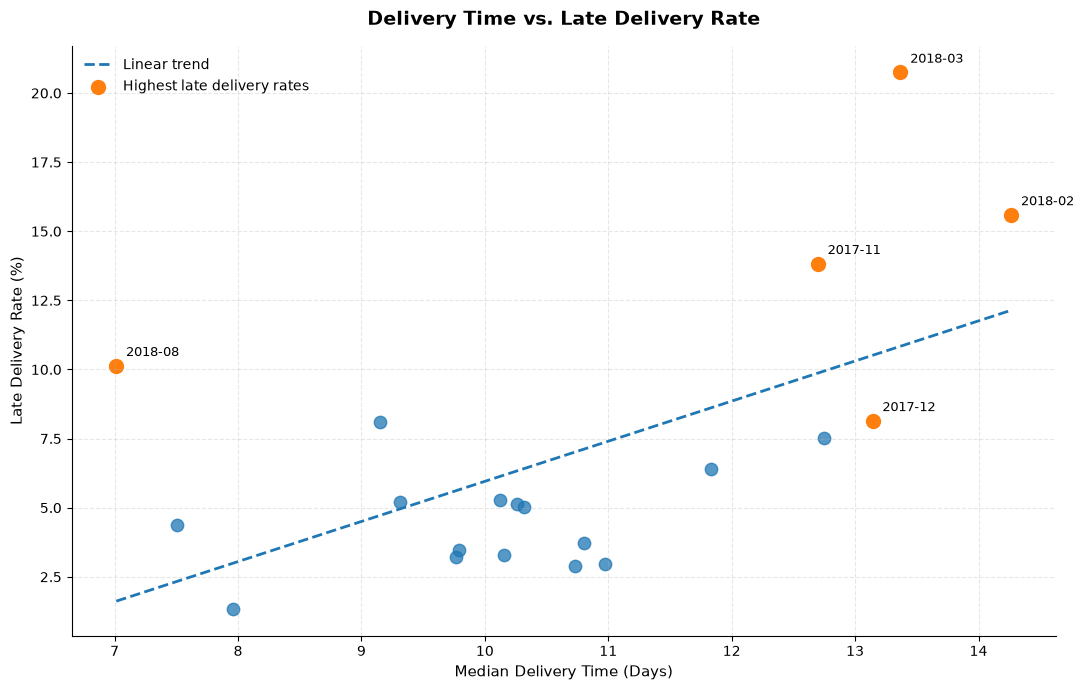

In [64]:
import numpy as np

plt.figure(figsize=(11, 7))

x = monthly_performance["Median Delivery Days"]
y = monthly_performance["Late Delivery Rate (%)"]

# Scatter plot
plt.scatter(
    x,
    y,
    s=80,
    alpha=0.75
)

# Linear trend line
z = np.polyfit(x, y, 1)
trend = np.poly1d(z)

x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(
    x_line,
    trend(x_line),
    linestyle="--",
    linewidth=2,
    label="Linear trend"
)

# Highlight top 5 months with highest late delivery rate
top_months = (
    monthly_performance
    .nlargest(5, "Late Delivery Rate (%)")
)

plt.scatter(
    top_months["Median Delivery Days"],
    top_months["Late Delivery Rate (%)"],
    s=100,
    label="Highest late delivery rates"
)

# Add labels only to the top 5 months
for month, row in top_months.iterrows():
    plt.annotate(
        str(month),
        (
            row["Median Delivery Days"],
            row["Late Delivery Rate (%)"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel(
    "Median Delivery Time (Days)",
    fontsize=11
)

plt.ylabel(
    "Late Delivery Rate (%)",
    fontsize=11
)

plt.title(
    "Delivery Time vs. Late Delivery Rate",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="both",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    frameon=False
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [65]:
correlation = monthly_performance[
    [
        "Median Delivery Days",
        "Late Delivery Rate (%)"
    ]
].corr().iloc[0, 1]

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.581


The Pearson correlation coefficient between median delivery time and late delivery rate is **0.581**.

This indicates a **moderate positive relationship** between the two metrics. In general, months with longer median delivery times tended to have higher late delivery rates.

However, the relationship is not strong enough to suggest that delivery time alone explains monthly variations in late delivery rates. Other operational factors may also contribute to delivery performance.

#### Correlation Result

The Pearson correlation coefficient between median delivery time and late delivery rate is **0.581**.

This indicates a **moderate positive relationship** between the two metrics. In general, months with longer median delivery times tended to have higher late delivery rates.

However, the relationship is not strong enough to suggest that delivery time alone explains monthly variations in late delivery rates. Other operational factors may also contribute to delivery performance.

In [66]:
top_late_months = (
    monthly_performance
    .nlargest(5, "Late Delivery Rate (%)")
)

top_late_months[
    [
        "Median Delivery Days",
        "Late Delivery Rate (%)",
        "Orders"
    ]
]

,Median Delivery Days,Late Delivery Rate (%),Orders
purchase_month,,,
2018-03,13.367731,20.746082,7003.0
2018-02,14.265509,15.591558,6556.0
2017-11,12.698681,13.825557,7288.0
2018-08,7.013704,10.135135,6351.0
2017-12,13.142188,8.143839,5513.0


The analysis found a Pearson correlation of **0.581** between median delivery time and late delivery rate, indicating a moderate positive relationship.

This suggests that periods with longer delivery times generally tended to experience a higher proportion of late deliveries. However, the relationship is not strong enough to explain late delivery performance through delivery time alone.

For example, **March 2018** recorded the highest late delivery rate at **20.75%**, with a median delivery time of **13.37 days**. In contrast, **August 2018** had a relatively low median delivery time of **7.01 days**, but still recorded a late delivery rate of **10.14%**.

These differences indicate that delivery speed and delivery reliability are related but distinct aspects of operational performance.

## 4.7 Delivery Performance & Customer Satisfaction

This section examines whether delivery performance is associated with customer satisfaction.

The analysis compares review scores between orders that were delivered on time and orders that were delivered late.

The objective is to determine whether delays may be associated with a poorer customer experience.

#### 4.7.1 Review Scores by Delivery Performance

To compare customer satisfaction with delivery performance, order-level delivery information is combined with customer review scores using the order ID.

Only orders with both delivery performance information and a review score are included in the analysis.

In [67]:
orders_reviews = orders[
    [
        "order_id",
        "delivery_performance",
        "delivery_days",
        "delivery_delay_days"
    ]
].merge(
    reviews[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="inner"
)

orders_reviews.head()

,order_id,delivery_performance,delivery_days,delivery_delay_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,On Time,8.436574,-7.107488,4
1,53cdb2fc8bc7dce0b6741e2150273451,On Time,13.782037,-5.355729,4
2,47770eb9100c2d0c44946d9cf07ec65d,On Time,9.394213,-17.245498,5
3,949d5b44dbf5de918fe9c16f97b45f8a,On Time,13.208750,-12.980069,5
4,ad21c59c0840e6cb83a9ceb5573f8159,On Time,2.873877,-9.238171,5


#### 4.7.2 Data Validation

Before comparing review scores, the merged dataset is checked for missing values and duplicate order IDs.

In [68]:
print("Rows:", len(orders_reviews))

print(
    "\nMissing values:"
)

print(
    orders_reviews[
        [
            "delivery_performance",
            "review_score"
        ]
    ].isna().sum()
)

print(
    "\nUnique orders:",
    orders_reviews["order_id"].nunique()
)

Rows: 99224

Missing values:
delivery_performance    2865
review_score               0
dtype: int64

Unique orders: 98673


In [69]:
orders_reviews["delivery_performance"].value_counts()

delivery_performance
On Time    88658
Late        7701
Name: count, dtype: int64

In [70]:
orders_reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

#### 4.7.3 Average Review Score by Delivery Performance

The average review score is calculated for on-time and late deliveries to identify differences in customer satisfaction between the two groups.

In [71]:
review_by_delivery = (
    orders_reviews
    .groupby("delivery_performance")["review_score"]
    .agg(
        ["mean", "median", "count"]
    )
    .round(2)
)

review_by_delivery

,mean,median,count
delivery_performance,,,
Late,2.57,2.0,7701
On Time,4.29,5.0,88658


#### 4.7.4 Average Review Score by Delivery Status

The average review score is visualized to make the difference in customer satisfaction between late and on-time deliveries easier to compare.

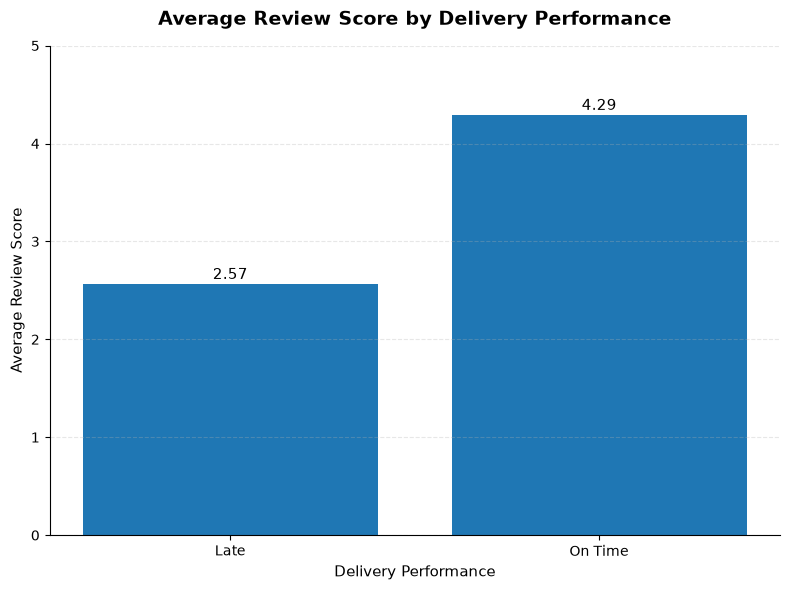

In [72]:
review_means = (
    orders_reviews
    .groupby("delivery_performance")["review_score"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 6))

bars = plt.bar(
    review_means.index,
    review_means.values
)

plt.xlabel(
    "Delivery Performance",
    fontsize=11
)

plt.ylabel(
    "Average Review Score",
    fontsize=11
)

plt.title(
    "Average Review Score by Delivery Performance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.ylim(0, 5)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Add values above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

#### 4.7.5 Difference in Customer Satisfaction

The difference in average review scores between on-time and late deliveries is calculated to quantify the potential association between delivery performance and customer satisfaction.

In [73]:
on_time_score = (
    orders_reviews.loc[
        orders_reviews["delivery_performance"] == "On Time",
        "review_score"
    ].mean()
)

late_score = (
    orders_reviews.loc[
        orders_reviews["delivery_performance"] == "Late",
        "review_score"
    ].mean()
)

score_difference = on_time_score - late_score

print(
    f"Average review score - On Time: "
    f"{on_time_score:.2f}"
)

print(
    f"Average review score - Late: "
    f"{late_score:.2f}"
)

print(
    f"Difference: "
    f"{score_difference:.2f} points"
)

Average review score - On Time: 4.29
Average review score - Late: 2.57
Difference: 1.73 points


#### 4.7.6 Review Score Distribution by Delivery Performance

Average review scores provide a useful summary, but they may hide differences in the distribution of individual ratings.

The distribution of review scores is therefore compared between on-time and late deliveries.

In [74]:
review_distribution = pd.crosstab(
    orders_reviews["delivery_performance"],
    orders_reviews["review_score"],
    normalize="index"
) * 100

review_distribution = review_distribution.round(2)

review_distribution

review_score,1,2,3,4,5
delivery_performance,,,,,
Late,46.15,7.87,11.38,12.39,22.22
On Time,6.60,2.63,7.99,20.34,62.43


#### 4.7.7 Review Score Composition

A 100% stacked bar chart is used to compare the composition of review scores between late and on-time deliveries.

This allows the relative proportion of low and high ratings to be compared independently of the number of orders in each group.

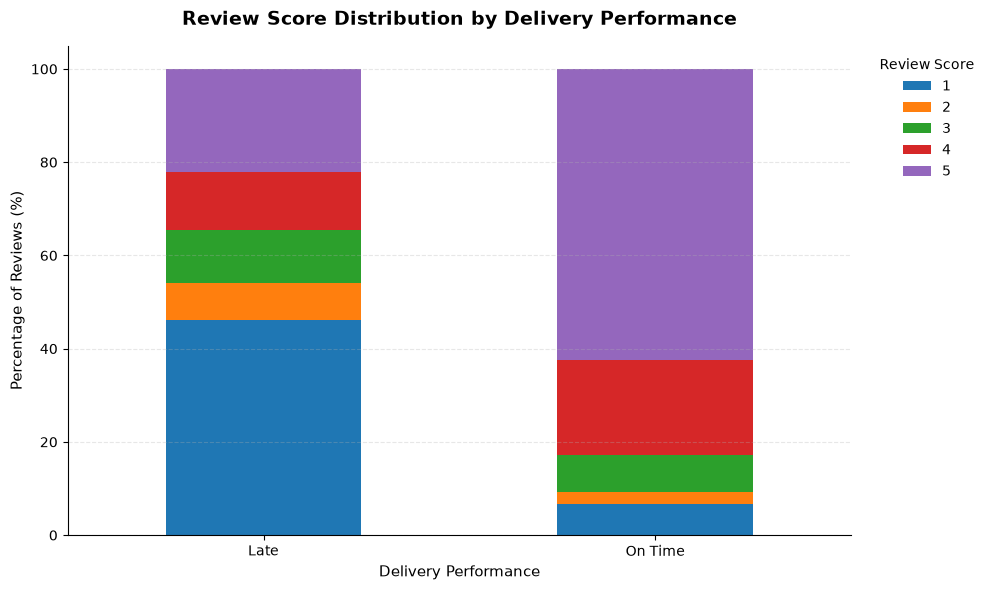

In [75]:
review_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel(
    "Delivery Performance",
    fontsize=11
)

plt.ylabel(
    "Percentage of Reviews (%)",
    fontsize=11
)

plt.title(
    "Review Score Distribution by Delivery Performance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Review Score",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### 4.7.8 Low Review Rate by Delivery Performance

Low review scores are examined separately because they may provide a stronger indication of customer dissatisfaction than the overall average score.

In [76]:
low_review_rate = (
    orders_reviews
    .groupby("delivery_performance")["review_score"]
    .apply(
        lambda x: (x <= 2).mean() * 100
    )
    .round(2)
)

low_review_rate

delivery_performance
Late       54.02
On Time     9.24
Name: review_score, dtype: float64

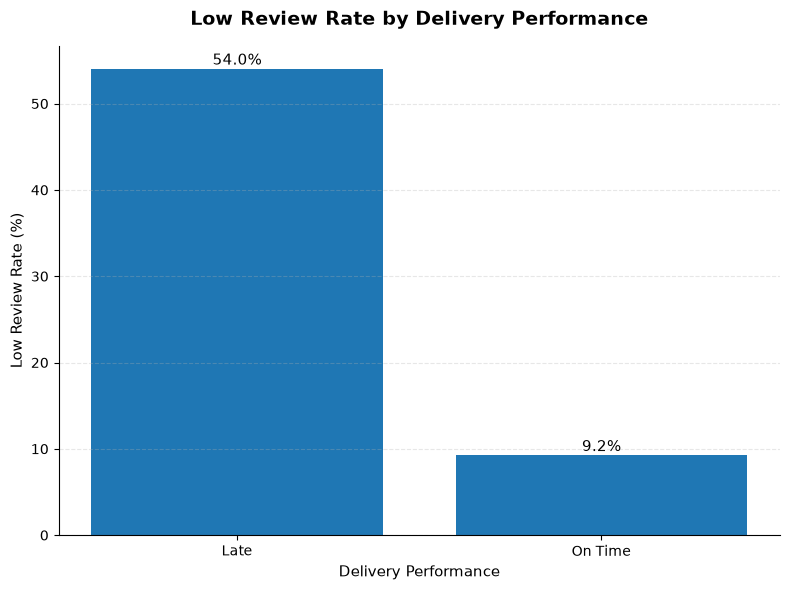

In [77]:
plt.figure(figsize=(8, 6))

bars = plt.bar(
    low_review_rate.index,
    low_review_rate.values
)

plt.xlabel(
    "Delivery Performance",
    fontsize=11
)

plt.ylabel(
    "Low Review Rate (%)",
    fontsize=11
)

plt.title(
    "Low Review Rate by Delivery Performance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

The analysis shows a substantial association between delivery performance and customer dissatisfaction.

Late deliveries had an average review score of **2.57**, compared with **4.29** for on-time deliveries, representing a difference of **1.73 points**.

The difference is even more pronounced when focusing on low ratings. **54.0%** of reviews associated with late deliveries received a score of 1 or 2, compared with only **9.2%** among on-time deliveries.

This means that the proportion of low ratings was almost **six times higher** for late deliveries.

These results suggest that delivery performance is strongly associated with customer satisfaction. However, the analysis identifies an association rather than a causal relationship, as other factors such as product quality, seller performance, payment issues, or customer expectations may also influence review scores.

## 4.8 Payment & Order Value Analysis

This section analyzes customer payment behavior and order value across the Olist marketplace.

The analysis focuses on payment methods, transaction values, and installment patterns to understand how customers pay for their purchases and how order value varies across payment types.

### 4.8.1 Payment Method Distribution

This analysis examines the distribution of payment methods used by customers.

Understanding payment preferences provides insight into customer purchasing behavior and the relative importance of each payment method on the marketplace.

In [78]:
payment_method_counts = (
    payments["payment_type"]
    .value_counts()
)

payment_method_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
Name: count, dtype: int64

In [79]:
payment_method_percentage = (
    payments["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_method_percentage

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
Name: proportion, dtype: float64

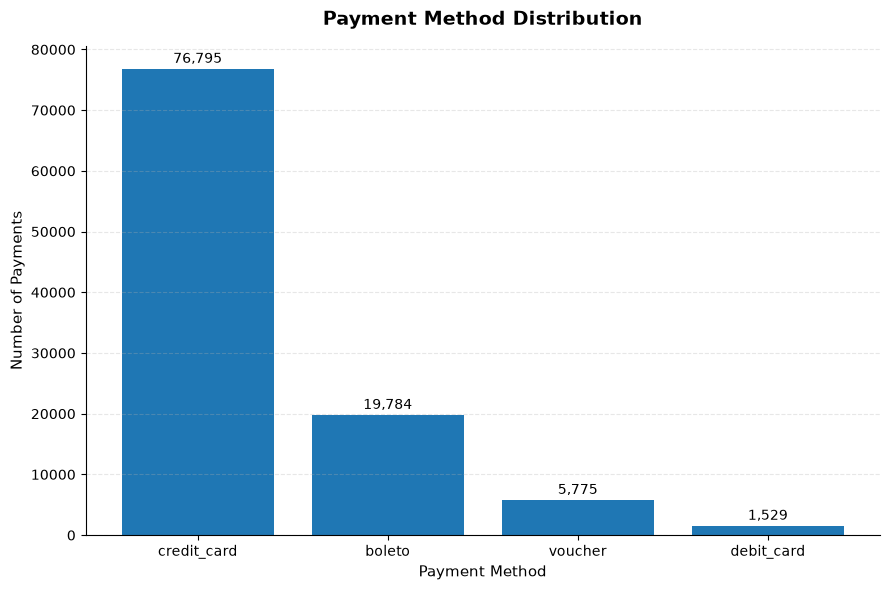

In [80]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    payment_method_counts.index,
    payment_method_counts.values
)

plt.xlabel(
    "Payment Method",
    fontsize=11
)

plt.ylabel(
    "Number of Payments",
    fontsize=11
)

plt.title(
    "Payment Method Distribution",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1000,
        f"{height:,}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### 4.8.3 Order Value Distribution

The payment dataset may contain multiple payment records for a single order, such as orders split across different payment methods.

Therefore, payment values are aggregated at the order level before analyzing the distribution of order value.

In [81]:
order_value = (
    payments
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index(name="order_value")
)

order_value["order_value"].describe()

count    99437.000000
mean       160.995124
std        221.952843
min          9.590000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: order_value, dtype: float64

In [82]:
p99 = order_value["order_value"].quantile(0.99)

p99

np.float64(1075.7975999999999)

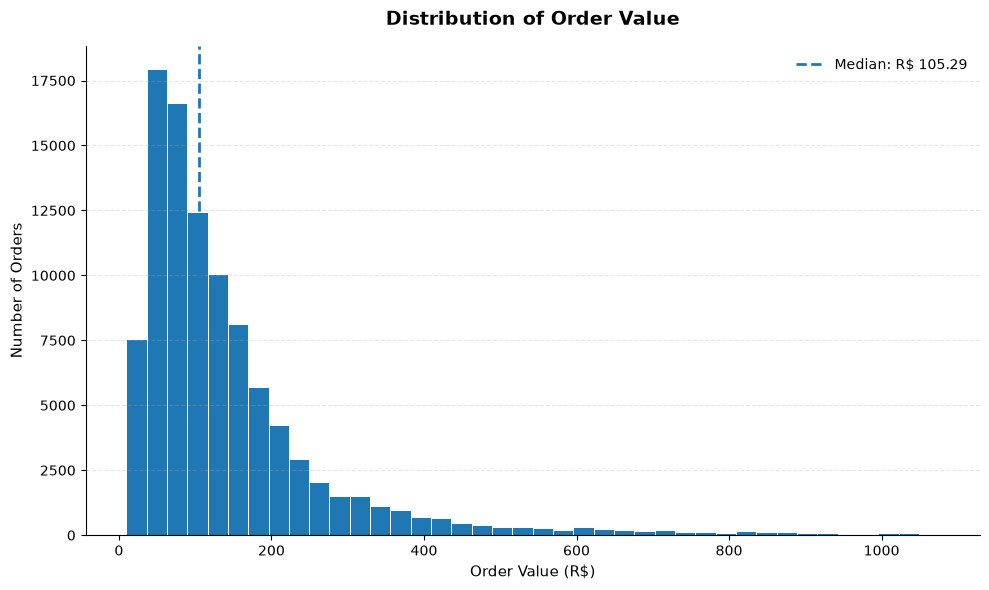

In [83]:
order_value_plot = order_value[
    order_value["order_value"] <= p99
]

plt.figure(figsize=(10, 6))

plt.hist(
    order_value_plot["order_value"],
    bins=40,
    edgecolor="white",
    linewidth=0.7
)

plt.axvline(
    order_value["order_value"].median(),
    linestyle="--",
    linewidth=2,
    label=f"Median: R$ {order_value['order_value'].median():.2f}"
)

plt.xlabel(
    "Order Value (R$)",
    fontsize=11
)

plt.ylabel(
    "Number of Orders",
    fontsize=11
)

plt.title(
    "Distribution of Order Value",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(frameon=False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### 4.8.3.1 High-Value Orders

The order value distribution is strongly right-skewed, with most orders concentrated at relatively low values and a small number of high-value orders extending the distribution.

To better understand the impact of these high-value orders, the 99th percentile is used as a reference point for identifying unusually high order values.

In [84]:
high_value_threshold = order_value["order_value"].quantile(0.99)

high_value_orders = order_value[
    order_value["order_value"] > high_value_threshold
]

print(
    f"99th percentile threshold: R$ {high_value_threshold:.2f}"
)

print(
    f"High-value orders: {len(high_value_orders):,}"
)

print(
    f"Percentage of orders: "
    f"{len(high_value_orders) / len(order_value) * 100:.2f}%"
)

99th percentile threshold: R$ 1075.80
High-value orders: 995
Percentage of orders: 1.00%


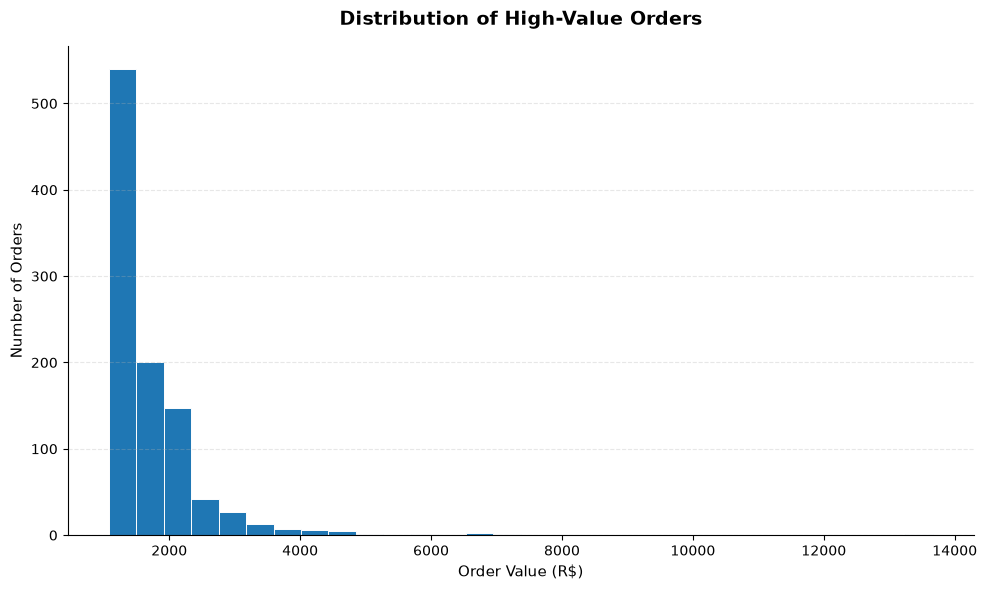

In [85]:
plt.figure(figsize=(10, 6))

plt.hist(
    high_value_orders["order_value"],
    bins=30,
    edgecolor="white",
    linewidth=0.7
)

plt.xlabel(
    "Order Value (R$)",
    fontsize=11
)

plt.ylabel(
    "Number of Orders",
    fontsize=11
)

plt.title(
    "Distribution of High-Value Orders",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The distribution of order values is highly right-skewed, indicating that most purchases have relatively low values while a small proportion of orders have substantially higher values.

The 99th percentile was used to improve visualization of the main distribution without removing high-value orders from the dataset.

These high-value transactions represent a small proportion of total orders but may have a disproportionate impact on marketplace revenue and should therefore be considered separately in financial analysis.

### 4.8.4 Payment Value by Payment Method

This analysis compares payment values across different payment methods to understand their financial importance within the Olist marketplace.

Both total and average payment values are examined, as transaction frequency alone does not indicate the overall financial contribution of each payment method.

In [86]:
payment_value_summary = (
    payments
    .groupby("payment_type")["payment_value"]
    .agg(
        total_value="sum",
        average_value="mean",
        median_value="median",
        transaction_count="count"
    )
    .sort_values(
        "total_value",
        ascending=False
    )
    .round(2)
)

payment_value_summary

,total_value,average_value,median_value,transaction_count
payment_type,,,,
credit_card,12542084.19,163.32,106.87,76795
boleto,2869361.27,145.03,93.89,19784
voucher,379436.87,65.70,39.28,5775
debit_card,217989.79,142.57,89.30,1529


In [87]:
payment_value_summary = (
    payments
    .groupby("payment_type")["payment_value"]
    .agg(
        total_value="sum",
        average_value="mean",
        median_value="median",
        transaction_count="count"
    )
    .sort_values(
        "total_value",
        ascending=False
    )
    .round(2)
)

payment_value_summary

,total_value,average_value,median_value,transaction_count
payment_type,,,,
credit_card,12542084.19,163.32,106.87,76795
boleto,2869361.27,145.03,93.89,19784
voucher,379436.87,65.70,39.28,5775
debit_card,217989.79,142.57,89.30,1529


In [88]:
payment_value_summary["value_share_pct"] = (
    payment_value_summary["total_value"]
    / payment_value_summary["total_value"].sum()
    * 100
).round(2)

payment_value_summary

,total_value,average_value,median_value,transaction_count,value_share_pct
payment_type,,,,,
credit_card,12542084.19,163.32,106.87,76795,78.34
boleto,2869361.27,145.03,93.89,19784,17.92
voucher,379436.87,65.70,39.28,5775,2.37
debit_card,217989.79,142.57,89.30,1529,1.36


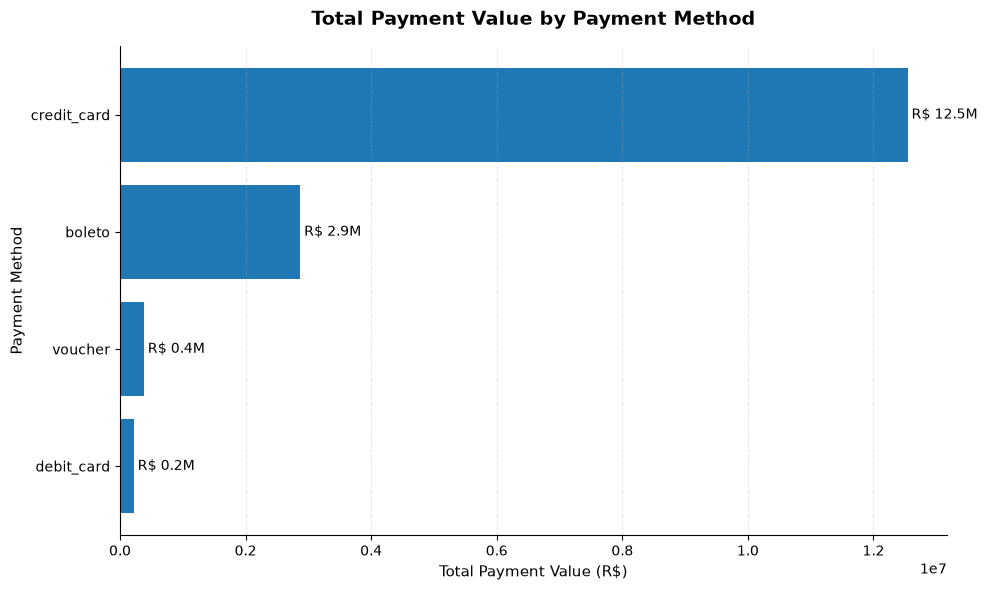

In [89]:
plt.figure(figsize=(10, 6))

payment_values = (
    payment_value_summary["total_value"]
    .sort_values()
)

bars = plt.barh(
    payment_values.index,
    payment_values.values
)

plt.xlabel(
    "Total Payment Value (R$)",
    fontsize=11
)

plt.ylabel(
    "Payment Method",
    fontsize=11
)

plt.title(
    "Total Payment Value by Payment Method",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" R$ {width / 1_000_000:.1f}M",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### 4.8.4.1 Average Payment Value

While total payment value reflects the overall financial contribution of each payment method, average payment value provides insight into the typical transaction size associated with each method.

Comparing these metrics helps distinguish between payment methods that are frequently used and those associated with higher-value transactions.

In [90]:
average_payment_value = (
    payments
    .groupby("payment_type")["payment_value"]
    .agg(
        mean="mean",
        median="median",
        count="count"
    )
    .sort_values(
        "mean",
        ascending=False
    )
    .round(2)
)

average_payment_value

,mean,median,count
payment_type,,,
credit_card,163.32,106.87,76795
boleto,145.03,93.89,19784
debit_card,142.57,89.30,1529
voucher,65.70,39.28,5775


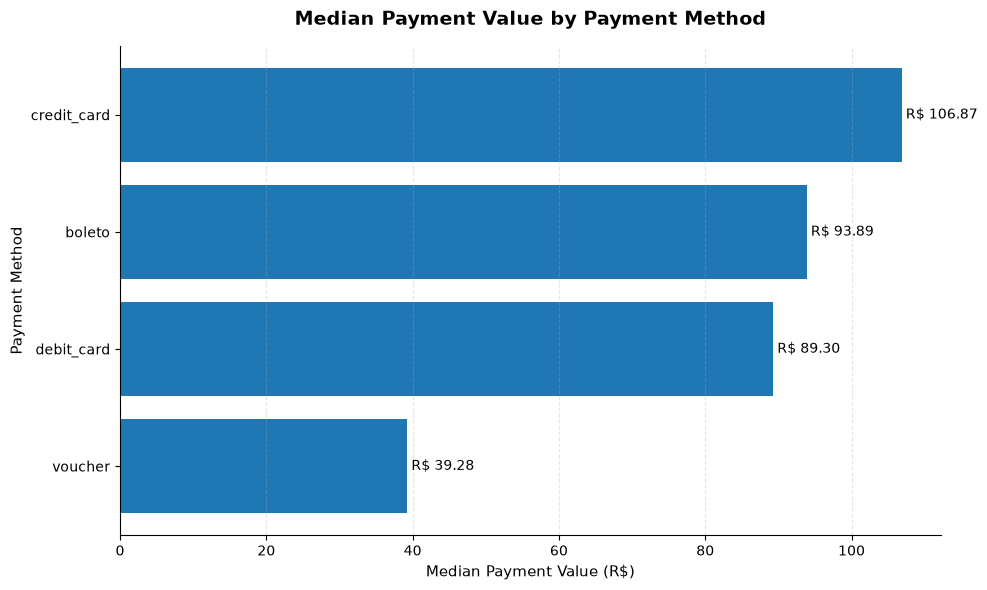

In [91]:
plt.figure(figsize=(10, 6))

payment_medians = (
    average_payment_value["median"]
    .sort_values()
)

bars = plt.barh(
    payment_medians.index,
    payment_medians.values
)

plt.xlabel(
    "Median Payment Value (R$)",
    fontsize=11
)

plt.ylabel(
    "Payment Method",
    fontsize=11
)

plt.title(
    "Median Payment Value by Payment Method",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" R$ {width:.2f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

> **Note:** The median is used as the primary measure of typical payment value because the presence of high-value transactions can substantially increase the mean.

### 4.8.5 Installment Analysis

Credit card payments can be divided into multiple installments, which may influence purchasing behavior and allow customers to finance higher-value purchases.

This analysis examines installment patterns among credit card transactions to understand how customers typically distribute their payments.

In [92]:
credit_card_payments = payments[
    payments["payment_type"] == "credit_card"
].copy()

installment_summary = (
    credit_card_payments["payment_installments"]
    .value_counts()
    .sort_index()
)

installment_summary

payment_installments
1     25457
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [93]:
installment_percentage = (
    credit_card_payments["payment_installments"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

installment_percentage

payment_installments
1     33.15
2     16.16
3     13.62
4      9.24
5      6.82
6      5.10
7      2.12
8      5.56
9      0.84
10     6.94
11     0.03
12     0.17
13     0.02
14     0.02
15     0.10
16     0.01
17     0.01
18     0.04
20     0.02
21     0.00
22     0.00
23     0.00
24     0.02
Name: proportion, dtype: float64

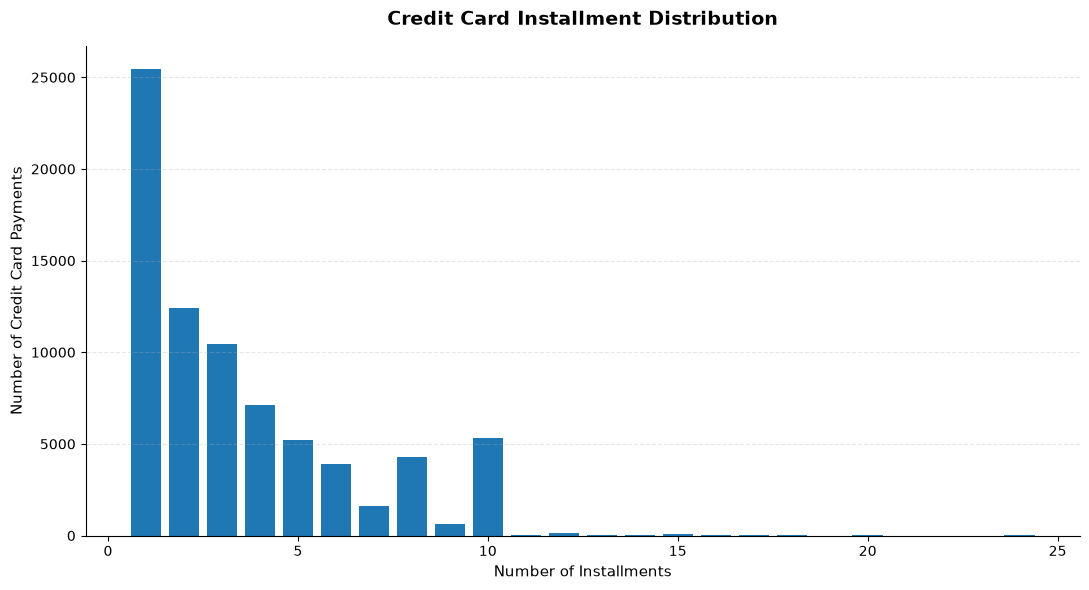

In [94]:
plt.figure(figsize=(11, 6))

plt.bar(
    installment_summary.index,
    installment_summary.values
)

plt.xlabel(
    "Number of Installments",
    fontsize=11
)

plt.ylabel(
    "Number of Credit Card Payments",
    fontsize=11
)

plt.title(
    "Credit Card Installment Distribution",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [95]:
most_common_installment = (
    credit_card_payments["payment_installments"]
    .mode()
    .iloc[0]
)

most_common_installment_percentage = (
    credit_card_payments["payment_installments"]
    .value_counts(normalize=True)
    .loc[most_common_installment]
    * 100
)

print(
    f"Most common installment option: "
    f"{most_common_installment} installments"
)

print(
    f"Share of credit card payments: "
    f"{most_common_installment_percentage:.2f}%"
)

Most common installment option: 1 installments
Share of credit card payments: 33.15%


#### 4.8.5.1 Typical Installment Behavior

The most common installment option is **1 installment**, accounting for **33.15%** of credit card transactions.

This provides an indication of the most typical installment behavior among customers using credit cards on the marketplace.

### 4.8.2 Payment Value by Payment Method

While payment frequency shows how often each payment method is used, transaction volume alone does not indicate its financial importance.

This analysis compares the **total payment value** generated by each payment method and calculates its share of the overall payment value.

The objective is to determine whether the payment methods with the highest transaction volume also account for the largest share of revenue.

In [96]:
payment_value_by_method = (
    payments.groupby("payment_type")
    .agg(
        total_value=("payment_value", "sum"),
        average_value=("payment_value", "mean"),
        median_value=("payment_value", "median"),
        transaction_count=("payment_value", "count")
    )
)

payment_value_by_method["value_share_pct"] = (
    payment_value_by_method["total_value"]
    / payment_value_by_method["total_value"].sum()
    * 100
)

payment_value_by_method = payment_value_by_method.sort_values(
    "total_value",
    ascending=False
)

payment_value_by_method

,total_value,average_value,median_value,transaction_count,value_share_pct
payment_type,,,,,
credit_card,12542084.19,163.319021,106.87,76795,78.344584
boleto,2869361.27,145.034435,93.89,19784,17.923569
voucher,379436.87,65.703354,39.28,5775,2.370166
debit_card,217989.79,142.570170,89.30,1529,1.361681


The results show that **credit card payments dominate the platform in terms of total payment value**, accounting for **78.34%** of the total payment value.

**Boleto** represents the second-largest share, contributing **17.92%** of the total payment value.

In comparison, **voucher** and **debit card** payments account for relatively small portions of the overall payment value, at **2.37%** and **1.36%**, respectively.

The ranking of payment methods by transaction count is therefore broadly consistent with their ranking by total payment value.

**Credit card payments are the dominant payment method both in transaction volume and total payment value. This suggests that maintaining a reliable and convenient credit card payment experience is particularly important for the platform.**

Boleto also represents a significant portion of payment activity and therefore remains an important alternative payment method, despite having substantially lower usage than credit cards.

### 4.8.3 Order Value Distribution

Understanding the distribution of order values helps identify the typical transaction size and determine whether a small number of high-value transactions may be influencing the overall average.

Because order values can vary substantially between customers, both the **mean and median** are examined.

The median is particularly useful because it represents the typical transaction value without being as strongly influenced by unusually large payments.

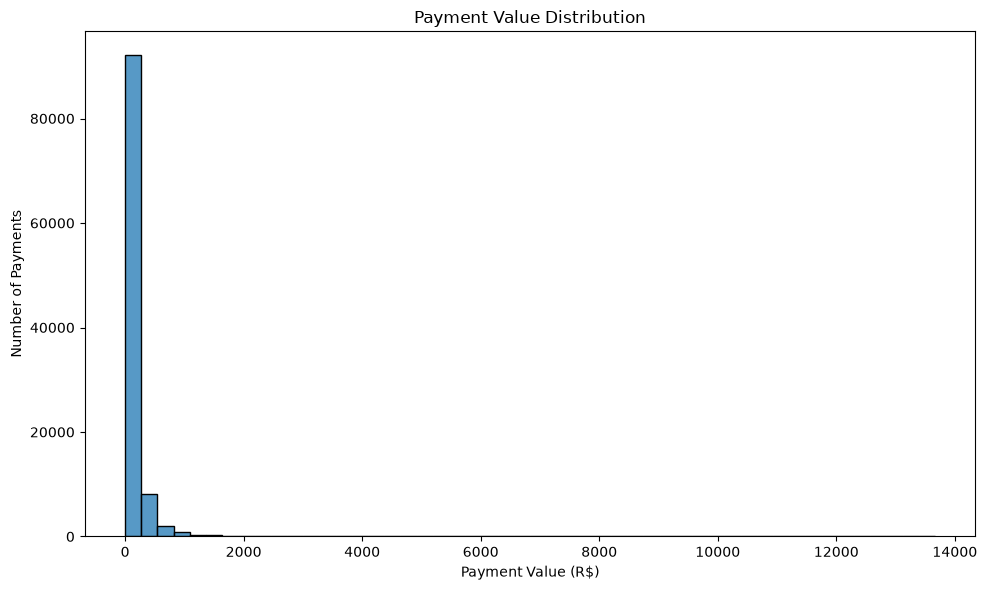

In [97]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=payments,
    x="payment_value",
    bins=50
)

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value (R$)")
plt.ylabel("Number of Payments")

plt.tight_layout()
plt.show()

#### Payment Value Distribution

The payment value distribution is visualized using a **R$2,000 upper limit** to focus on the range where the vast majority of transactions occur.

Extreme high-value payments are excluded from this visualization only to improve readability. They are retained in the dataset and analyzed separately as high-value transactions.

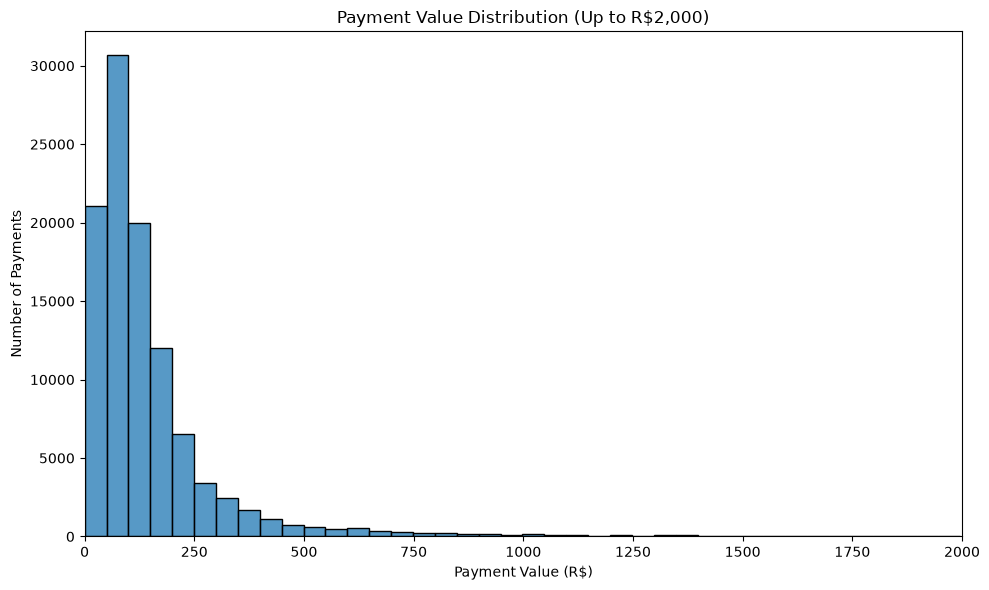

In [98]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=payments[payments["payment_value"] <= 2000],
    x="payment_value",
    bins=40
)

plt.title("Payment Value Distribution (Up to R$2,000)")
plt.xlabel("Payment Value (R$)")
plt.ylabel("Number of Payments")

plt.xlim(0, 2000)

plt.tight_layout()
plt.show()

In [99]:
payments["payment_value"].describe()

count    103883.000000
mean        154.104831
std         217.495628
min           0.000000
25%          56.800000
50%         100.000000
75%         171.840000
max       13664.080000
Name: payment_value, dtype: float64

In [100]:
payments[payments["payment_value"] > 2000].shape[0]

215

In [101]:
payments["payment_value"].gt(2000).mean() * 100

np.float64(0.20696360328446425)

The payment value distribution is highly concentrated in the lower-value range.

The **median payment value is R$100.00**, while the **mean is R$154.10**. The higher mean indicates a **right-skewed distribution**, where a relatively small number of high-value transactions increase the average.

The **75th percentile is R$171.84**, meaning that 75% of payment records have a value at or below this amount.

For visualization purposes, the histogram is limited to **R$2,000**. Only **0.21% of payment records exceed this value**, so including the extreme values would compress the main distribution and make the chart difficult to interpret.

The high-value payments are **not removed from the dataset** and are analyzed separately.

#### 4.8.3.1 High-Value Payments

High-value payments were defined as transactions with a payment value above **R$2,000**.

Only **215 payment records**, representing **0.21% of all payments**, exceeded this threshold.

Despite their low frequency, these transactions accounted for **3.64% of the total payment value**, with a combined value of approximately **R$583,448.75**.

The highest individual payment recorded was **R$13,664.08**.

In [102]:
high_value_payments = payments[
    payments["payment_value"] > 2000
]

high_value_summary = {
    "high_value_payments": len(high_value_payments),
    "percentage_of_payments": (
        len(high_value_payments) / len(payments) * 100
    ),
    "total_high_value": high_value_payments["payment_value"].sum(),
    "percentage_of_total_value": (
        high_value_payments["payment_value"].sum()
        / payments["payment_value"].sum()
        * 100
    ),
    "maximum_payment_value": high_value_payments["payment_value"].max()
}

high_value_summary

{'high_value_payments': 215,
 'percentage_of_payments': 0.20696360328446425,
 'total_high_value': np.float64(583448.75),
 'percentage_of_total_value': np.float64(3.644533766192643),
 'maximum_payment_value': np.float64(13664.08)}

The analysis shows that high-value payments are **rare but financially relevant**.

Although transactions above R$2,000 account for only **0.21% of payment records**, they contribute **3.64% of the total payment value**.

This indicates that a small proportion of high-value transactions has a noticeable impact on the platform's overall payment value, while the majority of transactions remain concentrated below the R$2,000 range.

Therefore, high-value payments should be considered when interpreting average payment values and total payment performance, but they do not dominate the overall payment activity.

### 4.8.4 Average Payment Value

Average payment value allows us to compare the typical monetary value associated with each payment method.

Both the **mean and median** are considered because payment values are right-skewed. The mean can be influenced by high-value transactions, while the median provides a more robust measure of the typical payment value.

The number of transactions is also included to provide context when comparing payment methods.

In [103]:
average_payment_value = (
    payments.groupby("payment_type")["payment_value"]
    .agg(
        mean="mean",
        median="median",
        count="count"
    )
    .sort_values("mean", ascending=False)
)

average_payment_value

,mean,median,count
payment_type,,,
credit_card,163.319021,106.87,76795
boleto,145.034435,93.89,19784
debit_card,142.570170,89.30,1529
voucher,65.703354,39.28,5775


#### Payment Value by Payment Method

The results show that **credit card payments have the highest average payment value**, followed by boleto and debit card payments.

Voucher payments have a substantially lower average and median value compared with the other payment methods.

The difference between the mean and median across all payment methods also indicates that payment values are **right-skewed**, with higher-value transactions increasing the average.

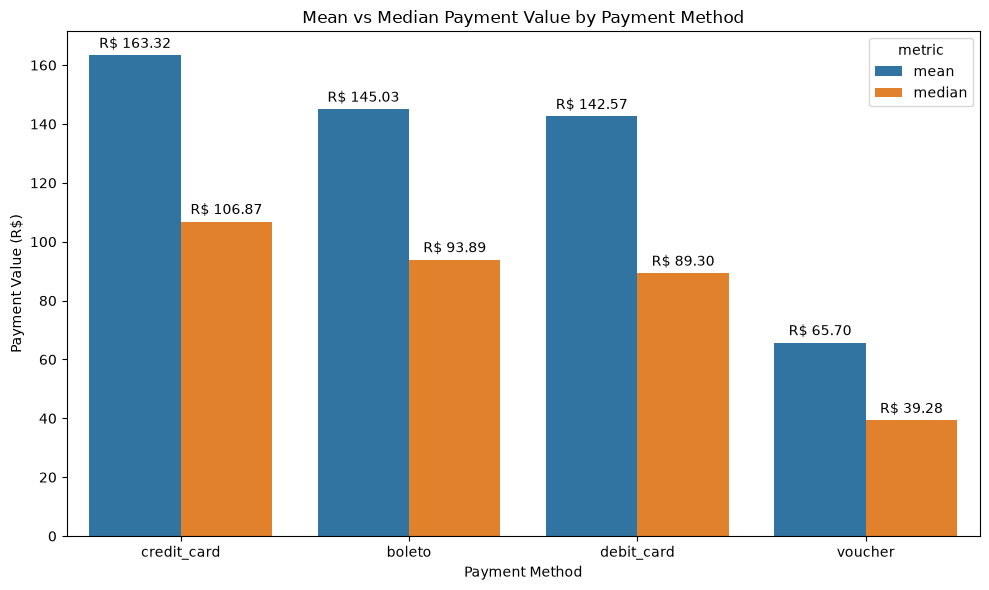

<Figure size 640x480 with 0 Axes>

In [104]:
average_payment_value_plot = (
    average_payment_value
    .reset_index()
    .melt(
        id_vars="payment_type",
        value_vars=["mean", "median"],
        var_name="metric",
        value_name="payment_value"
    )
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=average_payment_value_plot,
    x="payment_type",
    y="payment_value",
    hue="metric"
)

plt.title("Mean vs Median Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Payment Value (R$)")

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="R$ %.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

- **Credit card** has the highest mean payment value at **R$163.32**, with a median of **R$106.87**.
- **Boleto** has the second-highest mean at **R$145.03**, with a median of **R$93.89**.
- **Debit card** has a similar mean value of **R$142.57**, with a median of **R$89.30**.
- **Voucher** has substantially lower values, with a mean of **R$65.70** and a median of **R$39.28**.
- For every payment method, the **mean is higher than the median**, confirming the presence of right-skewed payment value distributions.

### 4.8.5 Installment Analysis

Installment payments are an important characteristic of credit card transactions in the Olist marketplace.

This analysis focuses on **credit card payments** to examine how customers typically distribute their purchases across installments.

The objective is to identify the most common installment plans and determine whether customers tend to pay in a single installment or use longer payment plans.

In [105]:
credit_card_payments = payments[
    payments["payment_type"] == "credit_card"
].copy()

installment_distribution = (
    credit_card_payments["payment_installments"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename("percentage")
)

installment_distribution

payment_installments
1     33.149294
2     16.163813
3     13.621981
4      9.242789
5      6.822059
6      5.104499
7      2.117325
8      5.557653
9      0.838596
10     6.937952
11     0.029950
12     0.173188
13     0.020835
14     0.019533
15     0.096360
16     0.006511
17     0.010417
18     0.035159
20     0.022137
21     0.003907
22     0.001302
23     0.001302
24     0.023439
Name: percentage, dtype: float64

#### Credit Card Installment Distribution

The distribution below shows the percentage of credit card transactions made with each number of installments.

This visualization helps identify the most common installment plans and highlights the extent to which customers rely on installment payments.

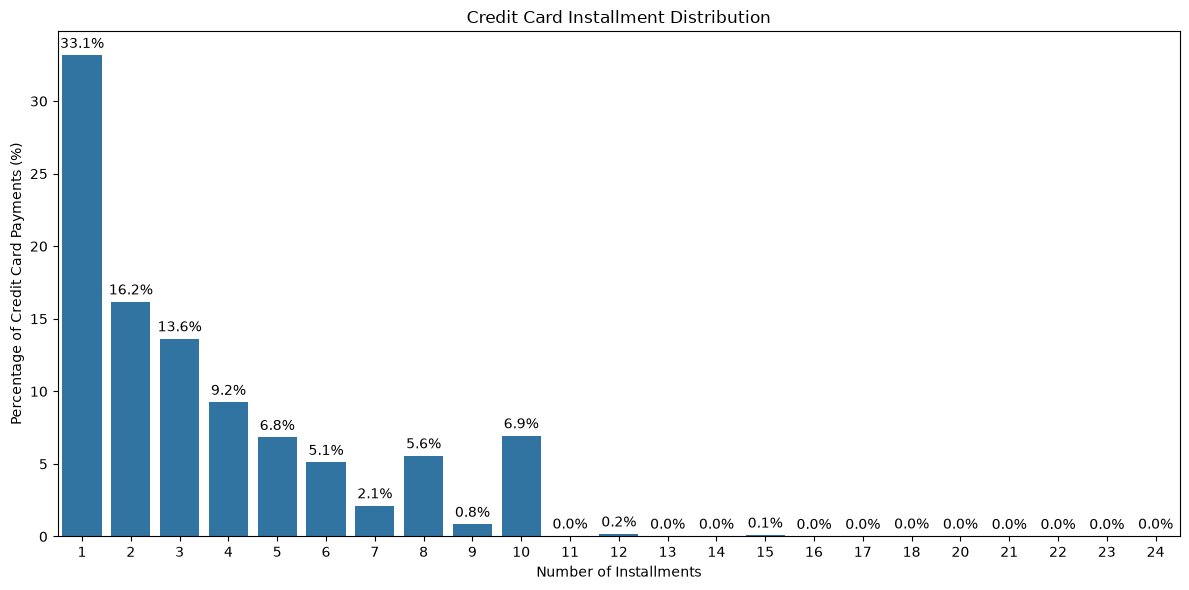

In [106]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=installment_distribution.index,
    y=installment_distribution.values
)

plt.title("Credit Card Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Percentage of Credit Card Payments (%)")

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
plt.show()

### 4.8.5.1 Typical Installment Behavior

The installment distribution shows that customers tend to favor **shorter payment plans**.

Single-payment transactions are the most common option, representing **33.15%** of credit card payments.

Two and three installments are also frequently used, accounting for **16.16%** and **13.62%** of transactions, respectively.

The use of four to six installments gradually decreases, while longer installment plans are considerably less common.

An exception is the **10-installment plan**, which accounts for **6.94%** of credit card payments and represents a noticeable share compared with other longer-term options.

In [107]:
top_3_installments_share = installment_distribution.loc[
    [1, 2, 3]
].sum()

top_3_installments_share

np.float64(62.935086919721336)

The most common installment plans are concentrated among **1, 2, and 3 installments**.

Together, these three options account for approximately **62.93%** of credit card payment transactions.

This indicates that the majority of customers either pay in a single installment or choose relatively short installment plans.

 **Customers predominantly prefer short installment plans, with 62.93% of credit card payments made in one, two, or three installments.**

Single-payment transactions are the most common behavior, while longer installment plans represent a smaller portion of transactions.

However, the presence of a meaningful share of **10-installment payments (6.94%)** suggests that longer financing remains relevant for a subset of customers.

### 4.8.6 Key Insights

The payment and order value analysis revealed several important patterns in customer purchasing behavior.

- **Credit card is the dominant payment method**, accounting for **78.34% of the total payment value** and representing the largest share of payment transactions.

- **Boleto is the second most important payment method**, contributing **17.92% of the total payment value**.

- **Credit card payments have the highest average payment value**, at **R$163.32**, compared with **R$145.03** for boleto, **R$142.57** for debit card, and **R$65.70** for voucher.

- Payment values are **right-skewed**, with a median payment value of **R$100.00** compared with a mean of **R$154.10**. This indicates that a relatively small number of higher-value transactions increase the overall average.

- The **75th percentile is R$171.84**, showing that most payment transactions are concentrated within a relatively low-value range.

- Only **0.21% of payment records exceed R$2,000**, but these high-value payments account for **3.64% of total payment value**. This indicates that extreme transactions are rare but still have a measurable financial impact.

- **Short installment plans are the most common among credit card payments**. Payments made in **1, 2, or 3 installments account for approximately 62.93%** of credit card transactions.

- Single-payment transactions are the most common installment behavior, representing **33.15%** of credit card payments.

- Longer installment plans are less common overall, although **10-installment payments account for 6.94%** of credit card transactions and remain relevant for a smaller group of customers.

#### Overall Business Insight

> **The payment analysis shows that customer transactions are strongly concentrated around credit cards, lower-value purchases, and shorter installment plans.**

Credit cards are the most financially significant payment method, combining the highest transaction volume with the highest average payment value.

Although most transactions are relatively small, a small proportion of high-value payments contributes disproportionately to total payment value. This highlights the importance of considering both typical transactions and extreme values when evaluating the platform's payment performance.

The strong preference for one to three installments also suggests that customers generally favor shorter payment periods, while longer installment plans serve a smaller but still relevant segment of customers.

### 4.9.1 Customer Distribution by State

The geographic distribution of customers provides insight into the regional reach of the Olist marketplace.

This analysis examines the number and percentage of customers in each Brazilian state to identify the regions with the highest concentration of customers.

Understanding customer concentration by state can help identify the platform's strongest geographic markets and potential opportunities for regional expansion.

In [108]:
customer_state_distribution = (
    customers["customer_state"]
    .value_counts()
    .reset_index()
)

customer_state_distribution.columns = [
    "customer_state",
    "customer_count"
]

customer_state_distribution["percentage"] = (
    customer_state_distribution["customer_count"]
    / customer_state_distribution["customer_count"].sum()
    * 100
)

customer_state_distribution

,customer_state,customer_count,percentage
0,SP,41746,41.980672
1,RJ,12852,12.924247
2,MG,11635,11.700405
3,RS,5466,5.496727
4,PR,5045,5.073360
5,SC,3637,3.657445
6,BA,3380,3.399000
7,DF,2140,2.152030
8,ES,2033,2.044428
9,GO,2020,2.031355


#### Customer Distribution by State

The table above shows the number of customers and their percentage of the total customer base for each Brazilian state.

The distribution can be used to identify the states that represent the largest customer markets and assess whether the marketplace is geographically concentrated in a small number of regions.

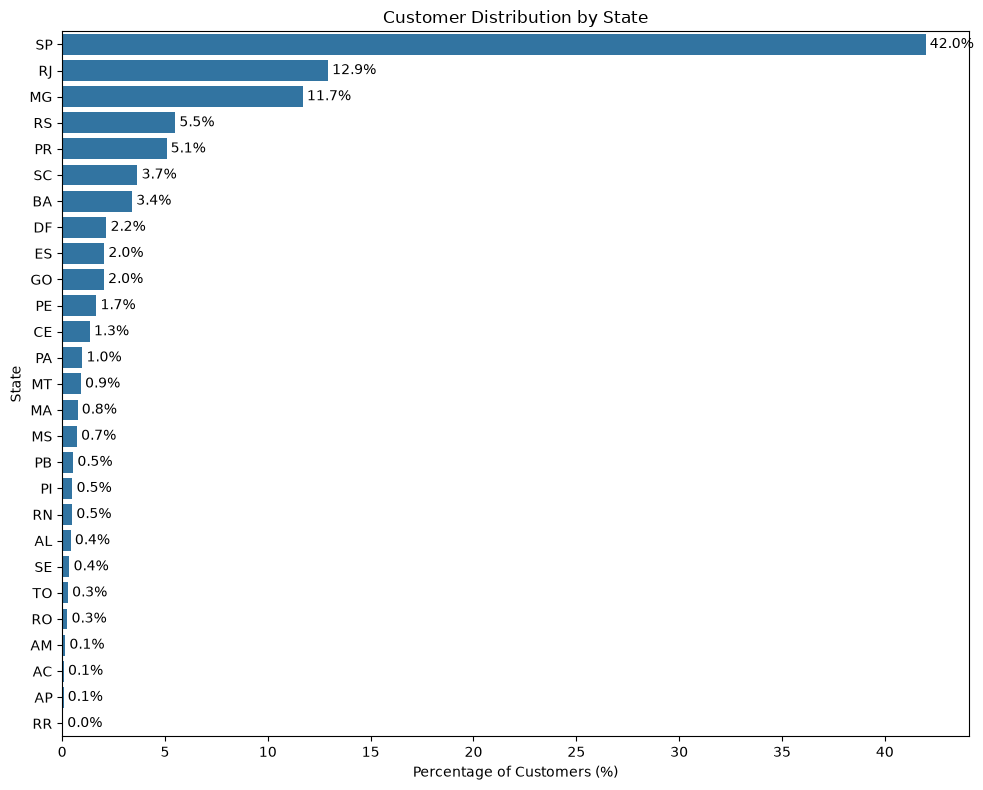

In [109]:
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=customer_state_distribution,
    y="customer_state",
    x="percentage",
    order=customer_state_distribution["customer_state"]
)

plt.title("Customer Distribution by State")
plt.xlabel("Percentage of Customers (%)")
plt.ylabel("State")

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
plt.show()

In [110]:
top_3_states_share = (
    customer_state_distribution
    .head(3)["percentage"]
    .sum()
)

top_3_states_share

np.float64(66.60532375981738)

The customer base is highly concentrated in a small number of Brazilian states.

- **São Paulo (SP)** is the largest customer market, with **41,746 customers**, representing **41.98%** of the total customer base.
- **Rio de Janeiro (RJ)** is the second-largest market, accounting for **12.92%** of customers.
- **Minas Gerais (MG)** represents another **11.70%** of the customer base.
- Together, **SP, RJ, and MG account for 66.61% of all customers**, meaning that approximately two-thirds of the customer base is concentrated in just three states.
- The **South region** also has a significant presence, particularly through **RS (5.50%)**, **PR (5.07%)**, and **SC (3.66%)**.
- States in the North and some parts of the Northeast represent considerably smaller shares of the customer base.

#### Business Insight

> **The Olist customer base is strongly concentrated geographically, with 66.61% of customers located in São Paulo, Rio de Janeiro, and Minas Gerais.**

São Paulo alone accounts for nearly **42% of the entire customer base**, making it by far the platform's most important geographic market.

This concentration may have important implications for **logistics, delivery performance, seller coverage, and regional marketing strategies**. It also provides a useful baseline for comparing customer distribution with geographic sales and delivery performance in the following analyses.

### 4.9.2 Customer Distribution by City

While state-level analysis shows broad geographic concentration, city-level analysis provides a more detailed view of where customers are located.

The analysis focuses on the **top cities by customer count** to identify the most important urban markets within the Olist customer base.

Only the top cities are visualized to maintain readability and highlight the locations with the greatest concentration of customers.

In [111]:
customer_city_distribution = (
    customers["customer_city"]
    .value_counts()
    .reset_index()
)

customer_city_distribution.columns = [
    "customer_city",
    "customer_count"
]

customer_city_distribution["percentage"] = (
    customer_city_distribution["customer_count"]
    / customer_city_distribution["customer_count"].sum()
    * 100
)

customer_city_distribution.head(15)

,customer_city,customer_count,percentage
0,sao paulo,15540,15.627357
1,rio de janeiro,6882,6.920687
2,belo horizonte,2773,2.788588
3,brasilia,2131,2.142979
4,curitiba,1521,1.529550
5,campinas,1444,1.452117
6,porto alegre,1379,1.386752
7,salvador,1245,1.251999
8,guarulhos,1189,1.195684
9,sao bernardo do campo,938,0.943273


The city-level distribution shows a strong concentration of customers in Brazil's largest metropolitan areas.

- **São Paulo** is the largest customer market, with **15,540 customers**, representing **15.63%** of the total customer base.
- **Rio de Janeiro** is the second-largest market, with **6,882 customers (6.92%)**.
- **Belo Horizonte** ranks third, accounting for **2.79%** of customers.
- **Brasília** represents **2.14%** of the customer base.
- Other major cities such as **Curitiba, Campinas, Porto Alegre, and Salvador** also have significant customer populations.
- The top cities are primarily concentrated in the **Southeast and South**, consistent with the state-level distribution observed previously.

#### Top 10 Customer Cities

The following visualization highlights the **10 cities with the largest customer populations**.

A top-10 view is used instead of displaying all cities to maintain readability and focus on the marketplace's largest urban markets.

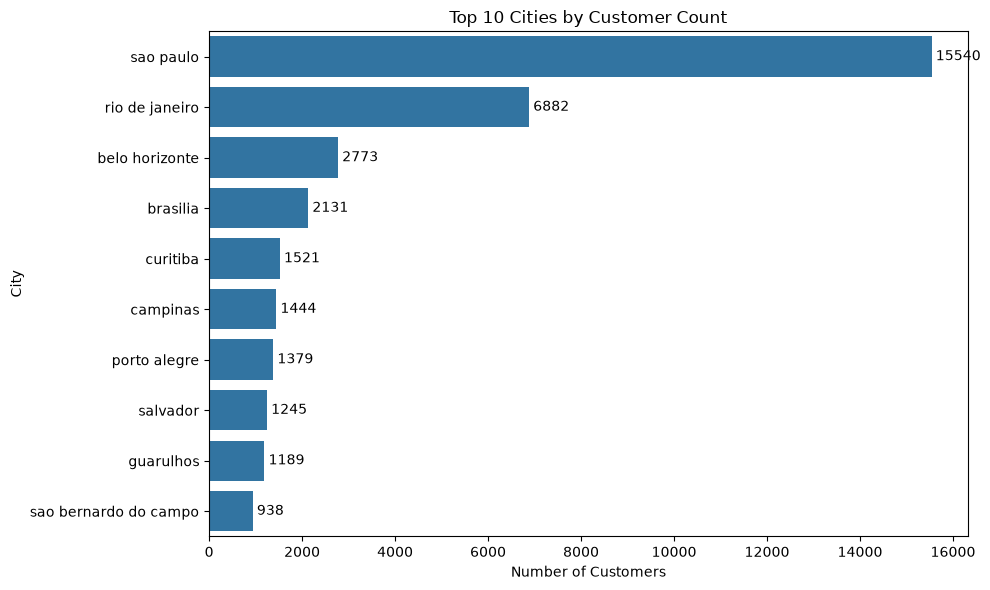

In [112]:
top_10_cities = customer_city_distribution.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_cities,
    y="customer_city",
    x="customer_count"
)

plt.title("Top 10 Cities by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("City")

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

plt.tight_layout()
plt.show()

In [113]:
top_2_cities_share = (
    customer_city_distribution
    .head(2)["percentage"]
    .sum()
)

top_2_cities_share

np.float64(22.54804356352008)

#### Business Insight

> **Customer activity is strongly concentrated in major metropolitan areas, with São Paulo and Rio de Janeiro alone accounting for 22.55% of the entire customer base.**

The concentration of customers in large urban centers suggests that metropolitan markets are particularly important to the Olist marketplace.

This geographic concentration may also influence **delivery performance, logistics costs, seller availability, and regional sales patterns**, making geographic analysis an important component of the overall business evaluation.

### 4.9.3 Geographic Sales Distribution

Customer concentration does not necessarily indicate where the largest share of revenue is generated.

To evaluate geographic sales performance, payment values are aggregated by the customer's state.

This analysis identifies the states generating the highest total payment value and allows comparison between customer concentration and financial contribution.

In [114]:
orders_customers = (
    orders[
        ["order_id", "customer_id"]
    ]
    .merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
)

In [115]:
geographic_sales = (
    orders_customers[
        ["order_id", "customer_state"]
    ]
    .merge(
        payments[
            ["order_id", "payment_value"]
        ],
        on="order_id",
        how="left"
    )
)

geographic_sales_distribution = (
    geographic_sales
    .groupby("customer_state")["payment_value"]
    .sum()
    .reset_index()
    .sort_values("payment_value", ascending=False)
)

geographic_sales_distribution["percentage"] = (
    geographic_sales_distribution["payment_value"]
    / geographic_sales_distribution["payment_value"].sum()
    * 100
)

geographic_sales_distribution

,customer_state,payment_value,percentage
25,SP,5998226.96,37.468142
18,RJ,2144379.69,13.394945
10,MG,1872257.26,11.695123
22,RS,890898.54,5.565030
17,PR,811156.38,5.066918
23,SC,623086.43,3.892132
4,BA,616645.82,3.851900
6,DF,355141.08,2.218402
8,GO,350092.31,2.186864
7,ES,325967.55,2.036168


In [116]:
top_3_sales_share = (
    geographic_sales_distribution
    .head(3)["percentage"]
    .sum()
)

top_3_sales_share

np.float64(62.55821044062409)

The distribution of payment value is highly concentrated in the same major states that account for most of the customer base.

- **São Paulo** generates the highest total payment value at approximately **R$6.00 million**, representing **37.47%** of the total payment value.
- **Rio de Janeiro** contributes approximately **R$2.14 million**, representing **13.39%** of total payment value.
- **Minas Gerais** contributes approximately **R$1.87 million**, accounting for **11.70%**.
- Together, **SP, RJ, and MG generate approximately 62.56% of total payment value**.
- The Southern states also contribute significantly, particularly **RS (5.57%)**, **PR (5.07%)**, and **SC (3.89%)**.
- The overall geographic distribution of payment value broadly follows the customer distribution, although some states show differences between their customer share and financial contribution.

#### Top 10 States by Payment Value

The following visualization highlights the **10 states generating the largest total payment value**.

A top-10 view is used to maintain readability while focusing on the marketplace's most financially significant geographic markets.

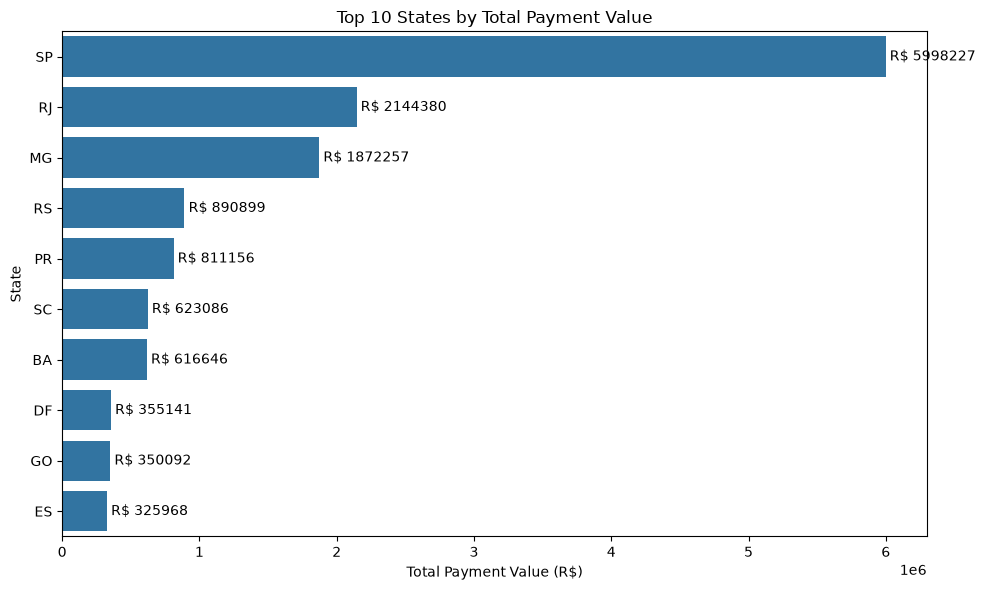

In [117]:
top_10_sales_states = geographic_sales_distribution.head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_sales_states,
    y="customer_state",
    x="payment_value"
)

plt.title("Top 10 States by Total Payment Value")
plt.xlabel("Total Payment Value (R$)")
plt.ylabel("State")

ax.bar_label(
    ax.containers[0],
    fmt="R$ %.0f",
    padding=3
)

plt.tight_layout()
plt.show()

#### Business Insight

> **The geographic distribution of payment value closely follows customer concentration, but São Paulo contributes a smaller share of payment value than its share of customers.**

São Paulo represents **41.98% of customers** but only **37.47% of total payment value**. This indicates that its financial contribution is somewhat lower than would be expected based solely on its customer share.

In contrast, Rio de Janeiro represents **12.92% of customers** while contributing **13.39% of payment value**, suggesting a slightly higher financial contribution relative to its customer base.

These differences demonstrate that **customer concentration alone does not fully explain geographic financial performance**.

### 4.9.5 Average Payment Value by State

Total payment value is strongly influenced by the number of customers in each state. To compare the financial contribution of different regions more fairly, the average payment value per order is analyzed.

This metric helps identify states where individual transactions tend to have higher or lower monetary values, regardless of the state's overall customer population.

In [118]:
state_payment_analysis = (
    geographic_sales
    .groupby("customer_state")
    .agg(
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

state_payment_analysis["percentage_of_total_value"] = (
    state_payment_analysis["total_payment_value"]
    / state_payment_analysis["total_payment_value"].sum()
    * 100
)

state_payment_analysis = state_payment_analysis.sort_values(
    "average_payment_value",
    ascending=False
)

state_payment_analysis

,customer_state,total_payment_value,average_payment_value,order_count,percentage_of_total_value
14,PB,141545.72,248.325825,536,0.884170
0,AC,19680.62,234.293095,81,0.122936
20,RO,60866.20,233.203831,253,0.380203
3,AP,16262.80,232.325714,68,0.101586
1,AL,96962.06,227.077424,413,0.605677
21,RR,10064.62,218.796087,46,0.062869
13,PA,218295.85,215.920722,975,1.363593
24,SE,75246.25,208.438366,350,0.470028
16,PI,108523.97,207.106813,495,0.677899
26,TO,61485.33,204.270199,280,0.384070


The average payment value varies considerably across Brazilian states, revealing differences that are not visible when considering total payment value alone.

- **Paraíba (PB)** has the highest average payment value at **R$248.33 per order**, despite having only **536 orders**.
- **Acre (AC)**, **Rondônia (RO)**, and **Amapá (AP)** also show relatively high average payment values, exceeding **R$230 per order**.
- **São Paulo (SP)** has the lowest average payment value among the states, at **R$137.51 per order**, despite generating the highest total payment value.
- **Rio de Janeiro (RJ)** has an average payment value of **R$158.53**, while **Minas Gerais (MG)** has an average of **R$154.71**.
- The results demonstrate that states with smaller customer bases can have substantially higher average transaction values.

#### Average Payment Value by Top 10 State

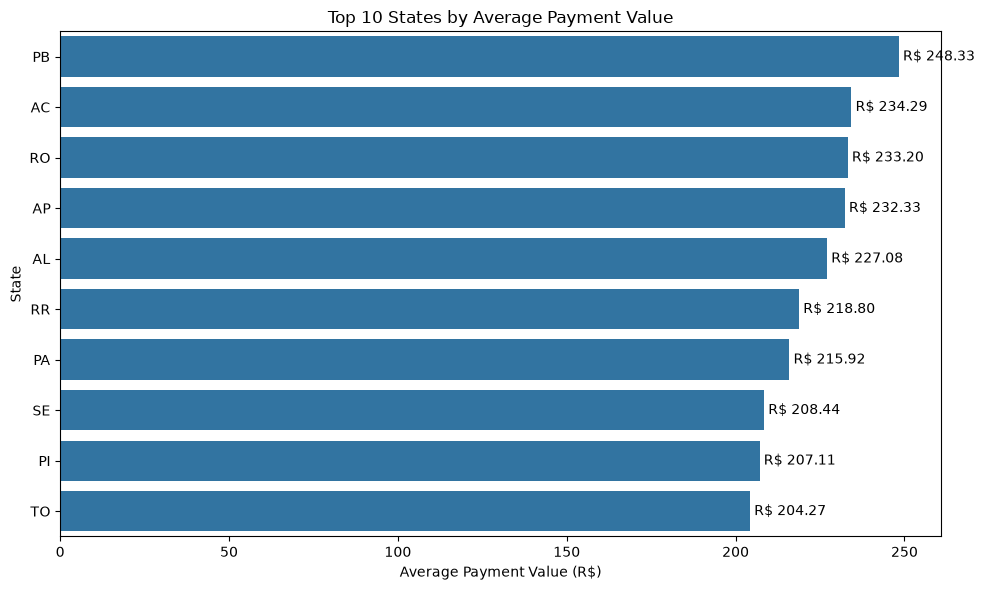

In [119]:
top_10_avg_states = (
    state_payment_analysis
    .head(10)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_avg_states,
    y="customer_state",
    x="average_payment_value"
)

plt.title("Top 10 States by Average Payment Value")
plt.xlabel("Average Payment Value (R$)")
plt.ylabel("State")

ax.bar_label(
    ax.containers[0],
    fmt="R$ %.2f",
    padding=3
)

plt.tight_layout()
plt.show()

**Geographic market size and average transaction value tell different stories.**

São Paulo is by far the largest market in terms of total payment value, but its average payment value is the lowest among the states analyzed.

In contrast, smaller markets such as Paraíba, Acre, Rondônia, and Amapá show substantially higher average payment values.

This suggests that **market size should not be evaluated solely by customer or order volume**. Smaller geographic markets may generate fewer transactions while still having relatively high-value purchases.

However, these smaller states also have substantially fewer orders, so their higher averages should be interpreted with caution and considered together with transaction volume.

#### Geographic Analysis Conclusion

The geographic analysis reveals a highly concentrated customer and payment structure.

São Paulo, Rio de Janeiro, and Minas Gerais account for **66.61% of the customer base** and approximately **62.56% of total payment value**.

At the same time, average payment value varies considerably across states. This demonstrates that geographic importance can be evaluated from multiple perspectives, including **customer volume, total payment value, and average transaction value**.

### 4.9.6 Key Insights

The geographic analysis revealed several important patterns in the Olist marketplace:

- **São Paulo is the dominant geographic market**, representing **41.98% of customers** and **37.47% of total payment value**.
- **São Paulo, Rio de Janeiro, and Minas Gerais together account for 66.61% of customers** and approximately **62.56% of total payment value**.
- Customer activity is concentrated primarily in major metropolitan areas, with **São Paulo and Rio de Janeiro alone representing 22.55% of the customer base**.
- The geographic distribution of customers and orders is identical in this dataset because each customer is associated with a single order.
- **Total payment value is strongly influenced by market size**, with São Paulo generating approximately **R$6.00 million** in payment value.
- **Average payment value tells a different story**: smaller states such as Paraíba and Acre have substantially higher average values per order than São Paulo.
- Geographic market size therefore does not necessarily correspond to higher individual transaction value.

Overall, the results indicate that Olist's business is **strongly concentrated in Brazil's largest markets**, while smaller states can still exhibit relatively high-value transactions.

## 4.10 Product & Category Performance Analysis

This section analyzes the product catalog and category performance of the Olist marketplace.

The analysis focuses on product distribution, sales performance, pricing patterns, and the relationship between product categories and customer review scores.

The main objectives are to:

- Understand the distribution of products across categories.
- Identify the categories with the highest sales.
- Compare average product prices across categories.
- Identify the top-performing product categories.
- Examine whether category performance is associated with customer review scores.

### 4.10.1 Product Category Distribution

This analysis examines how the Olist product catalog is distributed across different product categories.

The number and percentage of products in each category will be analyzed to identify the largest and smallest product segments within the marketplace.

In [122]:
category_distribution = (
    products['product_category_name']
    .value_counts()
    .rename_axis('product_category_name')
    .reset_index(name='product_count')
)

category_distribution['percentage'] = (
    category_distribution['product_count']
    / category_distribution['product_count'].sum()
    * 100
)

category_distribution.head(10)

,product_category_name,product_count,percentage
0,cama_mesa_banho,3029,9.365820
1,esporte_lazer,2867,8.864908
2,moveis_decoracao,2657,8.215578
3,beleza_saude,2444,7.556971
4,utilidades_domesticas,2335,7.219938
5,automotivo,1900,5.874896
6,informatica_acessorios,1639,5.067871
7,brinquedos,1411,4.362883
8,relogios_presentes,1329,4.109335
9,telefonia,1134,3.506385


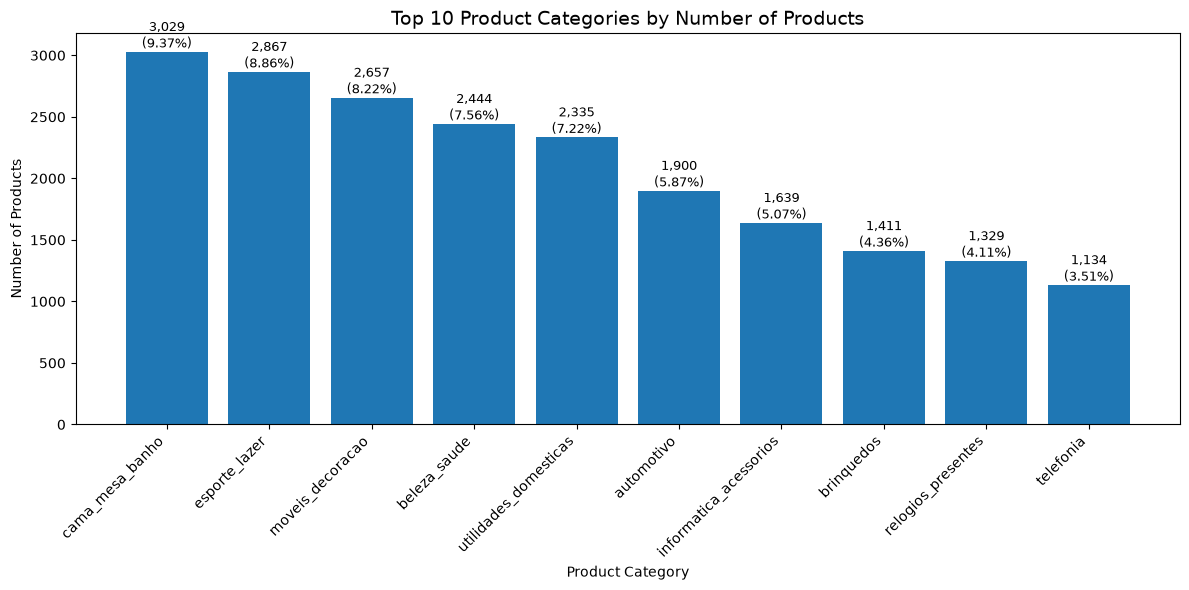

In [130]:
top_10_categories = category_distribution.head(10).copy()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    top_10_categories['product_category_name'],
    top_10_categories['product_count']
)

plt.title('Top 10 Product Categories by Number of Products', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')

# Add values and percentages to each bar
for bar, count, percentage in zip(
    bars,
    top_10_categories['product_count'],
    top_10_categories['percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}\n({percentage:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Distribution of Product Categories

The Olist product catalog contains 73 different product categories. The distribution is relatively concentrated among the largest categories.

The `cama_mesa_banho` category has the largest number of products, with 3,029 products, representing 9.37% of the catalog. It is followed by `esporte_lazer` with 2,867 products (8.86%) and `moveis_decoracao` with 2,657 products (8.22%).

Other major categories include `beleza_saude` (7.56%), `utilidades_domesticas` (7.22%), and `automotivo` (5.87%).

In [131]:
top_5_share = category_distribution.head(5)['percentage'].sum()
top_10_share = category_distribution.head(10)['percentage'].sum()

print(f"Top 5 categories: {top_5_share:.2f}% of all products")
print(f"Top 10 categories: {top_10_share:.2f}% of all products")

Top 5 categories: 41.22% of all products
Top 10 categories: 64.14% of all products


- The Olist marketplace contains 73 different product categories.
- `cama_mesa_banho` is the largest category, with 3,029 products, representing 9.37% of the total catalog.
- `esporte_lazer` is the second-largest category, with 2,867 products (8.86%).
- `moveis_decoracao` ranks third, with 2,657 products (8.22%).
- The five largest categories account for 41.22% of all products.
- The ten largest categories account for 64.14% of the product catalog.

The product catalog is relatively concentrated among a limited number of categories. The top 10 categories account for nearly two-thirds of all products, indicating that a significant portion of the marketplace assortment is concentrated in these segments.

This concentration can help guide further analysis of sales performance. Categories with a large product assortment may generate substantial sales simply because they contain more products, while smaller categories may have stronger performance on a per-product basis.

Therefore, product count alone should not be interpreted as category success. The next analysis will compare product categories based on their actual sales performance.

### 4.10.2 Sales by Product Category

This analysis examines the sales performance of each product category by combining product information with order item data.

The `items` dataset contains the price of each item sold, while the `products` dataset provides the corresponding product category. By combining these datasets, we can calculate the total sales generated by each category and compare their relative contribution to the marketplace.

The `items` dataset contains the transaction-level price information, while the `products` dataset contains the category assigned to each product.

The two datasets will be joined using `product_id` so that each order item can be associated with its corresponding product category.
Code — Merge Product and Category Information

In [135]:
items_category = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

items_category[['product_id', 'product_category_name', 'price']].head()

,product_id,product_category_name,price
0,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90
1,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90
2,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,199.00
3,7634da152a4610f1595efa32f14722fc,perfumaria,12.99
4,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,199.90


#### Checking for Missing Product Categories

Before calculating category-level sales, we check whether any order items could not be matched to a product category.

This ensures that the sales analysis is based on complete category information and allows us to quantify any missing category assignments.

In [136]:
missing_categories = items_category['product_category_name'].isna().sum()

missing_percentage = (
    missing_categories / len(items_category) * 100
)

print(f"Order items without a product category: {missing_categories:,}")
print(f"Percentage of order items without a category: {missing_percentage:.2f}%")

Order items without a product category: 1,603
Percentage of order items without a category: 1.42%


After joining the order items with the product catalog, 1,603 order items (1.42% of all order items) could not be associated with a product category.

Before calculating category-level sales, we assess the sales value associated with these items to determine whether excluding them would have a material impact on the analysis.

In [137]:
missing_category_sales = items_category.loc[
    items_category['product_category_name'].isna(),
    'price'
].sum()

total_sales = items_category['price'].sum()

missing_sales_percentage = (
    missing_category_sales / total_sales * 100
)

print(f"Sales from items without a category: R${missing_category_sales:,.2f}")
print(f"Percentage of total sales: {missing_sales_percentage:.2f}%")

Sales from items without a category: R$179,535.28
Percentage of total sales: 1.32%


A total of 1,603 order items (1.42% of all order items) could not be associated with a product category after joining the datasets.

These items account for R$179,535.28 in sales, representing 1.32% of total item sales.

Since the missing-category items represent a relatively small share of total sales, they will be excluded from the category-level analysis. The impact of this exclusion is documented to maintain transparency.

In [138]:
category_sales = (
    items_category
    .dropna(subset=['product_category_name'])
    .groupby('product_category_name', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'total_sales'})
    .sort_values('total_sales', ascending=False)
)

category_sales['sales_percentage'] = (
    category_sales['total_sales']
    / category_sales['total_sales'].sum()
    * 100
)

category_sales.head(10)

,product_category_name,total_sales,sales_percentage
11,beleza_saude,1258681.34,9.384664
66,relogios_presentes,1205005.68,8.984461
13,cama_mesa_banho,1036988.68,7.731735
32,esporte_lazer,988048.97,7.366843
44,informatica_acessorios,911954.32,6.799485
54,moveis_decoracao,729762.49,5.441072
26,cool_stuff,635290.85,4.736696
72,utilidades_domesticas,632248.66,4.714014
8,automotivo,592720.11,4.419291
40,ferramentas_jardim,485256.46,3.618048


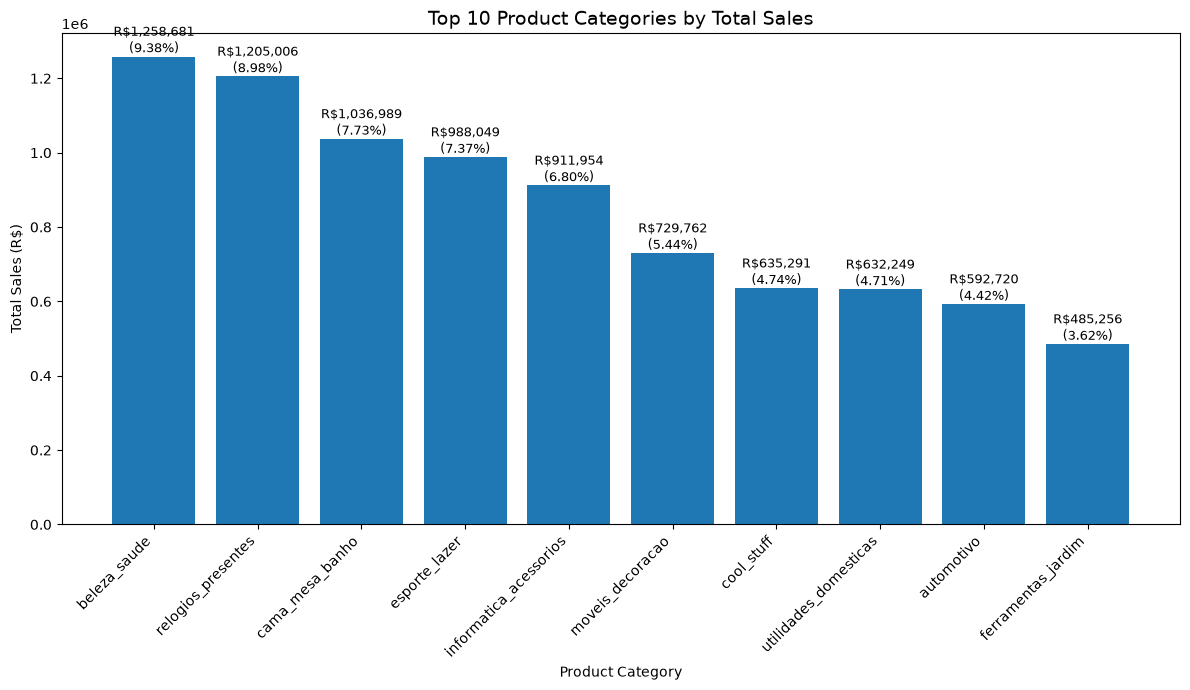

In [139]:
top_10_sales = category_sales.head(10).copy()

plt.figure(figsize=(12, 7))

bars = plt.bar(
    top_10_sales['product_category_name'],
    top_10_sales['total_sales']
)

plt.title('Top 10 Product Categories by Total Sales', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Total Sales (R$)')
plt.xticks(rotation=45, ha='right')

# Add sales value and percentage to each bar
for bar, sales, percentage in zip(
    bars,
    top_10_sales['total_sales'],
    top_10_sales['sales_percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'R${sales:,.0f}\n({percentage:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

The sales distribution differs from the product catalog distribution.

`beleza_saude` generates the highest total sales, with R$1.26 million, representing 9.38% of category-level sales. `relogios_presentes` follows closely with R$1.21 million (8.98%).

Interestingly, `cama_mesa_banho`, which was the largest category by number of products, ranks third in total sales with R$1.04 million (7.73%).

This indicates that a larger product assortment does not necessarily translate into higher total sales.

#### Sales Concentration Across Product Categories

To evaluate how concentrated category-level sales are, the cumulative share of sales generated by the top five and top ten categories is calculated.

Comparing these figures with the product catalog distribution helps determine whether sales are concentrated in the same categories that have the largest product assortments.

In [140]:
top_5_sales_share = category_sales.head(5)['sales_percentage'].sum()
top_10_sales_share = category_sales.head(10)['sales_percentage'].sum()

print(f"Top 5 categories: {top_5_sales_share:.2f}% of category-level sales")
print(f"Top 10 categories: {top_10_sales_share:.2f}% of category-level sales")

Top 5 categories: 40.27% of category-level sales
Top 10 categories: 63.20% of category-level sales


- `beleza_saude` generated the highest total sales, with R$1.26 million, representing 9.38% of category-level sales.
- `relogios_presentes` ranked second, generating R$1.21 million (8.98%).
- `cama_mesa_banho`, the largest category by product count, ranked third in total sales with R$1.04 million (7.73%).
- The top five categories accounted for 40.27% of category-level sales.
- The top ten categories accounted for 63.20% of category-level sales.
- The concentration of sales is similar to the concentration of the product catalog, where the top five categories represented 41.22% of products and the top ten represented 64.14%.

The results show that product assortment and total sales are relatively aligned at the category level. The top five categories account for 41.22% of the catalog and 40.27% of sales, while the top ten categories represent 64.14% of products and 63.20% of sales.

However, category size does not always translate directly into sales leadership. `cama_mesa_banho` has the largest product assortment but ranks third in total sales, while `beleza_saude` generates the highest sales despite having fewer products.

This suggests that product count alone is not sufficient to evaluate category performance. Sales efficiency, including factors such as average product price and sales volume per product, should also be considered.

The next analysis will examine average product prices across categories to provide additional context for these differences.

### 4.10.3 Average Product Price by Category

This analysis examines the average selling price of products across different product categories.

Comparing average prices helps explain differences in sales performance observed in the previous section. Categories with higher total sales may benefit from higher average selling prices, while categories with lower prices may depend more heavily on sales volume.

The analysis uses the `price` of items sold and groups the data by product category.

#### Calculating Average Product Price by Category

The average selling price is calculated for each product category using the transaction-level `price` recorded in the order items dataset.

Items without an associated product category are excluded, consistent with the treatment applied in the previous analysis.

In [141]:
category_avg_price = (
    items_category
    .dropna(subset=['product_category_name'])
    .groupby('product_category_name', as_index=False)['price']
    .mean()
    .rename(columns={'price': 'average_price'})
    .sort_values('average_price', ascending=False)
)

category_avg_price.head(10)

,product_category_name,average_price
61,pcs,1098.340542
64,portateis_casa_forno_e_cafe,624.285658
29,eletrodomesticos_2,476.124958
0,agro_industria_e_comercio,342.124858
45,instrumentos_musicais,281.616000
31,eletroportateis,280.778468
65,portateis_cozinha_e_preparadores_de_alimentos,264.568667
71,telefonia_fixa,225.693182
25,construcao_ferramentas_seguranca,208.992371
66,relogios_presentes,201.135984


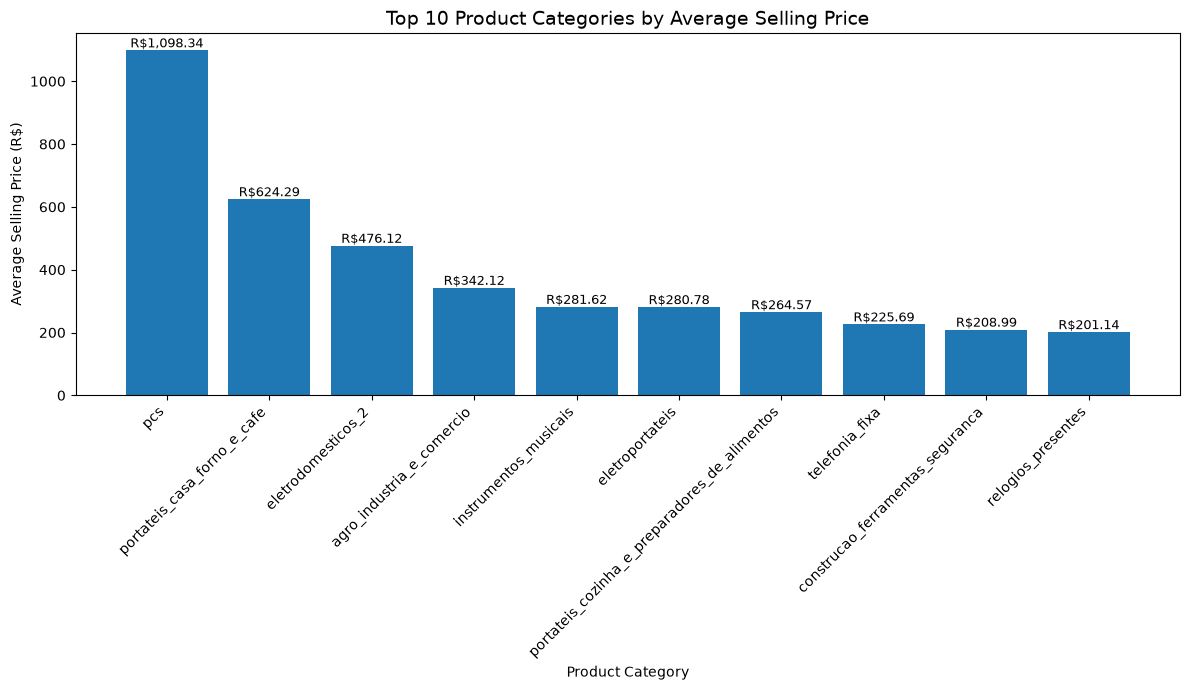

In [142]:
top_10_avg_price = category_avg_price.head(10).copy()

plt.figure(figsize=(12, 7))

bars = plt.bar(
    top_10_avg_price['product_category_name'],
    top_10_avg_price['average_price']
)

plt.title('Top 10 Product Categories by Average Selling Price', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Average Selling Price (R$)')
plt.xticks(rotation=45, ha='right')

# Add average price values to each bar
for bar, price in zip(
    bars,
    top_10_avg_price['average_price']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'R${price:,.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Average Selling Price by Category

The average selling price varies substantially across product categories.

`pcs` has the highest average selling price among the categories analyzed, at R$1,098.34 per item. It is followed by `portateis_casa_forno_e_cafe` at R$624.29 and `eletrodomesticos_2` at R$476.12.

In comparison, `relogios_presentes`, one of the top categories by total sales, has an average selling price of R$201.14.

This difference indicates that category sales performance can be influenced by different factors. Higher-priced categories can generate substantial sales value with fewer transactions, while lower-priced categories may require higher sales volume to achieve similar revenue.

#### Average Selling Price by Category

The average selling price varies substantially across product categories.

`pcs` has the highest average selling price among the categories analyzed, at R$1,098.34 per item. It is followed by `portateis_casa_forno_e_cafe` at R$624.29 and `eletrodomesticos_2` at R$476.12.

In comparison, `relogios_presentes`, one of the top categories by total sales, has an average selling price of R$201.14.

This difference indicates that category sales performance can be influenced by different factors. Higher-priced categories can generate substantial sales value with fewer transactions, while lower-priced categories may require higher sales volume to achieve similar revenue.

In [143]:
category_performance = category_sales.merge(
    category_avg_price,
    on='product_category_name',
    how='inner'
)

category_performance.sort_values(
    'total_sales',
    ascending=False
).head(10)

,product_category_name,total_sales,sales_percentage,average_price
0,beleza_saude,1258681.34,9.384664,130.163531
1,relogios_presentes,1205005.68,8.984461,201.135984
2,cama_mesa_banho,1036988.68,7.731735,93.296327
3,esporte_lazer,988048.97,7.366843,114.344285
4,informatica_acessorios,911954.32,6.799485,116.513903
5,moveis_decoracao,729762.49,5.441072,87.564494
6,cool_stuff,635290.85,4.736696,167.357969
7,utilidades_domesticas,632248.66,4.714014,90.788148
8,automotivo,592720.11,4.419291,139.957523
9,ferramentas_jardim,485256.46,3.618048,111.630196


#### Average Price vs. Total Sales

To examine the relationship between product pricing and sales performance, average selling price is compared with total sales across product categories.

A scatter plot is used because each point represents a product category, allowing us to identify whether categories with higher average prices tend to generate higher total sales.

This analysis helps distinguish between sales driven primarily by higher prices and sales driven by greater sales volume.

In [144]:
category_performance = category_sales.merge(
    category_avg_price,
    on='product_category_name',
    how='inner'
)

category_performance.sort_values(
    'total_sales',
    ascending=False
).head(10)

,product_category_name,total_sales,sales_percentage,average_price
0,beleza_saude,1258681.34,9.384664,130.163531
1,relogios_presentes,1205005.68,8.984461,201.135984
2,cama_mesa_banho,1036988.68,7.731735,93.296327
3,esporte_lazer,988048.97,7.366843,114.344285
4,informatica_acessorios,911954.32,6.799485,116.513903
5,moveis_decoracao,729762.49,5.441072,87.564494
6,cool_stuff,635290.85,4.736696,167.357969
7,utilidades_domesticas,632248.66,4.714014,90.788148
8,automotivo,592720.11,4.419291,139.957523
9,ferramentas_jardim,485256.46,3.618048,111.630196


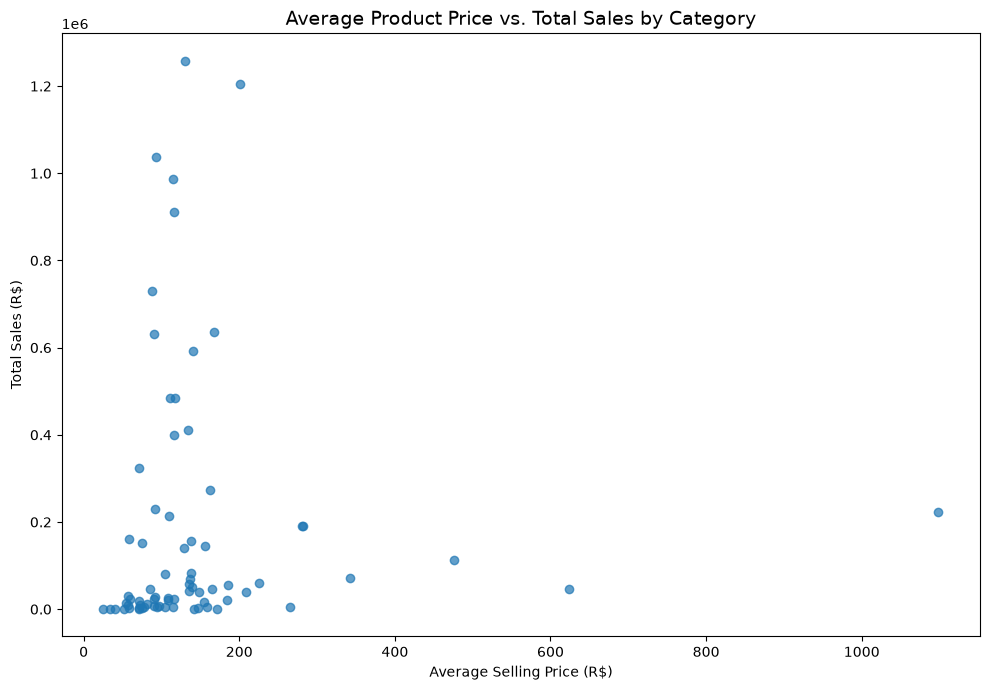

In [145]:
plt.figure(figsize=(10, 7))

plt.scatter(
    category_performance['average_price'],
    category_performance['total_sales'],
    alpha=0.7
)

plt.title('Average Product Price vs. Total Sales by Category', fontsize=14)
plt.xlabel('Average Selling Price (R$)')
plt.ylabel('Total Sales (R$)')

plt.tight_layout()
plt.show()

In [146]:
category_performance[['average_price', 'total_sales']].corr()

,average_price,total_sales
average_price,1.000000,0.020509
total_sales,0.020509,1.000000


#### Correlation Between Average Price and Total Sales

The correlation between average selling price and total sales is approximately 0.02.

This indicates an almost negligible linear relationship between the two variables. In this dataset, categories with higher average selling prices do not consistently generate higher total sales.

Therefore, average product price alone does not appear to be a meaningful predictor of category-level sales performance.

The near-zero correlation suggests that category sales performance is not primarily determined by average product price.

For example, some categories with relatively moderate average prices generate very high total sales, while some categories with substantially higher average prices do not rank among the strongest categories by total sales.

This suggests that sales volume is likely an important factor behind category-level sales. A category can generate high total sales through a large number of transactions even when its average selling price is relatively low.

From a business perspective, increasing the average product price alone may not necessarily lead to higher category sales.

The results suggest that category performance should be evaluated using multiple dimensions, including:

- Total sales
- Average selling price
- Number of items sold
- Product assortment

This multidimensional approach provides a more reliable view of category performance than relying on price alone.

#### Sales Volume by Product Category

To better understand the factors driving category-level sales, the number of items sold by category is calculated.

Since total sales are influenced by both selling price and sales volume, comparing the number of items sold with total sales can help determine whether high-performing categories are primarily driven by transaction volume.

In [147]:
category_volume = (
    items_category
    .dropna(subset=['product_category_name'])
    .groupby('product_category_name')
    .size()
    .reset_index(name='items_sold')
)

category_performance = category_performance.merge(
    category_volume,
    on='product_category_name',
    how='left'
)

category_performance.sort_values(
    'total_sales',
    ascending=False
).head(10)

,product_category_name,total_sales,sales_percentage,average_price,items_sold
0,beleza_saude,1258681.34,9.384664,130.163531,9670
1,relogios_presentes,1205005.68,8.984461,201.135984,5991
2,cama_mesa_banho,1036988.68,7.731735,93.296327,11115
3,esporte_lazer,988048.97,7.366843,114.344285,8641
4,informatica_acessorios,911954.32,6.799485,116.513903,7827
5,moveis_decoracao,729762.49,5.441072,87.564494,8334
6,cool_stuff,635290.85,4.736696,167.357969,3796
7,utilidades_domesticas,632248.66,4.714014,90.788148,6964
8,automotivo,592720.11,4.419291,139.957523,4235
9,ferramentas_jardim,485256.46,3.618048,111.630196,4347


#### Sales Volume vs. Total Sales

To determine whether sales volume is more closely associated with total sales than average selling price, the correlation between the number of items sold and total sales is calculated.

This comparison helps identify whether category revenue is primarily driven by higher prices or by a larger number of transactions.

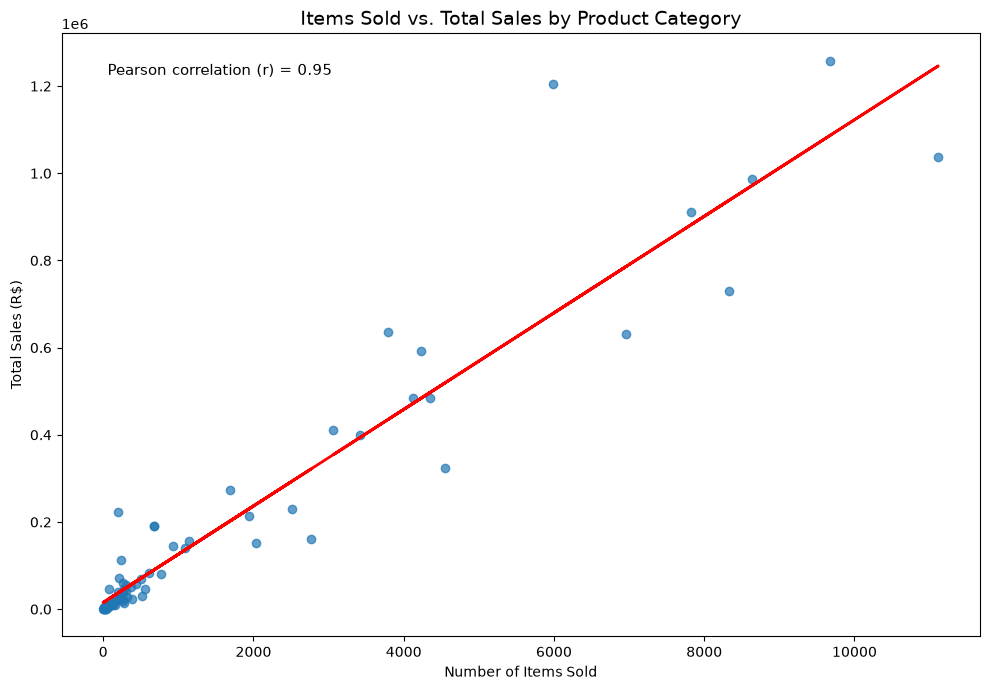

In [151]:
plt.figure(figsize=(10, 7))

plt.scatter(
    x,
    y,
    alpha=0.7
)

plt.plot(
    x,
    trend_line,
    color='red',
    linewidth=2
)

plt.title(
    'Items Sold vs. Total Sales by Product Category',
    fontsize=14
)

plt.xlabel('Number of Items Sold')
plt.ylabel('Total Sales (R$)')

plt.text(
    0.05,
    0.95,
    f'Pearson correlation (r) = {correlation:.2f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top'
)

plt.tight_layout()
plt.show()

- The correlation between average selling price and total sales is only **0.02**, indicating an almost negligible linear relationship.
- The correlation between items sold and total sales is **0.95**, indicating a very strong positive relationship.
- `relogios_presentes` generated R$1.21 million in sales with an average selling price of R$201.14 and 5,991 items sold.
- `cama_mesa_banho` generated R$1.04 million in sales despite having a relatively low average selling price of R$93.30, supported by 11,115 items sold.
- These results indicate that high category sales are more strongly associated with sales volume than with average product price.

The analysis suggests that sales volume is a much stronger driver of category-level sales than average selling price.

Categories with relatively low-priced products can achieve high sales when they generate sufficient transaction volume. Therefore, focusing exclusively on higher-priced products may not be an effective strategy for maximizing category sales.

From a business perspective, strategies that increase demand and transaction volume, such as improving product visibility, assortment, promotions, and customer reach, may have a greater impact on total sales than simply increasing average prices.

It is important to note that correlation does not imply causation. In addition, total sales are inherently related to both price and sales volume. Therefore, these correlations should be interpreted as descriptive evidence of the patterns observed across product categories rather than as causal effects.

### 4.10.4 Top Product Categories

This section evaluates the strongest-performing product categories using multiple performance indicators.

Rather than ranking categories only by total sales, the analysis considers total sales, sales volume, and average selling price to provide a broader view of category performance.

This approach helps distinguish categories that perform well because of high transaction volume from those that generate substantial sales through higher-priced products.

#### Comparing Category Performance Metrics

The category performance dataset combines the main metrics calculated throughout the previous analyses.

These metrics include:

- Total sales
- Sales contribution
- Number of items sold
- Average selling price

The categories will first be ranked by total sales to establish the overall sales leaders, while the additional metrics provide context for their performance.

In [152]:
top_categories = (
    category_performance
    .sort_values('total_sales', ascending=False)
    .head(10)
    [['product_category_name',
      'total_sales',
      'sales_percentage',
      'items_sold',
      'average_price']]
    .copy()
)

top_categories

,product_category_name,total_sales,sales_percentage,items_sold,average_price
0,beleza_saude,1258681.34,9.384664,9670,130.163531
1,relogios_presentes,1205005.68,8.984461,5991,201.135984
2,cama_mesa_banho,1036988.68,7.731735,11115,93.296327
3,esporte_lazer,988048.97,7.366843,8641,114.344285
4,informatica_acessorios,911954.32,6.799485,7827,116.513903
5,moveis_decoracao,729762.49,5.441072,8334,87.564494
6,cool_stuff,635290.85,4.736696,3796,167.357969
7,utilidades_domesticas,632248.66,4.714014,6964,90.788148
8,automotivo,592720.11,4.419291,4235,139.957523
9,ferramentas_jardim,485256.46,3.618048,4347,111.630196


#### Sales Ranking vs. Sales Volume Ranking

The ranking of product categories can change depending on the performance metric used.

Comparing total sales with the number of items sold helps identify categories that generate high sales through transaction volume versus categories that achieve high sales with fewer transactions and higher average prices.

In [153]:
category_rankings = category_performance.copy()

category_rankings['sales_rank'] = (
    category_rankings['total_sales']
    .rank(method='min', ascending=False)
    .astype(int)
)

category_rankings['volume_rank'] = (
    category_rankings['items_sold']
    .rank(method='min', ascending=False)
    .astype(int)
)

top_rank_comparison = (
    category_rankings
    .sort_values('sales_rank')
    .head(10)
    [['product_category_name',
      'sales_rank',
      'volume_rank',
      'total_sales',
      'items_sold',
      'average_price']]
)

top_rank_comparison

,product_category_name,sales_rank,volume_rank,total_sales,items_sold,average_price
0,beleza_saude,1,2,1258681.34,9670,130.163531
1,relogios_presentes,2,7,1205005.68,5991,201.135984
2,cama_mesa_banho,3,1,1036988.68,11115,93.296327
3,esporte_lazer,4,3,988048.97,8641,114.344285
4,informatica_acessorios,5,5,911954.32,7827,116.513903
5,moveis_decoracao,6,4,729762.49,8334,87.564494
6,cool_stuff,7,12,635290.85,3796,167.357969
7,utilidades_domesticas,8,6,632248.66,6964,90.788148
8,automotivo,9,10,592720.11,4235,139.957523
9,ferramentas_jardim,10,9,485256.46,4347,111.630196


#### Differences Between Sales and Volume Rankings

To identify categories whose performance changes substantially depending on the metric used, the difference between the sales ranking and sales volume ranking is calculated.

A positive difference indicates that a category ranks higher in total sales than in sales volume, suggesting that its sales performance may be supported by a relatively higher average selling price.

A negative difference indicates that a category ranks higher in sales volume than in total sales, suggesting that its performance relies more heavily on transaction volume.

In [154]:
category_rankings['rank_difference'] = (
    category_rankings['volume_rank']
    - category_rankings['sales_rank']
)

category_rankings[
    [
        'product_category_name',
        'sales_rank',
        'volume_rank',
        'rank_difference',
        'total_sales',
        'items_sold',
        'average_price'
    ]
].sort_values(
    'rank_difference',
    ascending=False
).head(10)

,product_category_name,sales_rank,volume_rank,rank_difference,total_sales,items_sold,average_price
16,pcs,17,46,29,222963.13,203,1098.340542
34,portateis_casa_forno_e_cafe,35,55,20,47445.71,76,624.285658
25,eletrodomesticos_2,26,42,16,113317.74,238,476.124958
28,agro_industria_e_comercio,29,44,15,72530.47,212,342.124858
30,telefonia_fixa,31,40,9,59583.00,264,225.693182
38,construcao_ferramentas_seguranca,39,48,9,40544.52,194,208.992371
61,portateis_cozinha_e_preparadores_de_alimentos,62,68,6,3968.53,15,264.568667
6,cool_stuff,7,12,5,635290.85,3796,167.357969
1,relogios_presentes,2,7,5,1205005.68,5991,201.135984
56,musica,57,62,5,6034.35,38,158.798684


#### High-Volume Categories with Lower Sales Rankings

The previous analysis identified categories that rank substantially higher in total sales than in sales volume, mainly due to their higher average selling prices.

The opposite pattern is also important. Categories that rank higher by sales volume than by total sales may rely heavily on a large number of transactions involving relatively lower-priced products.

These categories are identified by examining the largest negative differences between the volume and sales rankings.

In [155]:
volume_driven_categories = (
    category_rankings[
        [
            'product_category_name',
            'sales_rank',
            'volume_rank',
            'rank_difference',
            'total_sales',
            'items_sold',
            'average_price'
        ]
    ]
    .sort_values('rank_difference', ascending=True)
    .head(10)
)

volume_driven_categories

,product_category_name,sales_rank,volume_rank,rank_difference,total_sales,items_sold,average_price
45,bebidas,46,31,-15,22428.70,379,59.178628
50,alimentos_bebidas,51,37,-14,15179.48,278,54.602446
40,alimentos,41,28,-13,29393.41,510,57.634137
48,livros_tecnicos,49,39,-10,19096.06,267,71.520824
41,market_place,42,33,-9,28378.47,311,91.249100
35,livros_interesse_geral,36,27,-9,46856.88,553,84.732152
13,telefonia,14,8,-6,323667.53,4545,71.213978
22,fashion_bolsas_e_acessorios,23,17,-6,152823.54,2031,75.245465
20,eletronicos,21,15,-6,160246.74,2767,57.913531
66,fraldas_higiene,67,61,-6,1567.59,39,40.194615


#### Category Performance Overview

The ranking analysis revealed two distinct category performance patterns.

Some categories achieve relatively high sales rankings despite selling fewer items, supported by higher average selling prices. Other categories sell a large number of items but rank lower in total sales because their products have lower average prices.

A bubble chart is used to visualize these three dimensions simultaneously:

- X-axis: Number of items sold
- Y-axis: Average selling price
- Bubble size: Total sales

This provides a comprehensive view of how sales volume and product pricing combine to influence category performance.

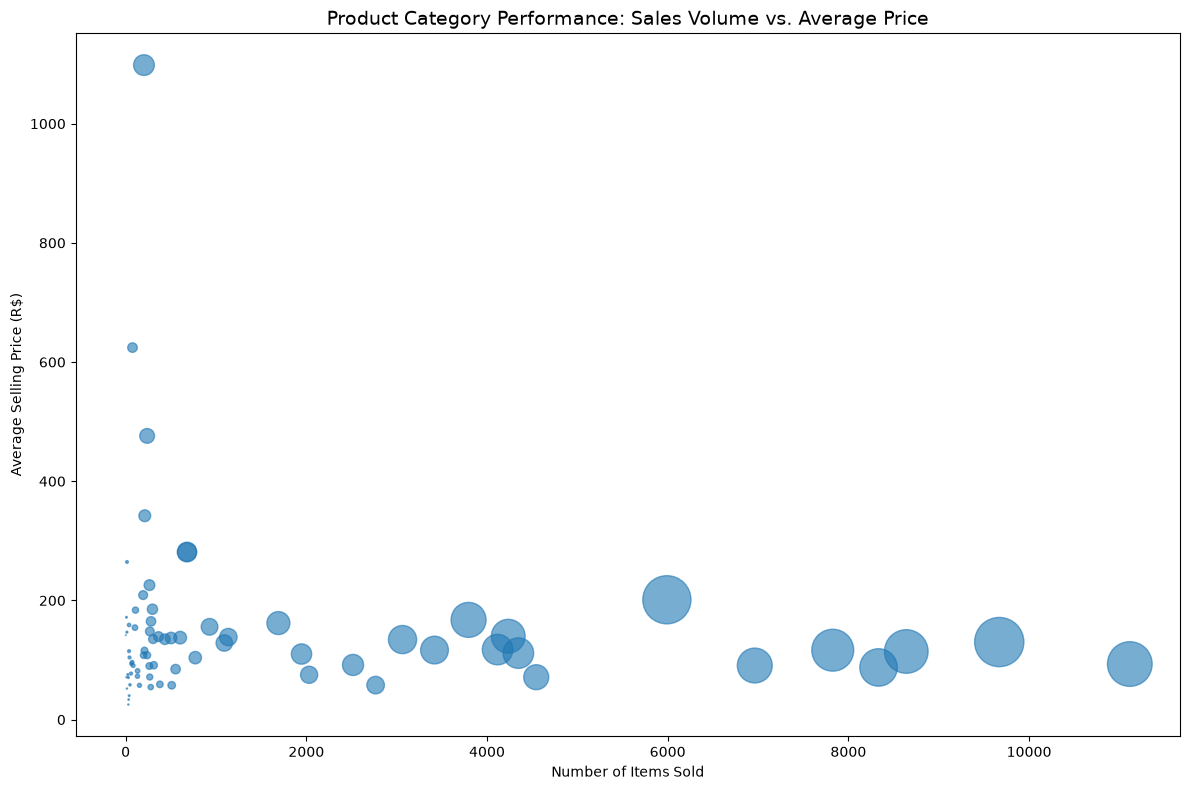

In [156]:
plt.figure(figsize=(12, 8))

plt.scatter(
    category_performance['items_sold'],
    category_performance['average_price'],
    s=category_performance['total_sales'] / 1000,
    alpha=0.6
)

plt.title(
    'Product Category Performance: Sales Volume vs. Average Price',
    fontsize=14
)

plt.xlabel('Number of Items Sold')
plt.ylabel('Average Selling Price (R$)')

plt.tight_layout()
plt.show()

The bubble chart highlights different strategies behind category-level sales performance.

Categories positioned further to the right have higher sales volume, while categories positioned higher on the chart have higher average selling prices. Larger bubbles represent categories with higher total sales.

Categories such as `pcs` demonstrate how a relatively small sales volume can still generate substantial revenue when average prices are high. In contrast, categories such as `cama_mesa_banho` demonstrate how high transaction volume can generate strong sales despite relatively low average prices.

This reinforces the conclusion that category performance is influenced by a combination of sales volume and average selling price rather than by either metric alone.

- `pcs` had the largest positive difference between sales rank and volume rank, ranking **17th in sales but 46th in volume**.
- `pcs` sold only **203 items**, but its average selling price was **R$1,098.34**, resulting in **R$222,963.13** in sales.
- `bebidas` showed the opposite pattern, ranking **31st in volume but 46th in sales**, with an average selling price of only **R$59.18**.
- `relogios_presentes` ranked **2nd in sales and 7th in volume**, demonstrating the contribution of its relatively high average price of **R$201.14**.
- `cama_mesa_banho` ranked **1st in volume and 3rd in sales**, showing how high transaction volume can compensate for a relatively low average price of **R$93.30**.

The analysis demonstrates that product categories can achieve strong sales through different combinations of price and volume.

High-price categories can generate substantial revenue with relatively few transactions, while lower-price categories need significantly higher sales volume to achieve comparable revenue.

Therefore, category performance should not be evaluated using a single metric. Revenue generation depends on the interaction between average selling price and sales volume.

For business decision-making, high-volume categories may represent opportunities for scale and customer acquisition, while high-price categories may offer opportunities for revenue generation with fewer transactions.

### 4.10.5 Category Performance vs. Review Score

This analysis examines whether product categories with stronger sales performance also achieve higher customer satisfaction.

By combining category-level sales metrics with customer review scores, we can identify categories that perform well commercially while maintaining a positive customer experience, as well as categories where strong sales may coexist with lower customer satisfaction.

#### Review Structure

The review dataset is organized at the order level, while product categories are stored in the product dataset.

Before linking reviews to product categories, the relationship between reviews and orders must be examined to avoid unintentionally duplicating review scores when an order contains multiple products.

In [158]:
review_order_counts = (
    reviews
    .groupby('order_id')
    .size()
    .reset_index(name='review_count')
)

review_order_counts['review_count'].value_counts().sort_index()

review_count
1    98126
2      543
3        4
Name: count, dtype: int64

#### Average Review Score per Order

Since a small number of orders contain multiple reviews, the average review score is calculated at the order level before connecting reviews to product categories.

This ensures that each order contributes equally to the category-level customer satisfaction analysis, regardless of the number of reviews associated with the order.

In [159]:
order_review_score = (
    reviews
    .groupby('order_id', as_index=False)['review_score']
    .mean()
    .rename(columns={'review_score': 'average_review_score'})
)

order_review_score.head()

,order_id,average_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


#### Linking Reviews to Product Categories

The order-level review scores are now combined with order items and product information to identify the product categories associated with each customer review.

Because an order can contain multiple products, a review may be associated with more than one product category.

The analysis will therefore focus on category-level patterns rather than treating each review as belonging to a single product.

In [160]:
order_category_reviews = (
    items_category[
        ['order_id', 'product_id', 'product_category_name']
    ]
    .dropna(subset=['product_category_name'])
    .merge(
        order_review_score,
        on='order_id',
        how='inner'
    )
)

order_category_reviews.head()

,order_id,product_id,product_category_name,average_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,5.0


In [161]:
order_category_reviews.shape

(110119, 4)

#### Avoiding Duplicate Review Weights

Because an order may contain multiple items from the same product category, the same review score can appear multiple times for a single order-category combination.

To prevent orders with more items from receiving greater weight in the category-level review score, duplicate `order_id` and `product_category_name` combinations are removed before calculating the average review score.

In [163]:
category_reviews = (
    order_category_reviews[
        ['order_id', 'product_category_name', 'average_review_score']
    ]
    .drop_duplicates(
        subset=['order_id', 'product_category_name']
    )
)

print(f"Original rows: {len(order_category_reviews):,}")
print(f"Unique order-category rows: {len(category_reviews):,}")

Original rows: 110,119
Unique order-category rows: 97,276


#### Average Review Score by Product Category

After ensuring that each order-category combination contributes only once, the average review score is calculated for each product category.

This provides a category-level measure of customer satisfaction that is not disproportionately influenced by orders containing multiple items from the same category.

In [164]:
category_review_score = (
    category_reviews
    .groupby('product_category_name', as_index=False)
    .agg(
        average_review_score=('average_review_score', 'mean'),
        reviewed_orders=('order_id', 'nunique')
    )
    .sort_values(
        'average_review_score',
        ascending=False
    )
)

category_review_score.head(10)

,product_category_name,average_review_score,reviewed_orders
17,cds_dvds_musicais,4.666667,12
37,fashion_roupa_infanto_juvenil,4.500000,8
48,livros_interesse_geral,4.462598,508
22,construcao_ferramentas_ferramentas,4.425532,94
49,livros_tecnicos,4.400778,257
41,flores,4.392857,28
2,alimentos_bebidas,4.382743,226
50,malas_acessorios,4.331068,1030
47,livros_importados,4.320755,53
64,portateis_casa_forno_e_cafe,4.293333,75


#### Review Score Reliability

Average review scores can be misleading when calculated from a very small number of reviews.

For example, a category with only a few reviewed orders may achieve a very high average score simply because of limited observations.

Therefore, the number of reviewed orders is considered alongside the average review score when evaluating category-level customer satisfaction.

In [165]:
reliable_category_reviews = (
    category_review_score[
        category_review_score['reviewed_orders'] >= 100
    ]
    .sort_values(
        'average_review_score',
        ascending=False
    )
)

reliable_category_reviews.head(10)

,product_category_name,average_review_score,reviewed_orders
48,livros_interesse_geral,4.462598,508
49,livros_tecnicos,4.400778,257
2,alimentos_bebidas,4.382743,226
50,malas_acessorios,4.331068,1030
1,alimentos,4.276404,445
59,papelaria,4.244662,2295
63,pet_shop,4.238095,1701
34,fashion_calcados,4.218220,236
62,perfumaria,4.203333,3150
24,construcao_ferramentas_jardim,4.190722,194


#### Lowest-Rated Product Categories

The same minimum threshold of 100 reviewed orders is applied to identify categories with the lowest average review scores.

Using the same threshold ensures that the comparison between highly rated and poorly rated categories is based on a sufficient number of customer reviews.

In [166]:
lowest_rated_categories = (
    category_review_score[
        category_review_score['reviewed_orders'] >= 100
    ]
    .sort_values(
        'average_review_score',
        ascending=True
    )
)

lowest_rated_categories.head(10)

,product_category_name,average_review_score,reviewed_orders
55,moveis_escritorio,3.616390,1263
38,fashion_roupa_masculina,3.702703,111
7,audio,3.834294,347
25,construcao_ferramentas_seguranca,3.849398,166
14,casa_conforto,3.863291,395
71,telefonia_fixa,3.901869,214
39,fashion_underwear_e_moda_praia,3.933333,120
16,casa_construcao,3.967146,487
13,cama_mesa_banho,3.970740,9313
70,telefonia,4.003119,4168


#### Combining Sales Performance and Customer Satisfaction

The sales performance metrics and customer review scores are combined to evaluate product categories from both commercial and customer satisfaction perspectives.

This allows categories to be classified into different performance patterns, such as:

- High sales and high customer satisfaction
- High sales and low customer satisfaction
- Low sales and high customer satisfaction
- Low sales and low customer satisfaction

This comparison can reveal categories that are commercially successful but may have opportunities for improving customer experience.

In [167]:
category_performance_reviews = (
    category_performance
    .merge(
        category_review_score,
        on='product_category_name',
        how='left'
    )
)

category_performance_reviews.head(10)

,product_category_name,total_sales,sales_percentage,average_price,items_sold,average_review_score,reviewed_orders
0,beleza_saude,1258681.34,9.384664,130.163531,9670,4.181203,8771
1,relogios_presentes,1205005.68,8.984461,201.135984,5991,4.065459,5576
2,cama_mesa_banho,1036988.68,7.731735,93.296327,11115,3.970740,9313
3,esporte_lazer,988048.97,7.366843,114.344285,8641,4.167362,7669
4,informatica_acessorios,911954.32,6.799485,116.513903,7827,4.026245,6649
5,moveis_decoracao,729762.49,5.441072,87.564494,8334,4.009691,6398
6,cool_stuff,635290.85,4.736696,167.357969,3796,4.169630,3599
7,utilidades_domesticas,632248.66,4.714014,90.788148,6964,4.142221,5843
8,automotivo,592720.11,4.419291,139.957523,4235,4.090147,3877
9,ferramentas_jardim,485256.46,3.618048,111.630196,4347,4.136156,3496


#### Sales Performance vs. Customer Satisfaction

The relationship between total sales and average review score is examined to determine whether commercially successful product categories also tend to achieve higher customer satisfaction.

A correlation analysis is used to quantify the strength and direction of the relationship across product categories.

In [168]:
sales_review_correlation = category_performance_reviews[
    ['total_sales', 'average_review_score']
].corr()

sales_review_correlation

,total_sales,average_review_score
total_sales,1.000000,0.054919
average_review_score,0.054919,1.000000


#### Sales Performance vs. Customer Satisfaction

The relationship between total sales and customer satisfaction is visualized using a scatter plot.

The Pearson correlation coefficient is displayed directly on the chart, together with a linear trend line, to make the strength and direction of the relationship easier to interpret.

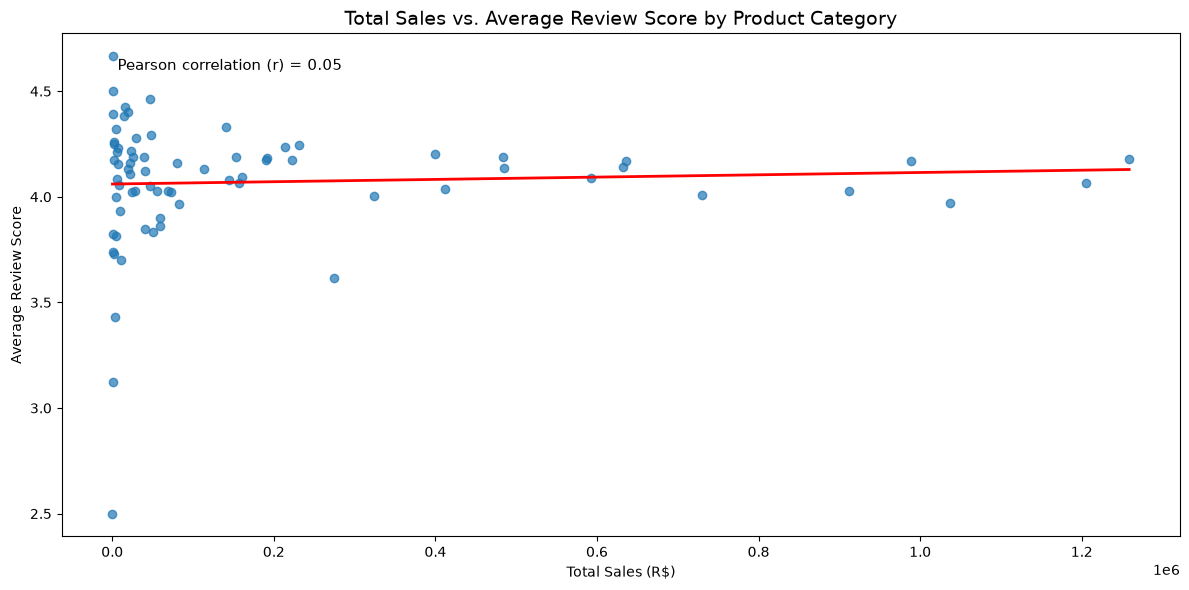

In [170]:
x = category_performance_reviews['total_sales']
y = category_performance_reviews['average_review_score']

correlation = x.corr(y)

slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    alpha=0.7
)

plt.plot(
    x,
    trend_line,
    color='red',
    linewidth=2
)

plt.title(
    'Total Sales vs. Average Review Score by Product Category',
    fontsize=14
)

plt.xlabel('Total Sales (R$)')
plt.ylabel('Average Review Score')

plt.text(
    0.05,
    0.95,
    f'Pearson correlation (r) = {correlation:.2f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top'
)

plt.tight_layout()
plt.show()

The scatter plot shows a very weak relationship between total sales and average review score.

The Pearson correlation coefficient of **0.05** indicates that categories with higher sales do not systematically receive higher or lower customer review scores.

This suggests that commercial performance and customer satisfaction are largely independent at the product category level in this dataset.

#### High-Sales Categories with Lower Customer Satisfaction

While total sales and review scores show almost no overall linear relationship, individual categories may still combine strong commercial performance with relatively low customer satisfaction.

Identifying these categories can reveal potential business opportunities where improvements in product quality, fulfillment, or customer experience may have a meaningful impact.

In [171]:
top_sales_review_analysis = (
    category_performance_reviews
    .sort_values('total_sales', ascending=False)
    .head(10)
    [
        [
            'product_category_name',
            'total_sales',
            'items_sold',
            'average_price',
            'average_review_score',
            'reviewed_orders'
        ]
    ]
    .sort_values('average_review_score', ascending=True)
)

top_sales_review_analysis

,product_category_name,total_sales,items_sold,average_price,average_review_score,reviewed_orders
2,cama_mesa_banho,1036988.68,11115,93.296327,3.970740,9313
5,moveis_decoracao,729762.49,8334,87.564494,4.009691,6398
4,informatica_acessorios,911954.32,7827,116.513903,4.026245,6649
1,relogios_presentes,1205005.68,5991,201.135984,4.065459,5576
8,automotivo,592720.11,4235,139.957523,4.090147,3877
9,ferramentas_jardim,485256.46,4347,111.630196,4.136156,3496
7,utilidades_domesticas,632248.66,6964,90.788148,4.142221,5843
3,esporte_lazer,988048.97,8641,114.344285,4.167362,7669
6,cool_stuff,635290.85,3796,167.357969,4.169630,3599
0,beleza_saude,1258681.34,9670,130.163531,4.181203,8771


- The correlation between total sales and average review score is only **0.05**, indicating an almost negligible linear relationship between commercial performance and customer satisfaction.
- Among the top 10 categories by total sales, `cama_mesa_banho` has the lowest average review score at **3.97**, based on **9,313 reviewed orders**.
- `moveis_decoracao` has an average review score of **4.01** across **6,398 reviewed orders**.
- `informatica_acessorios` has an average review score of **4.03** across **6,649 reviewed orders**.
- `beleza_saude`, the highest-selling category with **R$1.26 million** in sales, has a relatively stronger review score of **4.18**, based on **8,771 reviewed orders**.
- The results show that high sales performance does not necessarily correspond to higher customer satisfaction.

The results indicate that sales performance and customer satisfaction should be monitored as separate dimensions of category performance.

Some of the marketplace's strongest revenue-generating categories have relatively lower review scores. In particular, `cama_mesa_banho` combines high sales volume and strong revenue contribution with a review score below 4.0.

This may represent an opportunity for further investigation into potential drivers of customer dissatisfaction, such as product quality, delivery experience, product descriptions, or seller performance.

However, the analysis is descriptive and does not establish the specific causes of lower review scores. Further investigation would be required to determine which operational or product-related factors are associated with customer dissatisfaction.

Overall, the analysis found almost no linear relationship between category-level sales and customer review scores.

This indicates that commercially successful categories are not necessarily better or worse rated by customers. Therefore, revenue performance and customer satisfaction should be evaluated independently when assessing product category performance.

### 4.10.6 Key Insights

The Product & Category Performance Analysis examined product distribution, category sales, average selling prices, sales volume, and customer review scores.

The analysis revealed several important patterns in the Olist marketplace, including differences between product availability, sales contribution, sales volume, pricing, and customer satisfaction.

- `cama_mesa_banho` was the largest product category by product count, representing **9.37%** of all products.
- The top 5 product categories represented **41.22%** of the product catalog, while the top 10 represented **64.14%**.
- `beleza_saude` generated the highest total sales at approximately **R$1.26 million**, representing **9.38%** of category-level sales.
- The top 5 categories by sales accounted for **40.27%** of category-level sales, while the top 10 accounted for **63.20%**.
- `cama_mesa_banho` sold the largest number of items among the top categories, with **11,115 items**, despite having an average selling price of only **R$93.30**.
- `relogios_presentes` ranked **2nd in total sales** while ranking only **7th in sales volume**, supported by a relatively high average selling price of **R$201.14**.
- `pcs` demonstrated the strongest difference between sales and volume rankings, ranking **17th in sales but 46th in volume**, with an average selling price of **R$1,098.34**.
- The correlation between items sold and total sales was **0.95**, indicating a very strong positive relationship.
- The correlation between average price and total sales was only **0.02**, suggesting an almost negligible linear relationship.
- The correlation between total sales and average review score was only **0.05**, indicating that commercial performance and customer satisfaction were largely independent at the category level.
- `cama_mesa_banho` combined strong commercial performance with a relatively low average review score of **3.97**, based on **9,313 reviewed orders**.

The analysis suggests that product category performance is primarily driven by sales volume rather than average selling price. High-volume categories can generate substantial revenue even when their products have relatively low average prices.

At the same time, higher-priced categories can achieve strong revenue with considerably fewer transactions. This means that category performance should be evaluated using a combination of sales volume, pricing, and total revenue rather than relying on a single metric.

Customer satisfaction represents a separate dimension of performance. The very weak correlation between total sales and review scores indicates that commercially successful categories are not necessarily associated with higher customer satisfaction.

Categories such as `cama_mesa_banho` may therefore deserve additional investigation because they combine high sales volume and revenue with comparatively lower customer review scores. Understanding the causes of dissatisfaction could reveal opportunities to improve the customer experience while protecting revenue from high-performing categories.

Overall, the Product & Category Performance Analysis shows that the Olist marketplace has a concentrated product catalog and sales distribution, with a relatively small number of categories accounting for a substantial share of products and revenue.

Sales volume appears to be much more strongly associated with category-level revenue than average product price, while customer satisfaction does not show a meaningful relationship with sales performance.

These findings provide a foundation for further analysis of customer behavior, operational performance, and the factors that influence both sales and customer satisfaction.

### 4.11 Seller Performance Analysis

#### 4.11.1 Seller Sales Performance

Seller sales performance is analyzed by aggregating the value of products sold by each seller.

This analysis helps identify how marketplace revenue is distributed across sellers and provides a foundation for evaluating seller concentration and individual seller performance.

In [174]:
seller_sales = (
    items.groupby('seller_id', as_index=False)
    .agg(
        total_sales=('price', 'sum'),
        items_sold=('order_item_id', 'count')
    )
    .sort_values('total_sales', ascending=False)
)

seller_sales.head(10)

,seller_id,total_sales,items_sold
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156
1013,53243585a1d6dc2643021fd1853d8905,222776.05,410
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1987
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,340
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1551
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1171
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1428
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1499


In [175]:
active_sellers = seller_sales['seller_id'].nunique()

total_sellers = sellers['seller_id'].nunique()

active_seller_percentage = (
    active_sellers / total_sellers * 100
)

print(f"Total sellers: {total_sellers:,}")
print(f"Active sellers with sales: {active_sellers:,}")
print(f"Percentage of active sellers: {active_seller_percentage:.2f}%")

Total sellers: 3,095
Active sellers with sales: 3,095
Percentage of active sellers: 100.00%


#### 4.11.2 Top Sellers

The top sellers are identified based on total sales generated through the marketplace.

Comparing total sales with the number of items sold provides additional context on whether sellers generate revenue primarily through sales volume or higher-value products.

In [176]:
top_sellers = seller_sales.copy()

top_sellers['average_item_price'] = (
    top_sellers['total_sales'] / top_sellers['items_sold']
)

top_sellers = top_sellers.head(10)

top_sellers

,seller_id,total_sales,items_sold,average_item_price
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156,198.505735
1013,53243585a1d6dc2643021fd1853d8905,222776.05,410,543.356220
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1987,100.892260
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586,331.129744
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364,137.774113
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,340,518.917265
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1551,103.311779
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1171,121.046567
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1428,97.316912
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1499,90.174583


In [177]:
top_10_seller_sales = top_sellers['total_sales'].sum()

total_seller_sales = seller_sales['total_sales'].sum()

top_10_sales_percentage = (
    top_10_seller_sales / total_seller_sales * 100
)

print(f"Top 10 seller sales: R${top_10_seller_sales:,.2f}")
print(f"Total seller sales: R${total_seller_sales:,.2f}")
print(f"Top 10 sellers' share of sales: {top_10_sales_percentage:.2f}%")

Top 10 seller sales: R$1,787,241.74
Total seller sales: R$13,591,643.70
Top 10 sellers' share of sales: 13.15%


#### 4.11.3 Seller Sales Concentration

Seller sales concentration is analyzed to determine how dependent the marketplace is on its highest-performing sellers.

The share of total sales generated by the top 1%, 5%, 10%, and 20% of sellers is calculated to assess whether revenue is concentrated among a small group of sellers or distributed more broadly across the marketplace.

In [178]:
seller_sales_sorted = seller_sales.sort_values(
    'total_sales',
    ascending=False
).reset_index(drop=True)

total_sellers = len(seller_sales_sorted)
total_sales = seller_sales_sorted['total_sales'].sum()

concentration_results = []

for percentage in [1, 5, 10, 20]:
    seller_count = max(1, round(total_sellers * percentage / 100))
    
    sales_share = (
        seller_sales_sorted.head(seller_count)['total_sales'].sum()
        / total_sales
        * 100
    )
    
    concentration_results.append({
        'seller_percentage': percentage,
        'seller_count': seller_count,
        'sales_share': sales_share
    })

seller_concentration = pd.DataFrame(concentration_results)

seller_concentration

,seller_percentage,seller_count,sales_share
0,1,31,26.073787
1,5,155,53.302463
2,10,310,67.564858
3,20,619,82.691678


In [179]:
top_20_seller_sales = (
    seller_sales_sorted.head(20)['total_sales'].sum()
)

top_20_sales_percentage = (
    top_20_seller_sales / total_sales * 100
)

print(f"Top 20 seller sales: R${top_20_seller_sales:,.2f}")
print(f"Top 20 sellers' share of sales: {top_20_sales_percentage:.2f}%")

Top 20 seller sales: R$2,866,544.30
Top 20 sellers' share of sales: 21.09%


#### Seller Sales Concentration

The concentration of marketplace sales among sellers is visualized by comparing the cumulative share of sellers with their cumulative share of total sales.

This helps illustrate how strongly marketplace revenue is concentrated among the highest-performing sellers.

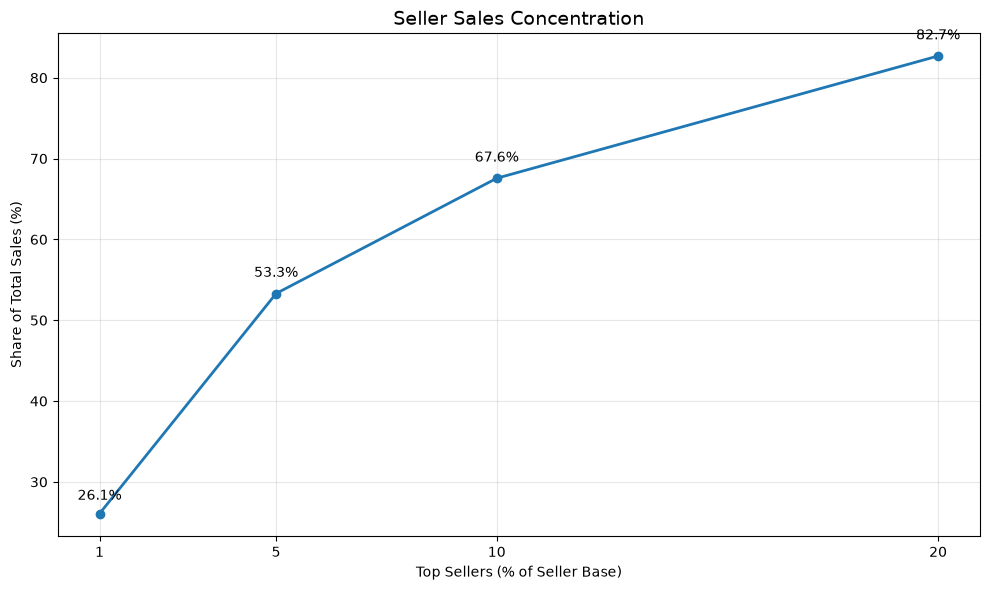

In [181]:
concentration_plot = seller_concentration.copy()

plt.figure(figsize=(10, 6))

plt.plot(
    concentration_plot['seller_percentage'],
    concentration_plot['sales_share'],
    marker='o',
    linewidth=2
)

label_offsets = {
    1: (0, 10),
    5: (0, 12),
    10: (0, 12),
    20: (0, 12)
}

for _, row in concentration_plot.iterrows():
    offset = label_offsets[row['seller_percentage']]
    
    plt.annotate(
        f"{row['sales_share']:.1f}%",
        (row['seller_percentage'], row['sales_share']),
        xytext=offset,
        textcoords='offset points',
        ha='center'
    )

plt.title(
    'Seller Sales Concentration',
    fontsize=14
)

plt.xlabel('Top Sellers (% of Seller Base)')
plt.ylabel('Share of Total Sales (%)')

plt.xticks([1, 5, 10, 20])

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Sales are highly concentrated among the highest-performing sellers.

The top **1% of sellers account for 26.07% of total sales**, while the top **10% account for 67.56%**. The top **20% of sellers generate 82.69% of total sales**.

This indicates that although all 3,095 sellers recorded sales, marketplace revenue is disproportionately generated by a relatively small group of high-performing sellers.

#### 4.11.4 Seller Performance vs. Review Score

This analysis examines whether seller sales performance is associated with customer satisfaction.

Seller sales are compared with average review scores to determine whether high-performing sellers also tend to receive better customer ratings.

In [182]:
order_reviews = (
    reviews.groupby('order_id', as_index=False)
    .agg(
        average_review_score=('review_score', 'mean'),
        review_count=('review_score', 'count')
    )
)

order_reviews.head()

,order_id,average_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [183]:
seller_reviews = (
    items[['order_id', 'seller_id']]
    .merge(
        order_reviews,
        on='order_id',
        how='inner'
    )
)

seller_reviews.head()

,order_id,seller_id,average_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,5.0,1


In [184]:
seller_review_performance = (
    seller_reviews.groupby('seller_id', as_index=False)
    .agg(
        average_review_score=('average_review_score', 'mean'),
        reviewed_orders=('order_id', 'nunique')
    )
)

seller_review_performance = (
    seller_sales
    .merge(
        seller_review_performance,
        on='seller_id',
        how='left'
    )
)

seller_review_performance.head()

,seller_id,total_sales,items_sold,average_review_score,reviewed_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156,4.122822,1124.0
1,53243585a1d6dc2643021fd1853d8905,222776.05,410,4.075980,356.0
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1987,3.803262,1785.0
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586,4.340206,581.0
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364,3.341445,976.0


In [185]:
seller_review_correlation = (
    seller_review_performance[
        ['total_sales', 'average_review_score']
    ]
    .corr()
)

seller_review_correlation

,total_sales,average_review_score
total_sales,1.000000,0.021048
average_review_score,0.021048,1.000000


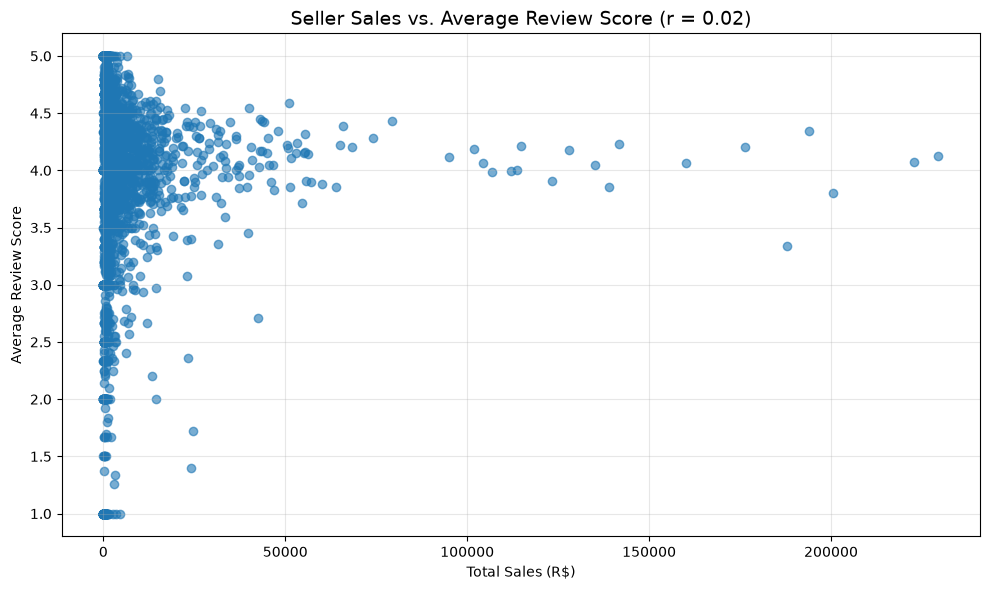

In [189]:
correlation = (
    seller_review_performance[
        ['total_sales', 'average_review_score']
    ]
    .corr()
    .loc['total_sales', 'average_review_score']
)

plt.figure(figsize=(10, 6))

x = seller_review_performance['total_sales']
y = seller_review_performance['average_review_score']

plt.scatter(
    x,
    y,
    alpha=0.6
)

trend = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend)

plt.plot(
    x,
    trend_line(x),
    linewidth=2
)

plt.title(
    f'Seller Sales vs. Average Review Score (r = {correlation:.2f})',
    fontsize=14
)

plt.xlabel('Total Sales (R$)')
plt.ylabel('Average Review Score')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Average review scores can be less reliable for sellers with very few reviewed orders.

To reduce the influence of sellers with limited review history, the relationship between sales and review scores is re-evaluated using sellers with at least **50 reviewed orders**.

In [191]:
seller_review_filtered = seller_review_performance[
    seller_review_performance['reviewed_orders'] >= 50
].copy()

print(f"Sellers with at least 50 reviewed orders: {len(seller_review_filtered):,}")

Sellers with at least 50 reviewed orders: 425


In [192]:
filtered_correlation = (
    seller_review_filtered[
        ['total_sales', 'average_review_score']
    ]
    .corr()
    .loc['total_sales', 'average_review_score']
)

print(f"Correlation between seller sales and review score: {filtered_correlation:.4f}")

Correlation between seller sales and review score: -0.0131


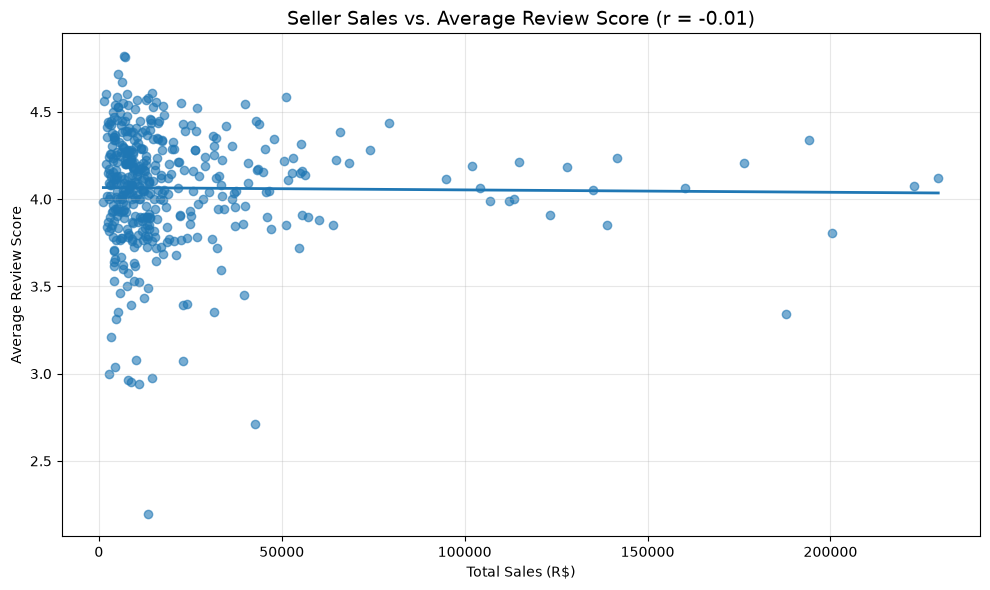

In [193]:
plt.figure(figsize=(10, 6))

x = seller_review_filtered['total_sales']
y = seller_review_filtered['average_review_score']

plt.scatter(
    x,
    y,
    alpha=0.6
)

trend = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend)

plt.plot(
    x,
    trend_line(x),
    linewidth=2
)

plt.title(
    f'Seller Sales vs. Average Review Score (r = {filtered_correlation:.2f})',
    fontsize=14
)

plt.xlabel('Total Sales (R$)')
plt.ylabel('Average Review Score')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The relationship between seller sales and customer review scores is negligible.

The correlation between total sales and average review score is **0.0210** across all sellers and decreases to **-0.0131** when limiting the analysis to sellers with at least 50 reviewed orders.

This suggests that higher sales performance is not associated with better or worse customer ratings in this dataset.

Sales volume and customer satisfaction appear to be largely independent dimensions of seller performance.

This suggests that marketplace success should not be evaluated based on sales alone. Seller performance monitoring should consider multiple indicators, including sales volume, customer satisfaction, delivery performance, and other operational metrics.

#### 4.11.5 Seller Delivery Performance

Seller performance can also be evaluated from an operational perspective by examining delivery outcomes associated with each seller.

This analysis compares seller sales activity with delivery performance to identify whether high-volume sellers are associated with better or worse delivery outcomes.

In [196]:
seller_delivery = (
    items[['order_id', 'seller_id']]
    .merge(
        orders[
            [
                'order_id',
                'delivery_days',
                'delivery_delay_days',
                'delivery_performance'
            ]
        ],
        on='order_id',
        how='inner'
    )
)

seller_delivery.head()

,order_id,seller_id,delivery_days,delivery_delay_days,delivery_performance
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,7.614421,-8.011250,On Time
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,16.216181,-2.330278,On Time
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,7.948437,-13.444954,On Time
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,6.147269,-5.435660,On Time
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,25.114352,-15.303808,On Time


In [197]:
seller_delivery_performance = (
    seller_delivery
    .groupby('seller_id', as_index=False)
    .agg(
        average_delivery_days=('delivery_days', 'mean'),
        average_delivery_delay=('delivery_delay_days', 'mean'),
        total_orders=('order_id', 'nunique')
    )
)

on_time_orders = (
    seller_delivery[
        seller_delivery['delivery_performance'] == 'On Time'
    ]
    .groupby('seller_id')['order_id']
    .nunique()
    .reset_index(name='on_time_orders')
)

seller_delivery_performance = seller_delivery_performance.merge(
    on_time_orders,
    on='seller_id',
    how='left'
)

seller_delivery_performance['on_time_orders'] = (
    seller_delivery_performance['on_time_orders']
    .fillna(0)
)

seller_delivery_performance['on_time_rate'] = (
    seller_delivery_performance['on_time_orders']
    / seller_delivery_performance['total_orders']
    * 100
)

seller_delivery_performance.head()

,seller_id,average_delivery_days,average_delivery_delay,total_orders,on_time_orders,on_time_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,10.793885,-15.593380,3,3.0,100.000000
1,001cca7ae9ae17fb1caed9dfb1094831,13.096632,-12.569366,200,182.0,91.000000
2,001e6ad469a905060d959994f1b41e4f,NaN,NaN,1,0.0,0.000000
3,002100f778ceb8431b7a1020ff7ab48f,16.192371,-7.395119,51,41.0,80.392157
4,003554e2dce176b5555353e4f3555ac8,4.646806,-26.066794,1,1.0,100.000000


To make the comparison more reliable, sellers with fewer than 50 orders are excluded from the correlation analysis.

This reduces the influence of sellers with very limited order history and allows the relationship between sales performance and delivery performance to be evaluated using a more consistent seller base.

In [199]:
seller_complete_performance = (
    seller_review_performance
    .merge(
        seller_delivery_performance,
        on='seller_id',
        how='left'
    )
)

seller_complete_performance.head()

,seller_id,total_sales,items_sold,average_review_score,reviewed_orders,average_delivery_days,average_delivery_delay,total_orders,on_time_orders,on_time_rate
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156,4.122822,1124.0,15.005261,-10.453161,1132,994.0,87.809187
1,53243585a1d6dc2643021fd1853d8905,222776.05,410,4.075980,356.0,13.374429,-10.877354,358,333.0,93.016760
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1987,3.803262,1785.0,14.416471,-8.954641,1806,1577.0,87.320044
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586,4.340206,581.0,13.341871,-9.612764,585,519.0,88.717949
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364,3.341445,976.0,22.392546,-10.832570,982,875.0,89.103870


In [200]:
seller_delivery_filtered = seller_complete_performance[
    seller_complete_performance['total_orders'] >= 50
].copy()

print(
    f"Sellers with at least 50 orders: "
    f"{len(seller_delivery_filtered):,}"
)

Sellers with at least 50 orders: 429


In [201]:
sales_delivery_correlation = (
    seller_delivery_filtered[
        ['total_sales', 'on_time_rate']
    ]
    .corr()
    .loc['total_sales', 'on_time_rate']
)

print(
    f"Correlation between seller sales and "
    f"on-time delivery rate: "
    f"{sales_delivery_correlation:.4f}"
)

Correlation between seller sales and on-time delivery rate: -0.0334


#### Seller Sales vs. On-Time Delivery Rate

The relationship between seller sales and on-time delivery performance is visualized using a scatter plot with a linear trend line.

The correlation coefficient is included in the chart to quantify the strength and direction of the relationship.

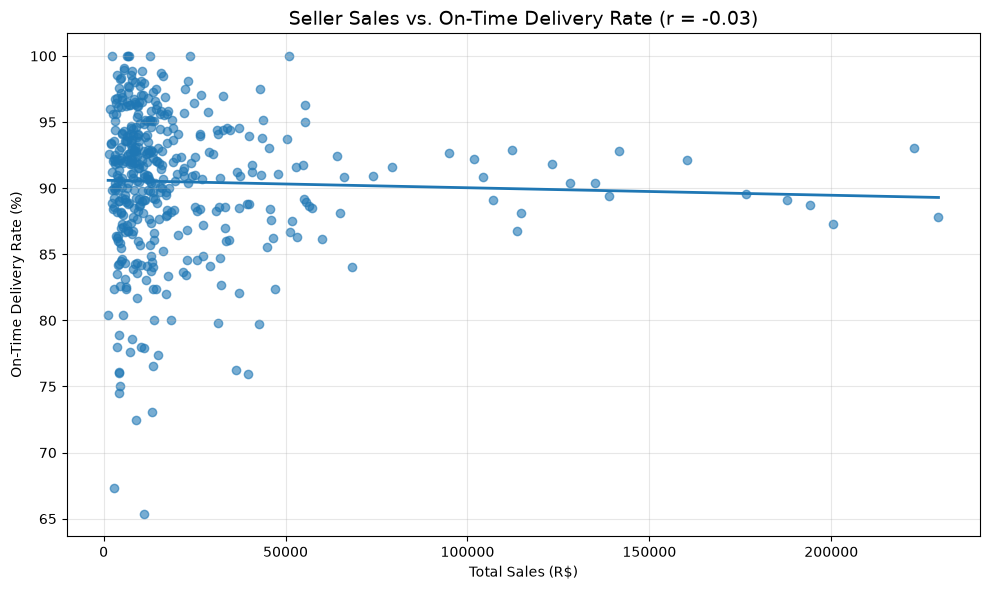

In [202]:
plt.figure(figsize=(10, 6))

x = seller_delivery_filtered['total_sales']
y = seller_delivery_filtered['on_time_rate']

plt.scatter(
    x,
    y,
    alpha=0.6
)

trend = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend)

plt.plot(
    x,
    trend_line(x),
    linewidth=2
)

plt.title(
    f'Seller Sales vs. On-Time Delivery Rate (r = {sales_delivery_correlation:.2f})',
    fontsize=14
)

plt.xlabel('Total Sales (R$)')
plt.ylabel('On-Time Delivery Rate (%)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

There is virtually no linear relationship between seller sales and on-time delivery performance.

Among sellers with at least 50 orders, the correlation between total sales and on-time delivery rate is **-0.0334**.

This indicates that higher sales volume is not meaningfully associated with better or worse on-time delivery performance.

Seller sales volume and delivery reliability appear to be largely independent dimensions of marketplace performance.

High-volume sellers do not necessarily have better delivery performance, suggesting that seller evaluation should consider both commercial and operational metrics rather than relying on sales volume alone.

### 4.11.6 Key Insights

The seller performance analysis revealed several important characteristics of the Olist marketplace:

- **Seller base:** The dataset contains **3,095 sellers**, and all sellers recorded at least one sale.

- **Sales concentration:** The top **10 sellers generated R$1.79 million**, representing **13.15% of total seller sales**. When expanding the analysis, the top **10% of sellers accounted for 67.56% of total sales**, while the top **20% generated 82.69%**. This indicates substantial concentration of marketplace revenue among high-performing sellers.

- **Seller sales volume:** The highest-selling sellers did not always have the highest number of items sold. Differences in average item price can significantly affect total seller revenue.

- **Customer satisfaction:** The correlation between seller sales and average review score was only **0.0210** across sellers. After restricting the analysis to sellers with at least 50 reviewed orders, the correlation was **-0.0131**, indicating virtually no linear relationship between sales performance and customer ratings.

- **Delivery performance:** Among sellers with at least 50 orders, the correlation between total sales and on-time delivery rate was **-0.0334**, also indicating virtually no meaningful linear relationship.

- **Overall seller performance:** The results suggest that seller success is multidimensional. High sales volume does not necessarily imply better customer satisfaction or delivery reliability.

The marketplace appears to rely heavily on a relatively small group of high-performing sellers, making these sellers particularly important to overall revenue. However, commercial performance alone does not appear to predict customer satisfaction or delivery reliability.

For marketplace management, seller evaluation should therefore combine **sales, order volume, customer reviews, and delivery performance** rather than relying on a single KPI.

## 4.12 Overall EDA Summary & Key Business Insights

This section consolidates the main findings from the exploratory data analysis and translates them into business-oriented insights.

Rather than introducing new analyses, the objective is to connect the findings from sales, customers, products, delivery, reviews, and sellers to provide an overall understanding of the marketplace.

### 4.12.1 Sales & Revenue Summary

The sales analysis provides an overview of the marketplace's revenue generation, sales volume, and product category performance.

The analysis focuses on the main revenue-generating categories, sales concentration, average order value, and the relationship between sales volume and revenue.

In [203]:
sales_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Items Sold',
        'Average Order Value',
        'Top 5 Categories Sales Share',
        'Top 10 Categories Sales Share'
    ],
    'Value': [
        'R$13,591,643.70',
        f'{items["order_id"].count():,}',
        f'R${monthly_aov["aov"].mean():,.2f}',
        '40.27%',
        '63.20%'
    ]
})

sales_summary

,Metric,Value
0,Total Sales,"R$13,591,643.70"
1,Total Items Sold,"112,650"
2,Average Order Value,R$132.71
3,Top 5 Categories Sales Share,40.27%
4,Top 10 Categories Sales Share,63.20%


The sales analysis shows that the marketplace generated **R$13.59 million in total sales** across **112,650 items sold**, with an average order value of approximately **R$132.71**.

Sales are relatively concentrated among a limited number of product categories. The **top 5 categories account for 40.27% of category-level sales**, while the **top 10 categories account for 63.20%**.

This concentration indicates that a relatively small group of product categories plays a major role in the marketplace's overall revenue generation.

The concentration of revenue among a relatively small number of categories suggests that these categories should receive particular attention when making decisions related to inventory, seller acquisition, promotions, and marketing.

At the same time, the marketplace may benefit from identifying opportunities in lower-performing categories to diversify its revenue base and reduce dependence on its strongest product segments.

### 4.12.2 Customers & Geography

The geographic analysis examines the distribution of customers and sales across Brazilian states and cities.

Understanding geographic concentration can help identify the marketplace's most important markets and support decisions related to logistics, regional marketing, and seller expansion.

In [204]:
customer_geographic_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Top Customer State',
        'Top Customer State Share',
        'Second Customer State',
        'Second Customer State Share',
        'Third Customer State',
        'Third Customer State Share'
    ],
    'Value': [
        '99,441',
        'SP',
        '41.98%',
        'RJ',
        '12.92%',
        'MG',
        '11.70%'
    ]
})

customer_geographic_summary

,Metric,Value
0,Total Customers,"99,441"
1,Top Customer State,SP
2,Top Customer State Share,41.98%
3,Second Customer State,RJ
4,Second Customer State Share,12.92%
5,Third Customer State,MG
6,Third Customer State Share,11.70%


The customer base is geographically concentrated in a small number of Brazilian states.

São Paulo (SP) represents **41.98% of all customers**, followed by Rio de Janeiro (RJ) with **12.92%** and Minas Gerais (MG) with **11.70%**.

Together, these three states account for **66.60% of the customer base**, highlighting the strong concentration of marketplace activity in Brazil's Southeast region.

The strong geographic concentration in SP, RJ, and MG suggests that these states are critical markets for the marketplace.

This concentration can support more targeted regional marketing and logistics strategies. However, expanding customer acquisition and seller presence in less represented regions could provide opportunities for geographic diversification and future growth.

### 4.12.3 Delivery & Operations

The delivery analysis evaluates the marketplace's operational performance by examining delivery times, estimated delivery dates, and extreme delays.

The objective is to identify the overall delivery performance and potential operational risks that could affect customer satisfaction.

In [205]:
delivery_summary = pd.DataFrame({
    'Metric': [
        'Total Deliveries Analyzed',
        'Average Delivery Delay',
        'Extreme Delays',
        'Extreme Delays Share'
    ],
    'Value': [
        '96,476',
        '-11.18 days',
        '965',
        '1.00%'
    ]
})

delivery_summary

,Metric,Value
0,Total Deliveries Analyzed,"96,476"
1,Average Delivery Delay,-11.18 days
2,Extreme Delays,965
3,Extreme Delays Share,1.00%


The delivery analysis shows that **96,476 deliveries** were successfully analyzed.

The average delivery delay was **-11.18 days**, meaning that, on average, orders were delivered approximately 11 days earlier than the estimated delivery date.

There were **965 extreme delivery delays**, representing only **1.00%** of the analyzed deliveries. This indicates that extreme delivery delays were relatively uncommon in the dataset.

Overall, the marketplace demonstrated strong delivery performance relative to the estimated delivery dates, with deliveries typically occurring ahead of schedule.

However, the presence of **965 extreme delays** indicates that a small group of orders experienced significant operational issues. These cases may be useful for further investigation, particularly in relation to specific sellers, regions, or time periods.

### 4.12.4 Reviews & Customer Satisfaction

Customer reviews provide an important measure of customer satisfaction and can help identify potential issues in the purchasing experience.

This section summarizes the distribution of review scores and examines whether seller sales performance is associated with customer satisfaction.

In [206]:
review_summary = pd.DataFrame({
    'Metric': [
        'Total Reviews',
        '5-Star Reviews',
        '4-Star Reviews',
        '3-Star Reviews',
        '2-Star Reviews',
        '1-Star Reviews'
    ],
    'Value': [
        f'{reviews.shape[0]:,}',
        '57,328',
        '19,142',
        '8,179',
        '3,151',
        '11,424'
    ]
})

review_summary

,Metric,Value
0,Total Reviews,"99,224"
1,5-Star Reviews,"57,328"
2,4-Star Reviews,"19,142"
3,3-Star Reviews,"8,179"
4,2-Star Reviews,"3,151"
5,1-Star Reviews,"11,424"


#### Review Distribution

The review distribution is strongly concentrated toward positive ratings, with 5-star reviews representing the largest share of customer feedback.

However, the presence of a significant number of 1-star reviews indicates that a meaningful subset of customers experienced dissatisfaction.

In [207]:
review_distribution = (
    reviews['review_score']
    .value_counts()
    .sort_index(ascending=False)
    .reset_index()
)

review_distribution.columns = ['review_score', 'review_count']

review_distribution['percentage'] = (
    review_distribution['review_count']
    / review_distribution['review_count'].sum()
    * 100
)

review_distribution

,review_score,review_count,percentage
0,5,57328,57.776344
1,4,19142,19.291704
2,3,8179,8.242965
3,2,3151,3.175643
4,1,11424,11.513344


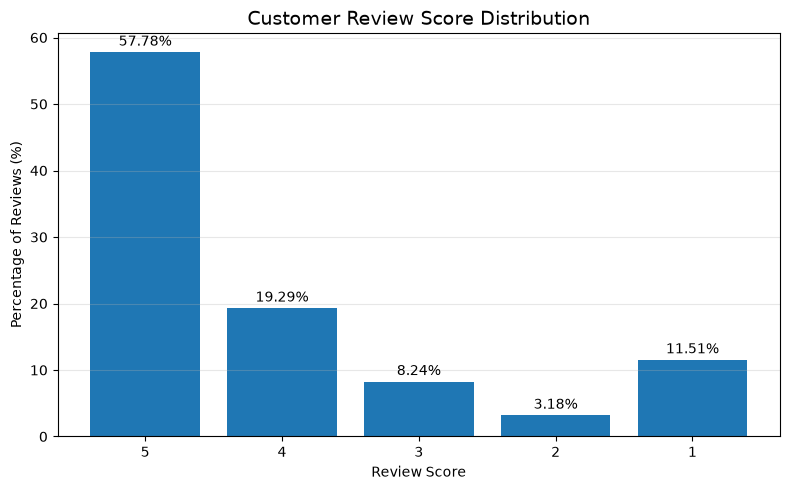

In [209]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    review_distribution['review_score'].astype(str),
    review_distribution['percentage']
)

plt.title(
    'Customer Review Score Distribution',
    fontsize=14
)

plt.xlabel('Review Score')
plt.ylabel('Percentage of Reviews (%)')

plt.grid(
    axis='y',
    alpha=0.3
)

# Add percentage labels
for bar, percentage in zip(
    bars,
    review_distribution['percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{percentage:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Customer reviews are strongly concentrated toward positive ratings.

5-star reviews account for approximately **57.78%** of all reviews, while 4-star reviews represent approximately **19.29%**.

However, **11.51% of reviews received only 1 star**, indicating that a relevant portion of customers experienced significant dissatisfaction.

Overall, the review distribution suggests generally positive customer satisfaction, while also highlighting a meaningful group of highly dissatisfied customers that may warrant further investigation.

#### 4.12.4.2 Delivery Performance vs. Customer Satisfaction

Delivery performance can have a direct impact on customer satisfaction.

This analysis examines whether delivery delays are associated with lower customer review scores.

The objective is to determine whether customers tend to provide lower ratings when their orders are delivered later than expected.

In [210]:
review_delivery = (
    reviews[
        ['order_id', 'review_score']
    ]
    .merge(
        orders[
            ['order_id', 'delivery_delay_days']
        ],
        on='order_id',
        how='inner'
    )
)

review_delivery.head()

,order_id,review_score,delivery_delay_days
0,73fc7af87114b39712e6da79b0a377eb,4,-15.220359
1,a548910a1c6147796b98fdf73dbeba33,5,-4.029630
2,f9e4b658b201a9f2ecdecbb34bed034b,5,-20.271667
3,658677c97b385a9be170737859d3511b,5,-19.619039
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,-8.310012


In [211]:
review_delivery_by_score = (
    review_delivery
    .groupby('review_score', as_index=False)
    .agg(
        average_delivery_delay=('delivery_delay_days', 'mean'),
        reviewed_orders=('order_id', 'nunique')
    )
    .sort_values('review_score')
)

review_delivery_by_score

,review_score,average_delivery_delay,reviewed_orders
0,1,-3.370628,11393
1,2,-7.938027,3148
2,3,-10.078493,8160
3,4,-11.684076,19098
4,5,-12.688362,57076


#### Delivery Timing by Review Score

The average delivery delay varies considerably across review scores.

Customers who gave higher ratings generally received their orders earlier relative to the estimated delivery date, while lower-rated orders had smaller delivery advantages.

This suggests that delivery performance may be an important factor influencing customer satisfaction.

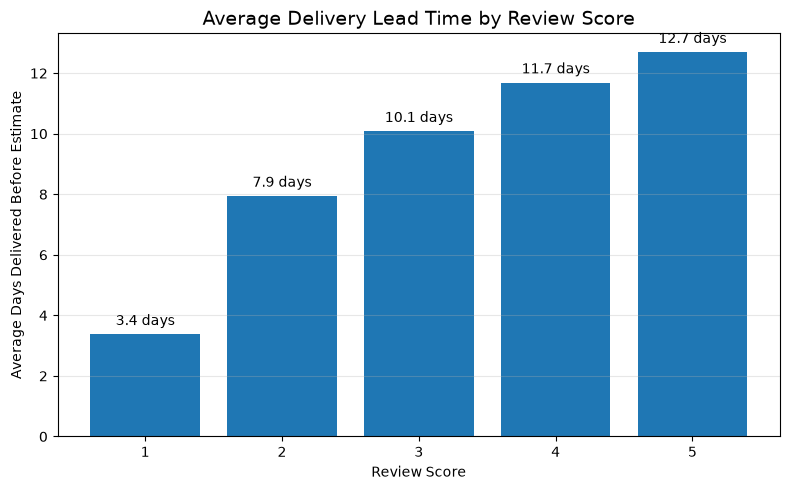

In [213]:
review_delivery_by_score['days_early'] = (
    -review_delivery_by_score['average_delivery_delay']
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    review_delivery_by_score['review_score'].astype(str),
    review_delivery_by_score['days_early']
)

plt.title(
    'Average Delivery Lead Time by Review Score',
    fontsize=14
)

plt.xlabel('Review Score')
plt.ylabel('Average Days Delivered Before Estimate')

plt.grid(
    axis='y',
    alpha=0.3
)

# Add values to bars
for bar, value in zip(
    bars,
    review_delivery_by_score['days_early']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{value:.1f} days',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

The `delivery_delay_days` metric represents the difference between the actual delivery date and the estimated delivery date.

Negative values indicate that the order was delivered **before the estimated delivery date**, while positive values indicate that the order was delivered **after the estimated date**.

For example, a value of **-12 days** means that the order was delivered approximately 12 days earlier than expected.

Therefore, the negative values observed in this analysis represent **early deliveries rather than delays**. For visualization purposes, these values were converted into positive "days before estimate" values to make the chart easier to interpret.

#### 4.12.4.3 Correlation Between Delivery Timing and Review Score

To quantify the relationship between delivery timing and customer satisfaction, the correlation between review score and delivery delay is calculated.

A negative correlation indicates that higher review scores are associated with lower delivery delay values, meaning that orders tend to be delivered earlier relative to the estimated date.

In [214]:
review_delivery_correlation = (
    review_delivery[
        ['review_score', 'delivery_delay_days']
    ]
    .corr()
    .loc['review_score', 'delivery_delay_days']
)

print(
    f"Correlation between review score and delivery delay: "
    f"{review_delivery_correlation:.4f}"
)

Correlation between review score and delivery delay: -0.2664


The correlation between review score and delivery delay was **-0.2664**, indicating a weak-to-moderate negative relationship.

Because negative delivery delay values represent deliveries made before the estimated date, this result suggests that customers tend to give higher ratings when their orders are delivered earlier than expected.

However, the correlation is not strong enough to conclude that delivery timing is the only or main factor determining customer satisfaction. Other factors, such as product quality, seller performance, and customer expectations, may also influence review scores.

Delivery performance appears to be an important factor associated with customer satisfaction.

The analysis suggests that consistently delivering orders earlier than the estimated date may contribute to higher customer ratings. However, the relatively modest correlation indicates that improving delivery performance alone is unlikely to fully explain or solve customer dissatisfaction.

For the marketplace, delivery reliability should therefore be considered alongside product quality, seller performance, and other aspects of the customer experience when evaluating customer satisfaction.

### 4.12.5 Sellers Summary

The seller analysis evaluated marketplace revenue concentration, sales volume, customer satisfaction, and delivery performance.

The objective is to understand how sales are distributed across sellers and whether commercial performance is associated with customer satisfaction or operational reliability.

In [215]:
seller_summary = pd.DataFrame({
    'Metric': [
        'Total Sellers',
        'Top 10 Sellers Sales Share',
        'Top 20 Sellers Sales Share',
        'Top 10% Sellers Sales Share',
        'Top 20% Sellers Sales Share',
        'Sales vs. Review Score Correlation',
        'Sales vs. On-Time Rate Correlation'
    ],
    'Value': [
        '3,095',
        '13.15%',
        '21.09%',
        '67.56%',
        '82.69%',
        '0.0210',
        '-0.0334'
    ]
})

seller_summary

,Metric,Value
0,Total Sellers,"3,095"
1,Top 10 Sellers Sales Share,13.15%
2,Top 20 Sellers Sales Share,21.09%
3,Top 10% Sellers Sales Share,67.56%
4,Top 20% Sellers Sales Share,82.69%
5,Sales vs. Review Score Correlation,0.0210
6,Sales vs. On-Time Rate Correlation,-0.0334


The seller analysis reveals a highly concentrated marketplace structure.

Although the marketplace contains **3,095 sellers**, the top **10% of sellers account for 67.56% of total sales**, while the top **20% account for 82.69%**.

At the same time, seller sales performance shows almost no linear relationship with customer satisfaction or delivery reliability. The correlation between sales and average review score was **0.0210**, while the correlation between sales and on-time delivery rate was **-0.0334**.

This indicates that high sales volume does not necessarily correspond to better customer ratings or better delivery performance.

The strong concentration of sales among a relatively small group of sellers makes these sellers particularly important to the marketplace's overall revenue.

However, sales volume alone should not be used as a measure of overall seller quality. Marketplace management should monitor **revenue contribution, customer satisfaction, and delivery reliability together** when evaluating seller performance.

The concentration of sales also highlights a potential opportunity to develop high-potential smaller sellers and reduce dependence on a limited number of major sellers.

### 4.12.6 Final Business Insights

The exploratory data analysis revealed several important characteristics of the Olist marketplace. The main findings are summarized below.

#### 1. Revenue is concentrated among a limited number of product categories

The marketplace generated approximately **R$13.59 million in sales** from **112,650 items sold**, with an average order value of approximately **R$132.71**.

The top 5 product categories accounted for **40.27% of category-level sales**, while the top 10 categories accounted for **63.20%**.

This indicates that a relatively small number of categories are responsible for a substantial portion of marketplace revenue.

#### 2. Customer activity is geographically concentrated

The marketplace has **99,441 customers**, with **São Paulo accounting for 41.98%** of the customer base.

Rio de Janeiro and Minas Gerais represent another **24.62%**, meaning that these three states together account for **66.60% of customers**.

This strong geographic concentration highlights the importance of Brazil's Southeast region to the marketplace.

#### 3. Delivery performance is generally strong

Among **96,476 analyzed deliveries**, the average delivery delay was **-11.18 days**, indicating that orders were delivered approximately 11 days before the estimated delivery date on average.

Extreme delivery delays represented only **1.00%** of analyzed deliveries, suggesting that severe delivery problems were relatively uncommon.

#### 4. Delivery timing is associated with customer satisfaction

The analysis found a correlation of **-0.2664** between review score and delivery delay.

Because negative values represent deliveries made before the estimated date, the result suggests that earlier deliveries tend to be associated with higher customer ratings.

However, the relationship is not strong enough to conclude that delivery performance alone determines customer satisfaction.

#### 5. Seller revenue is highly concentrated

The marketplace contains **3,095 sellers**, but the top **10% of sellers generate 67.56% of total seller sales**, while the top 20% generate **82.69%**.

This indicates substantial dependence on a relatively small group of high-performing sellers.

#### 6. Sales volume does not necessarily indicate seller quality

Seller sales showed almost no linear relationship with customer satisfaction or delivery reliability.

The correlation between seller sales and average review score was **0.0210**, while the correlation between seller sales and on-time delivery rate was **-0.0334**.

Therefore, high sales volume should not be interpreted as evidence of superior seller performance.

### Overall Business Perspective

Overall, the Olist marketplace demonstrates strong revenue concentration across both **product categories and sellers**, while customer activity is strongly concentrated geographically.

Delivery performance appears generally positive, and earlier deliveries are associated with better customer reviews. However, seller sales volume alone is not a reliable indicator of customer satisfaction or operational quality.

These findings suggest that marketplace performance should be evaluated using a combination of **revenue, sales volume, customer satisfaction, delivery performance, and seller concentration** rather than relying on a single KPI.

In [2]:
import pandas as pd

products = pd.read_csv("../data/cleaned/products_clean.csv")

products.iloc[105]

product_id                    a41e356c76fab66334f36de622ecbd3a
product_category_name                                      NaN
product_name_lenght                                        NaN
product_description_lenght                                 NaN
product_photos_qty                                         NaN
product_weight_g                                         650.0
product_length_cm                                         17.0
product_height_cm                                         14.0
product_width_cm                                          12.0
Name: 105, dtype: object

In [3]:
products.iloc[8578].to_dict()

{'product_id': '09ff539a621711667c43eba6a3bd8466',
 'product_category_name': 'bebes',
 'product_name_lenght': 60.0,
 'product_description_lenght': 865.0,
 'product_photos_qty': 3.0,
 'product_weight_g': nan,
 'product_length_cm': nan,
 'product_height_cm': nan,
 'product_width_cm': nan}

In [4]:
products.loc[8578, "product_width_cm"]

np.float64(nan)

In [9]:
import pandas as pd

reviews = pd.read_csv(
    r"C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\reviews_clean.csv"
)

print("Linhas:", len(reviews))
print("IDs únicos:", reviews["review_id"].nunique())
print("IDs duplicados:", reviews["review_id"].duplicated().sum())

Linhas: 99224
IDs únicos: 98410
IDs duplicados: 814


In [10]:
duplicates = reviews[
    reviews["review_id"].duplicated(keep=False)
].sort_values("review_id")

duplicates.head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44


In [11]:
reviews.duplicated(
    subset=["review_id", "order_id"]
).sum()

np.int64(0)

In [13]:
print("Total no CSV:", len(reviews))

print(
    "Duplicatas do par review_id + order_id:",
    reviews.duplicated(
        subset=["review_id", "order_id"],
        keep=False
    ).sum()
)

Total no CSV: 99224
Duplicatas do par review_id + order_id: 0


In [14]:
dup = reviews[
    reviews.duplicated(
        subset=["review_id", "order_id"],
        keep=False
    )
].sort_values(["review_id", "order_id"])

print(dup.to_string(index=False))

Empty DataFrame
Columns: [review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp]
Index: []


In [15]:
print("CSV:", len(reviews))
print("MySQL:", 99222)
print("Diferença:", len(reviews) - 99222)

CSV: 99224
MySQL: 99222
Diferença: 2
